In [ ]:
# revisar si conviene borrar location_4 o no

# agrego precio por barrio y por tipo de propiedad
# quiero eliminar galpon terreno y todo eso

# **FCEN DM 2026 - Predicción precio de propiedades en Buenos Aires (Argentina)**

---



# Colab Base para el Trabajo Práctico (Entrega 2)

*Programa de creación de la entrega 2*

Los conjuntos de datos siguen el siguiente esquema:
- id: Identificador del aviso
- description: Descripción
- address: Dirección
- lat: Latitud.
- lon: Longitud.
- publication_date: fecha de publicación en el sitio
- publisher_id: id de la inmobiliaria o el corredor que publicó el aviso
- features: características de la propiedad
- location_0: Nivel administrativo 1: país.
- location_1: Nivel administrativo 2: usualmente provincia
- location_2: Nivel administrativo 3: usualmente ciudad
- location_3: Nivel administrativo 4: usualmente barrio
- location_4: Nivel administrativo 5: usualmente subbarrio
- property_type - Tipo de propiedad (Casa, Departamento, PH…)
- operation_type - Tipo de operación (Venta, Alquiler…)
- source: Sitio de donde proviene el aviso
- price: Precio publicado en el anuncio
- currency_type: Moneda del precio publicado

## Librerías

In [ ]:
import pandas as pd
import sqlite3
import seaborn as sns
import numpy as np
import re
import matplotlib.pyplot as plt

import sklearn as sk
from sklearn import model_selection
from sklearn import ensemble
from sklearn import metrics
from sklearn.neighbors import KNeighborsRegressor

In [ ]:
pip install geopandas pyogrio shapely

In [ ]:
pip install folium

In [ ]:
#pd.__version__

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


## 0. Lectura de datos

In [ ]:
# TODO: Cambiar para que apunte al directorio correcto
DIR = "/content/drive/MyDrive/MAESTRÍA CIENCIA DE DATOS - DATA MINING - UBA/2026 - Primer Cuatrimestre/Data Mining - Miérc/TP1/datos"

In [ ]:
engine = sqlite3.connect(f"{DIR}/entrenamiento.db")

df_ent = pd.read_sql("SELECT * FROM entrenamiento", engine, index_col='id')

In [ ]:
df_ent.head()

,description,address,lat,lon,publication_date,publisher_id,features,location_0,location_1,location_2,location_3,location_4,operation_type,property_type,source,price,currency_type
id,,,,,,,,,,,,,,,,,
0,galpón de 275 metros cuadrados cubiertos. ...,"Soldini, Rosario, Santa Fe, ARG",-33.008797,-60.743675,"Hace 1 semana, 17 horas",None,electricidad;cerca de:,Argentina,Santa Fe,Soldini,Rosario,None,venta,galpón,properati,150000.0,dolares
1,"venta de galpón en barrio urquiza, rosario sob...","Boulevard 27 de Febrero, Rosario, S2009, Santa...",-32.959099,-60.710079,1 ene 2026,None,1 baño;700 m²;electricidad;cerca de:,Argentina,Santa Fe,Rosario,Rosario,None,venta,galpón,properati,250000.0,dolares
2,mira esta y otras propiedades en nuestro sitio...,"Calle Virasoro 3450, Rosario, S2003, Santa Fe,...",-32.963959,-60.675930,30 nov 2025,None,2 dormitorios;1 baño;250 m²;internet;electrici...,Argentina,Santa Fe,Rosario,Rosario,None,venta,galpón,properati,130000.0,dolares
3,"nave en venta, de 5.278 m2 cubiertos, construi...","Exaltación de la Cruz, Provincia de Buenos Air...",-34.345760,-59.001122,"Hace 2 semanas, 5 días",None,5.280 m²;cerca de:,Argentina,Provincia de Buenos Aires,Exaltación de la Cruz,Exaltación de la Cruz,None,venta,galpón,properati,4500000.0,dolares
4,se vende con muy buena renta!!! venta en nave ...,"Calle 22 22, Barrio Parque Almirante Irizar, P...",-34.392982,-58.982834,30 dic 2025,None,3.500 m²;cerca de:,Argentina,Provincia de Buenos Aires,Barrio Parque Almirante Irizar,Pilar,None,venta,galpón,properati,2500000.0,dolares


In [ ]:
# cantidad de filas y columnas
df_ent.shape

(1292674, 17)

In [ ]:
#df_ent.columns

In [ ]:
df_ap = pd.read_csv(f"{DIR}/a_predecir.csv", index_col="id")

## 1. Entender los datos (AID)

In [ ]:
#df_ent["property_type"].value_counts()

## 2. Limpiar y transformar los datos (DM)

## 2.1. Filtrado de datos



### Datos de entrenamiento: NA y Nulos

In [ ]:
#for c in df_ent.columns:
#  print(c,df_ent[c].isna().sum(),df_ent[c].notna().sum(),(df_ent[c].isna().sum()/df_ent[c].notna().sum())*100)

In [ ]:
#sns.heatmap(df_ent.isnull(),yticklabels=False,cbar=False,cmap='viridis')

### FILTRADO

### PRECIO

In [ ]:
# Quedarnos con los datos de entrenamiento que tienen precio
df_ent = df_ent.loc[df_ent['price'].notna()]
df_ent['price'].isna().sum()

np.int64(0)

### TIPO DE OPERACIÓN

In [ ]:
#df_ent["operation_type"].value_counts(dropna=False)
# tengo venta 800.456 y None 69.485

In [ ]:
# Quedarnos solo con los que sean venta
df_ent = df_ent.loc[(df_ent["operation_type"] == "venta")]

#### Probé quedarme con los null de operation_type (aparte de los “venta”) e intentar sacar de la description que diga algo relacionado con venta, pero solo rescataba 2400 registros y la verdad era tremendo quilombo después solo par esa cantidad. Así que al final solo me quedo con los operation_type venta

In [ ]:
# Quedarnos solo con los que sean venta o nulo
#df_ent = df_ent.loc[(df_ent["operation_type"] == "venta") | (df_ent["operation_type"].isna())]

In [ ]:
"""
#df_ent.head(2)

# Para los que tengan operation_type isna quiero ver si en la descripcion dice algo de venta
# Quiero crear una variable venta_aux donde estén todos na, y si operation_type es na busque en descripcion si contiene "venta" y complete "venta" para esos

#df_ent = df_ent.drop(columns=["venta_aux"])

# 1. Creamos la columna llena de NaNs (puedes usar np.nan o None)
df_ent["venta_aux"] = None

# 2. Definimos la condición: que sea nulo en operation_type Y contenga "venta" en descripcion
#patron = r"\bventa\b|\bvende\b|vendemos|venden"
#patron = r"\b(?:venta|vende)\b|vendemos|venden"
patron = r"\b(venta|en venta|a la venta|se vende|vende|vendemos|venden)\b"

condicion = (df_ent["operation_type"].isna()) & \
            (df_ent["description"].str.contains(patron, case=False, na=False, regex=True))

# 3. Donde se cumpla la condición, ponemos "venta". Donde no, dejamos lo que había (NaN)
df_ent["venta_aux"] = np.where(condicion, "venta", df_ent["venta_aux"])

# 4. Quiero ver cuantos pude completar
rescatados = df_ent["venta_aux"].count()
print(f"Se han completado {rescatados} registros basados en la descripción.")
"""


'\n#df_ent.head(2)\n\n# Para los que tengan operation_type isna quiero ver si en la descripcion dice algo de venta\n# Quiero crear una variable venta_aux donde estén todos na, y si operation_type es na busque en descripcion si contiene "venta" y complete "venta" para esos\n\n#df_ent = df_ent.drop(columns=["venta_aux"])\n\n# 1. Creamos la columna llena de NaNs (puedes usar np.nan o None)\ndf_ent["venta_aux"] = None\n\n# 2. Definimos la condición: que sea nulo en operation_type Y contenga "venta" en descripcion\n#patron = r"\x08venta\x08|\x08vende\x08|vendemos|venden"\n#patron = r"\x08(?:venta|vende)\x08|vendemos|venden"\npatron = r"\x08(venta|en venta|a la venta|se vende|vende|vendemos|venden)\x08"\n\ncondicion = (df_ent["operation_type"].isna()) &             (df_ent["description"].str.contains(patron, case=False, na=False, regex=True))\n\n# 3. Donde se cumpla la condición, ponemos "venta". Donde no, dejamos lo que había (NaN)\ndf_ent["venta_aux"] = np.where(condicion, "venta", df_ent[

In [ ]:
#df_ent[df_ent["venta_aux"].notna()]["location_1"].value_counts(dropna=False)

In [ ]:
#df_ent[df_ent["venta_aux"].notna()]["property_type"].value_counts(dropna=False)

In [ ]:
#df_matriz = df_ent[df_ent["venta_aux"].notna()]
#sns.heatmap(df_matriz.isnull(),yticklabels=False,cbar=False,cmap='viridis')

In [ ]:
#df_ent[df_ent["venta_aux"].notna()]

In [ ]:
#df_ent["operation_type"] = df_ent["operation_type"].fillna(df_ent["venta_aux"])

In [ ]:
#df_ent = df_ent.drop(columns=["venta_aux"])

### PRECIO BÁSICO

In [ ]:
df_ent = df_ent.loc[df_ent["price"]>14000]

### LOCATION 1: PROVINCIA

In [ ]:
df_ent['location_1'].isna().sum()

np.int64(15)

In [ ]:
ubicaciones_capital_federal = [
    'Ciudad Autónoma de Buenos Aires', 'CABA', 'Capital Federal'
]
# Que esté en la lista
df_ent = df_ent.loc[df_ent['location_1'].isin(ubicaciones_capital_federal)]

In [ ]:
# Reemplazo por Capital Federal para que quede todo c el mismo nombre
mapeo_location_1 = {
    'Ciudad Autónoma de Buenos Aires': 'Capital Federal',
    'CABA': 'Capital Federal'
}

df_ap['location_1'] = df_ap['location_1'].replace(mapeo_location_1)
df_ent['location_1'] = df_ent['location_1'].replace(mapeo_location_1)

In [ ]:
#df_ap["location_1"].value_counts(dropna=False)
#df_ent["location_1"].value_counts(dropna=False)

### LOCATION 0: PAÍS

In [ ]:
#df_ap["location_0"].value_counts(dropna=False)
#df_ent["location_0"].value_counts(dropna=False)

### TIPO DE PROPIEDAD

In [ ]:
df_ent['property_type'].isna().sum()

np.int64(0)

In [ ]:
# Quedarnos con los que sean departamentos o casas

# Definimos los valores que queremos mantener
tipos_propiedad = ["departamento", "casa", "departamentos", "casas"]

# Filtramos directamente
df_ent = df_ent.loc[df_ent["property_type"].isin(tipos_propiedad)]

In [ ]:
mapeo_property_type = {
    'departamento': 'departamento',
    'departamentos': 'departamento',
    'casa': 'casa',
    'casas': 'casa',
}
df_ap['property_type'] = df_ap['property_type'].replace(mapeo_property_type)
df_ent['property_type'] = df_ent['property_type'].replace(mapeo_property_type)

### TIPO DE MONEDA

In [ ]:
df_ent["currency_type"].value_counts(dropna=False)

,count
currency_type,
dolares,110703
pesos,187


In [ ]:
# Quedarnos con los que sean en dólares
df_ent = df_ent.loc[(df_ent["currency_type"] == "dolares")]

In [ ]:
#df_ent.shape

In [ ]:
#df_ap["currency_type"].value_counts(dropna=False)

In [ ]:
# Más adelante para los que están en pesos podría multiplicar la predicción por 1450?

#### Probé pasar los de pesos a dolares pero tmb era bastante quilombo solo para 189 datos

In [ ]:
# El dolar blue entre enero 2026 y febrero 2026 que fue de cuando se obtuvieron los datos estuvo entre 1515 y 1425 --> tomo promedio 1450
#precio_promedio_dolar_blue_ene_feb_2026=1450

In [ ]:
"""
# Voy a crear una variable price_original (para seguir guardando lo original) y tambien una variable flag_pesos
# Luego voy a convertir todos los valores a dolares

# 1. Creamos price_original copiando los valores actuales de price
df_ent['price_original'] = df_ent['price']

# 2. Inicializamos flag_peso en 0 (por defecto, no es peso)
df_ent['flag_pesos'] = 0

# 3. Definimos la máscara para las filas que son "pesos"
mask_pesos = df_ent['currency_type'] == "pesos"

# 4. Aplicamos los cambios solo a esas filas:
# Seteamos la flag en 1
df_ent.loc[mask_pesos, 'flag_pesos'] = 1

# Convertimos el precio a dólares en la columna original
df_ent.loc[mask_pesos, 'price'] = df_ent.loc[mask_pesos, 'price'] / precio_promedio_dolar_blue_ene_feb_2026

# Cambiamos el tipo de moneda a "dolar"
df_ent.loc[mask_pesos, 'currency_type'] = "dolares"
"""

'\n# Voy a crear una variable price_original (para seguir guardando lo original) y tambien una variable flag_pesos\n# Luego voy a convertir todos los valores a dolares\n\n# 1. Creamos price_original copiando los valores actuales de price\ndf_ent[\'price_original\'] = df_ent[\'price\']\n\n# 2. Inicializamos flag_peso en 0 (por defecto, no es peso)\ndf_ent[\'flag_pesos\'] = 0\n\n# 3. Definimos la máscara para las filas que son "pesos"\nmask_pesos = df_ent[\'currency_type\'] == "pesos"\n\n# 4. Aplicamos los cambios solo a esas filas:\n# Seteamos la flag en 1\ndf_ent.loc[mask_pesos, \'flag_pesos\'] = 1\n\n# Convertimos el precio a dólares en la columna original\ndf_ent.loc[mask_pesos, \'price\'] = df_ent.loc[mask_pesos, \'price\'] / precio_promedio_dolar_blue_ene_feb_2026\n\n# Cambiamos el tipo de moneda a "dolar"\ndf_ent.loc[mask_pesos, \'currency_type\'] = "dolares"\n'

In [ ]:
#df_ent[df_ent["flag_pesos"]==1]

In [ ]:
df_ent.shape

(110703, 17)

### Datos de entrenamiento: NA y Nulos

In [ ]:
#sns.heatmap(df_ent.isnull(),yticklabels=False,cbar=False,cmap='viridis')

### LOCATION 2: CIUDAD

In [ ]:
#df_ent['location_2'].isna().sum()

In [ ]:
#df_ent[df_ent['location_2'].isna()]

In [ ]:
df_ent.loc[100414, 'location_2'] = 'Capital Federal'
df_ent.loc[100414, 'location_3'] = 'Centro'

df_ent.loc[102838, 'location_2'] = 'Capital Federal'
df_ent.loc[102838, 'location_3'] = 'Las Cañitas'

df_ent.loc[383585, 'location_2'] = 'Capital Federal'
df_ent.loc[383585, 'location_3'] = 'Palermo'

df_ent.loc[432951, 'location_2'] = 'Capital Federal'
df_ent.loc[432951, 'location_3'] = 'Villa Urquiza'

df_ent.loc[432952, 'location_2'] = 'Capital Federal'
df_ent.loc[432952, 'location_3'] = 'La Paternal'

df_ent.loc[432959, 'location_2'] = 'Capital Federal'
df_ent.loc[432959, 'location_3'] = 'San Nicolás'

df_ent.loc[432962, 'location_2'] = 'Capital Federal'
df_ent.loc[432962, 'location_3'] = 'La Boca'

df_ent.loc[702008, 'location_2'] = 'Capital Federal'
df_ent.loc[702008, 'location_3'] = 'Balvanera'

df_ent.loc[711928, 'location_2'] = 'Capital Federal'
df_ent.loc[711928, 'location_3'] = 'San Nicolás'

df_ent.loc[711621, 'location_2'] = 'Capital Federal'
df_ent.loc[711621, 'location_3'] = 'Villa Urquiza'

df_ent.loc[710491, 'location_2'] = 'Capital Federal'
df_ent.loc[710491, 'location_3'] = 'San Nicolás'

df_ent.loc[709837, 'location_2'] = 'Capital Federal'
df_ent.loc[709837, 'location_3'] = 'San Nicolás'

In [ ]:
df_ent.loc[701083, 'address'] = 'Esmeralde 629'
df_ent.loc[701083, 'lat'] = '-34.600690473530484'
df_ent.loc[701083, 'lon'] = '-58.378140061208434'
df_ent.loc[701083, 'location_2'] = 'Capital Federal'
df_ent.loc[701083, 'location_3'] = 'San Nicolás'

/tmp/ipykernel_145/2625677348.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-34.600690473530484' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_ent.loc[701083, 'lat'] = '-34.600690473530484'
/tmp/ipykernel_145/2625677348.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-58.378140061208434' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_ent.loc[701083, 'lon'] = '-58.378140061208434'


In [ ]:
#Estos salen de cuando revisaba los precios de constitucion; estaban asignados a constitucion pero son de otro lado; igual abajo lo corrijo de raíz

df_ent.loc[113360, 'location_2'] = 'Capital Federal'
df_ent.loc[113360, 'location_3'] = 'Nuñez'

df_ent.loc[309776, 'location_2'] = 'Capital Federal'
df_ent.loc[309776, 'location_3'] = 'Recoleta'

df_ent.loc[96615, 'location_2'] = 'Capital Federal'
df_ent.loc[96615, 'location_3'] = 'Belgrano'

df_ent.loc[97635, 'location_2'] = 'Capital Federal'
df_ent.loc[97635, 'location_3'] = 'Belgrano'

df_ent.loc[98402, 'location_2'] = 'Capital Federal'
df_ent.loc[98402, 'location_3'] = 'Belgrano'

df_ent.loc[104139, 'location_2'] = 'Capital Federal'
df_ent.loc[104139, 'location_3'] = 'Recoleta'

df_ent.loc[105507, 'location_2'] = 'Capital Federal'
df_ent.loc[105507, 'location_3'] = 'Recoleta'

df_ent.loc[112503, 'location_2'] = 'Capital Federal'
df_ent.loc[112503, 'location_3'] = 'Nuñez'

df_ent.loc[325028, 'location_2'] = 'Capital Federal'
df_ent.loc[325028, 'location_3'] = 'Palermo'

df_ent.loc[96042, 'location_2'] = 'Capital Federal'
df_ent.loc[96042, 'location_3'] = 'Belgrano'

df_ent.loc[96549, 'location_2'] = 'Capital Federal'
df_ent.loc[96549, 'location_3'] = 'Belgrano'

df_ent.loc[97105, 'location_2'] = 'Capital Federal'
df_ent.loc[97105, 'location_3'] = 'Belgrano'

df_ent.loc[469403, 'location_2'] = 'Capital Federal' #estos estaban asignados a villa crespo
df_ent.loc[469403, 'location_3'] = 'Palermo'

df_ent.loc[814307, 'location_2'] = 'Capital Federal' #estos estaban asignados a villa crespo
df_ent.loc[814307, 'location_3'] = 'Palermo'

df_ent.loc[992632, 'location_2'] = 'Capital Federal' #estos estaban asignados a abasto
df_ent.loc[992632, 'location_3'] = 'Las Cañitas'


In [ ]:
df_ent.loc[df_ent['address'].str.contains('Figueroa Alcorta 3500', case=False, na=False), 'location_3'] = 'Palermo Chico'
df_ap.loc[df_ap['address'].str.contains('Figueroa Alcorta 3500', case=False, na=False), 'location_3'] = 'Palermo Chico'

In [ ]:
df_ent.loc[df_ent['description'].str.contains('en barrio parque', case=False, na=False), 'location_3'] = 'Barrio Parque'
df_ap.loc[df_ap['description'].str.contains('en barrio parque', case=False, na=False), 'location_3'] = 'Barrio Parque'

In [ ]:
df_ent.loc[df_ent['address'].str.contains('Calle Eduardo Costa 3002', case=False, na=False), 'location_3'] = 'Barrio Parque'
df_ap.loc[df_ap['address'].str.contains('Calle Eduardo Costa 3002', case=False, na=False), 'location_3'] = 'Barrio Parque'

In [ ]:
df_ent.loc[df_ent['description'].str.contains('en palermo chico', case=False, na=False), 'location_3'] = 'Palermo Chico'
df_ap.loc[df_ap['description'].str.contains('en palermo chico', case=False, na=False), 'location_3'] = 'Palermo Chico'

In [ ]:
# Definimos la lista de variantes
patron = 'torres le parc|torre le parc|torres leparc|torre leparc|leparc.|en leparc|leparc demaria|le parc demaria'

df_ent.loc[df_ent['description'].str.contains(patron, case=False, na=False), 'location_3'] = 'Palermo Chico'
df_ap.loc[df_ap['description'].str.contains(patron, case=False, na=False), 'location_3'] = 'Palermo Chico'

In [ ]:
df_ent.loc[df_ent['address'] == 'Demaria 4550', 'location_3'] = 'Palermo Chico'
df_ap.loc[df_ap['address'] == 'Demaria 4550', 'location_3'] = 'Palermo Chico'

In [ ]:
df_ent.loc[df_ent['address'] == 'Demaria al 4500', 'location_3'] = 'Palermo Chico'
df_ap.loc[df_ap['address'] == 'Demaria al 4500', 'location_3'] = 'Palermo Chico'

In [ ]:
df_ent.loc[df_ent['address'] == 'Demaria 4500', 'location_3'] = 'Palermo Chico'
df_ap.loc[df_ap['address'] == 'Demaria 4500', 'location_3'] = 'Palermo Chico'

In [ ]:
df_ent.loc[df_ent['description'].str.contains('en el corazón de recoleta', case=False, na=False), 'location_3'] = 'Recoleta'
df_ap.loc[df_ap['description'].str.contains('en el corazón de recoleta', case=False, na=False), 'location_3'] = 'Recoleta'

In [ ]:
df_ent.loc[df_ent['description'].str.contains('en el corazón de colegiales', case=False, na=False), 'location_3'] = 'Colegiales'
df_ap.loc[df_ap['description'].str.contains('en el corazón de colegiales', case=False, na=False), 'location_3'] = 'Colegiales'

In [ ]:
df_ent = df_ent.drop(264963, axis=0)
df_ent = df_ent.drop(265060, axis=0)
df_ent = df_ent.drop(377065, axis=0)
df_ent = df_ent.drop(432958, axis=0)
df_ent = df_ent.drop(706714, axis=0) # este no tiene info de la direccion
df_ent = df_ent.drop(712102, axis=0)
df_ent = df_ent.drop(1017374, axis=0)
df_ent = df_ent.drop(266154, axis=0)

In [ ]:
#df_ent[df_ent['location_2'].isna()]
# df_ent[df_ent['location_2']=="Otro"]

In [ ]:
#df_ent["location_2"].value_counts()

In [ ]:
# 1. Crear el respaldo de la variable original
df_ent['location_2_aux'] = df_ent['location_2']

# 2. Asignar el valor constante a la columna original
df_ent['location_2'] = "Capital Federal"

In [ ]:
# 1. Crear el respaldo de la variable original
df_ap['location_2_aux'] = df_ap['location_2']

# 2. Asignar el valor constante a la columna original
df_ap['location_2'] = "Capital Federal"

### LOCATION 3: BARRIO

In [ ]:
df_ent['location_3'].isna().sum()

np.int64(17325)

In [ ]:
df_ap['location_3'].isna().sum()

np.int64(54)

In [ ]:
#sns.heatmap(df_ent.isnull(),yticklabels=False,cbar=False,cmap='viridis')
# Veo que los que tienen location_3 null la mayoria tienen lat, lon, address, description y location_2_aux

In [ ]:
# Arranco usando location_2_aux
# Definimos la condición doble
condicion = df_ent['location_3'].isna() & df_ent['location_2_aux'].notna()
cantidad_asignada = condicion.sum()
# Aplicamos la asignación solo a las filas que cumplen la condición
df_ent.loc[condicion, 'location_3'] = df_ent.loc[condicion, 'location_2_aux']
print(f"Se asignaron valores en {cantidad_asignada} filas.")

Se asignaron valores en 17325 filas.


In [ ]:
# Arranco usando location_2_aux
# Definimos la condición doble
condicion = df_ap['location_3'].isna() & df_ap['location_2_aux'].notna()
cantidad_asignada = condicion.sum()
# Aplicamos la asignación solo a las filas que cumplen la condición
df_ap.loc[condicion, 'location_3'] = df_ap.loc[condicion, 'location_2_aux']
print(f"Se asignaron valores en {cantidad_asignada} filas.")

Se asignaron valores en 54 filas.


In [ ]:
df_ent['location_3'].isna().sum()

np.int64(0)

In [ ]:
#with pd.option_context('display.max_rows', None):
#    print(df_ent["location_3"].value_counts())
#df_ent["location_3"].value_counts()

In [ ]:
#with pd.option_context('display.max_colwidth', None):
#    display(df_ent[df_ent['location_3'] == "Ciudad Autónoma de Buenos Aires"]['address'].head(50))

In [ ]:
# HACER ALGO CON ESTOS
#    'Ciudad Autónoma de Buenos Aires': 'Ciudad Autónoma de Buenos Aires',
#    'Ciudad de Buenos Aires': 'Ciudad Autónoma de Buenos Aires',
#    'Capital Federal': 'Ciudad Autónoma de Buenos Aires',
#    'Buenos Aires': 'Ciudad Autónoma de Buenos Aires',

In [ ]:
#sns.heatmap(df_ent.isnull(),yticklabels=False,cbar=False,cmap='viridis')

In [ ]:
#sns.heatmap(df_ap.isnull(),yticklabels=False,cbar=False,cmap='viridis')

In [ ]:
df_ap["location_3"].isnull().sum()

np.int64(0)

In [ ]:
def completar_barrios(df):
    # Definimos los mapeos:
    mapeo_barrios = {
        'Agronomía': 'Agronomía',
        'Almagro Norte': 'Almagro Norte',
        'Boedo': 'Boedo',
        'Caballito': 'Caballito',
        'Chacarita': 'Chacarita',
        'Monte Castro': 'Monte Castro',
        'Parque Avellaneda': 'Parque Avellaneda',
        'Parque Chas': 'Parque Chas',
        'Parque Patricios': 'Parque Patricios',
        'Villa General Mitre': 'Villa General Mitre',
        'Villa Luro': 'Villa Luro',
        'Villa Santa Rita': 'Villa Santa Rita',
        'Almagro': 'Almagro',
        'Barracas': 'Barracas',
        'Barrio Norte': 'Barrio Norte',
        'Coghlan': 'Coghlan',
        'Colegiales': 'Colegiales',
        'Núñez': 'Núñez',
        'Retiro': 'Retiro',
        'Villa Crespo': 'Villa Crespo',
        'Villa Ortuzar': 'Villa Ortuzar',
        'Villa Devoto': 'Villa Devoto',
        'Congreso': 'Congreso'
    }

    for busqueda, asignacion in mapeo_barrios.items():
        # Filtramos: si location_3 es nulo Y address contiene la palabra clave
        mask = (df['location_3'].isna()) & (df['address'].str.contains(busqueda, case=False, na=False))
        df.loc[mask, 'location_3'] = asignacion

    return df

In [ ]:
df_ap = completar_barrios(df_ap)

In [ ]:
df_ap[df_ap["location_3"].isnull()]

,description,address,lat,lon,publication_date,publisher_id,features,location_0,location_1,location_2,location_3,location_4,operation_type,property_type,source,price,currency_type,location_2_aux
id,,,,,,,,,,,,,,,,,,


In [ ]:
mapeo_loc_3 = {
    'Nuñez': 'Nuñez',
    'Núñez': 'Nuñez',
    'Balvanera': 'Balvanera',
    'Once': 'Balvanera',
    'San Cristobal': 'San Cristobal',
    'San Cristóbal': 'San Cristobal',
    'San Nicolás': 'San Nicolás',
    'San Nicolas': 'San Nicolás',
    'Centro': 'Centro',
    'Centro / Microcentro': 'Centro',
    'Villa Ortuzar': 'Villa Ortuzar',
    'Villa Ortúzar': 'Villa Ortuzar',
    'Constitucion': 'Constitucion',
    'Constitución': 'Constitucion',
    'Villa Pueyrredon': 'Villa Pueyrredon',
    'Villa Pueyrredón': 'Villa Pueyrredon',
    'Paternal': 'Paternal',
    'La Paternal': 'Paternal',
    'Boca': 'Boca',
    'La Boca': 'Boca',
    'Agronomia': 'Agronomia',
    'Agronomía': 'Agronomia',
    'Monserrat': 'Monserrat',
    'Montserrat': 'Monserrat',
    'Velez Sarsfield': 'Velez Sarsfield',
    'Vélez Sarsfield': 'Velez Sarsfield',
    'Velez Sársfield': 'Velez Sarsfield',
    'Botánico': 'Botánico',
    'Botanico': 'Botanico',
    'Concepcion': 'Concepcion',
    'Concepción': 'Concepcion',
    'Pompeya': 'Pompeya',
    'Nueva Pompeya': 'Pompeya',
    'Ciudad Autónoma de Buenos Aires': 'Ciudad Autónoma de Buenos Aires',
    'Ciudad de Buenos Aires': 'Ciudad Autónoma de Buenos Aires',
    'Capital Federal': 'Ciudad Autónoma de Buenos Aires',
    'Buenos Aires': 'Ciudad Autónoma de Buenos Aires',
}

In [ ]:
df_ent['location_3'] = df_ent['location_3'].replace(mapeo_loc_3)
df_ap['location_3'] = df_ap['location_3'].replace(mapeo_loc_3)

In [ ]:
# Lista de barrios de location_3
barrios_raw = [
    "Palermo", "Belgrano", "Caballito", "Recoleta", "Nuñez", "Almagro", "Villa Crespo",
    "Villa Urquiza", "Balvanera", "Flores", "Villa Devoto", "Barrio Norte", "Colegiales",
    "Barracas", "Villa del Parque", "San Cristobal", "Monserrat", "San Nicolás",
    "San Telmo", "Saavedra", "Villa Luro", "Liniers", "Puerto Madero", "Retiro",
    "Boedo", "Villa Lugano", "Floresta", "Mataderos", "Centro", "Coghlan",
    "Parque Chacabuco", "Constitucion", "Congreso", "Parque Patricios", "Chacarita",
    "Villa Pueyrredon", "Monte Castro", "Villa Ortuzar", "Villa Santa Rita", "Boca",
    "Paternal", "Parque Avellaneda", "Abasto", "Villa General Mitre", "Pompeya",
    "Palermo Hollywood", "Parque Chas", "Versalles", "Parque Centenario",
    "Palermo Chico", "Velez Sarsfield", "Las Cañitas", "Palermo Soho", "Villa Soldati",
    "Agronomia", "Belgrano R", "Caballito Sur", "Villa Real", "Caballito Norte",
    "Belgrano C", "Botánico", "Palermo Nuevo", "Flores Norte", "Tribunales",
    "Almagro Norte", "Belgrano Chico", "Palermo Viejo", "Parque Rivadavia",
    "Cid Campeador", "Villa Riachuelo", "Barrio Parque", "Barrio Chino", "Almagro Sur",
    "Flores Sur", "Floresta Norte", "Naón", "Lomas de Núñez", "Floresta Sur",
    "Catalinas", "Primera Junta", "Puerto Retiro", "Distrito Quartier", "Concepcion",
    "Barrio Parque General Belgrano", "Los Perales"
]

# Ordenamos por longitud para evitar falsos positivos (ej: "Palermo" vs "Palermo Soho")
barrios_sorted = sorted(barrios_raw, key=len, reverse=True)

def extraer_barrio_case_insensitive(row):
    # Condición de ubicación
    if row['location_3'] == "Ciudad Autónoma de Buenos Aires":
        # Convertimos la descripción a minúsculas una sola vez por fila
        desc_lower = str(row['description']).lower()

        for barrio in barrios_sorted:
            # Comparamos contra el nombre del barrio en minúsculas
            if barrio.lower() in desc_lower:
                return barrio # Devolvemos el nombre original (con mayúsculas)
    return np.nan

# 2. Aplicamos la función
df_ent['location_3_aux'] = df_ent.apply(extraer_barrio_case_insensitive, axis=1)
df_ap['location_3_aux'] = df_ap.apply(extraer_barrio_case_insensitive, axis=1)

In [ ]:
# VI QUE VARIOS CASOS DE CONSTITUCION ESTABAN MAL APLICADOS

def extraer_barrio_case_insensitive(row):
    # Limpiamos espacios y quitamos tildes (opcional pero recomendado)
    loc_3 = str(row['location_3']).strip()

    if loc_3 == "Constitucion":
        desc_lower = str(row['description']).lower()

        for barrio in barrios_sorted:
            # Usamos búsqueda por palabra completa para evitar errores
            import re
            # \b marca el inicio y fin de una palabra (word boundary)
            if re.search(rf"\b{barrio.lower()}\b", desc_lower):
                return barrio

    return loc_3

# 2. Aplicamos la función
df_ent['location_3'] = df_ent.apply(extraer_barrio_case_insensitive, axis=1)
df_ap['location_3'] = df_ap.apply(extraer_barrio_case_insensitive, axis=1)

In [ ]:
#df_ent[df_ent['location_3'] == "Constitucion"]

In [ ]:
#df_ent[df_ent['location_3_aux'].notna()].tail(5)

In [ ]:
# Ahora quiero que si location_3 es Ciudad Autónoma de Buenos Aires y location_3_aux no es null, asignarle a location_3 el valor de location_3_aux
mask = (df_ent['location_3'] == "Ciudad Autónoma de Buenos Aires") & (df_ent['location_3_aux'].notna())

# Asignamos el valor de la columna auxiliar a la principal solo en esas filas
df_ent.loc[mask, 'location_3'] = df_ent.loc[mask, 'location_3_aux']

# (Opcional) Si ya no necesitás la columna auxiliar, podés borrarla:
df_ent.drop(columns=['location_3_aux'], inplace=True)

In [ ]:
# Ahora quiero que si location_3 es Ciudad Autónoma de Buenos Aires y location_3_aux no es null, asignarle a location_3 el valor de location_3_aux
mask = (df_ap['location_3'] == "Ciudad Autónoma de Buenos Aires") & (df_ap['location_3_aux'].notna())

# Asignamos el valor de la columna auxiliar a la principal solo en esas filas
df_ap.loc[mask, 'location_3'] = df_ap.loc[mask, 'location_3_aux']

# (Opcional) Si ya no necesitás la columna auxiliar, podés borrarla:
df_ap.drop(columns=['location_3_aux'], inplace=True)

In [ ]:
df_ent.loc[96046, 'location_2'] = 'Capital Federal'
df_ent.loc[96046, 'location_3'] = 'Belgrano'

In [ ]:
mapeo_loc_3 = {
    'Nuñez': 'Nuñez',
    'Núñez': 'Nuñez',
    'Balvanera': 'Balvanera',
    'Once': 'Balvanera',
    'San Cristobal': 'San Cristobal',
    'San Cristóbal': 'San Cristobal',
    'San Nicolás': 'San Nicolás',
    'San Nicolas': 'San Nicolás',
    'Centro': 'Centro',
    'Centro / Microcentro': 'Centro',
    'Villa Ortuzar': 'Villa Ortuzar',
    'Villa Ortúzar': 'Villa Ortuzar',
    'Constitucion': 'Constitucion',
    'Constitución': 'Constitucion',
    'Villa Pueyrredon': 'Villa Pueyrredon',
    'Villa Pueyrredón': 'Villa Pueyrredon',
    'Paternal': 'Paternal',
    'La Paternal': 'Paternal',
    'Boca': 'Boca',
    'La Boca': 'Boca',
    'Agronomia': 'Agronomia',
    'Agronomía': 'Agronomia',
    'Monserrat': 'Monserrat',
    'Montserrat': 'Monserrat',
    'Velez Sarsfield': 'Velez Sarsfield',
    'Vélez Sarsfield': 'Velez Sarsfield',
    'Velez Sársfield': 'Velez Sarsfield',
    'Botánico': 'Botánico',
    'Botanico': 'Botanico',
    'Concepcion': 'Concepcion',
    'Concepción': 'Concepcion',
    'Pompeya': 'Pompeya',
    'Nueva Pompeya': 'Pompeya',
    'Ciudad Autónoma de Buenos Aires': 'Ciudad Autónoma de Buenos Aires',
    'Ciudad de Buenos Aires': 'Ciudad Autónoma de Buenos Aires',
    'Capital Federal': 'Ciudad Autónoma de Buenos Aires',
    'Buenos Aires': 'Ciudad Autónoma de Buenos Aires',
}

In [ ]:
df_ent['location_3'] = df_ent['location_3'].replace(mapeo_loc_3)
df_ap['location_3'] = df_ap['location_3'].replace(mapeo_loc_3)

### LOCATION_4

In [ ]:
df_ent = df_ent.drop(columns=['location_4'])
df_ap = df_ap.drop(columns=['location_4'])

### SOURCE

In [ ]:
#df_ent["source"].value_counts(dropna=False)

In [ ]:
#df_ap["source"].value_counts(dropna=False)

In [ ]:
#df_ap[df_ap["source"].isna()]

### LAT y LON

In [ ]:
#sns.heatmap(df_ent.isnull(),yticklabels=False,cbar=False,cmap='viridis')

In [ ]:
# DF_ENT

In [ ]:
df_ent["lat"].isna().sum()

np.int64(63882)

In [ ]:
# Buscar en df_ent si para los que tienen "lat" null aparece algun registro con igual address y que no tenga "lat" null; le asigno la moda

# 1. Creamos un mapa de dirección -> latitud usando solo los registros que NO son null
mapping_lat = df_ent.dropna(subset=['lat']).set_index('address')['lat']

# 2. Eliminamos duplicados del mapa por si una dirección tiene varias lats (opcional)
#mapping_lat = mapping_lat[~mapping_lat.index.duplicated(keep='first')]
mapping_lat = mapping_lat.groupby(mapping_lat.index).agg(lambda x: x.value_counts().index[0])

# 3. Aplicamos el mapa a la columna 'lat' solo donde hay nulos
df_ent['lat'] = df_ent['lat'].fillna(df_ent['address'].map(mapping_lat))

In [ ]:
df_ent["lat"].isna().sum()

np.int64(50277)

In [ ]:
df_ent["lon"].isna().sum()

np.int64(63881)

In [ ]:
# Buscar en df_ent si para los que tienen "lat" null aparece algun registro con igual address y que no tenga "lat" null; le asigno la moda

# 1. Creamos un mapa de dirección -> latitud usando solo los registros que NO son null
mapping_lon = df_ent.dropna(subset=['lon']).set_index('address')['lon']

# 2. Eliminamos duplicados del mapa por si una dirección tiene varias lats (opcional)
#mapping_lon = mapping_lon[~mapping_lon.index.duplicated(keep='first')]
# Agrupamos por el índice y para cada grupo calculamos la moda
mapping_lon = mapping_lon.groupby(mapping_lon.index).agg(lambda x: x.value_counts().index[0])

# 3. Aplicamos el mapa a la columna 'lat' solo donde hay nulos
df_ent['lon'] = df_ent['lon'].fillna(df_ent['address'].map(mapping_lon))

In [ ]:
df_ent["lon"].isna().sum()

np.int64(50276)

In [ ]:
df_ap["lat"].isna().sum()

np.int64(9947)

<Axes: xlabel='lon', ylabel='lat'>

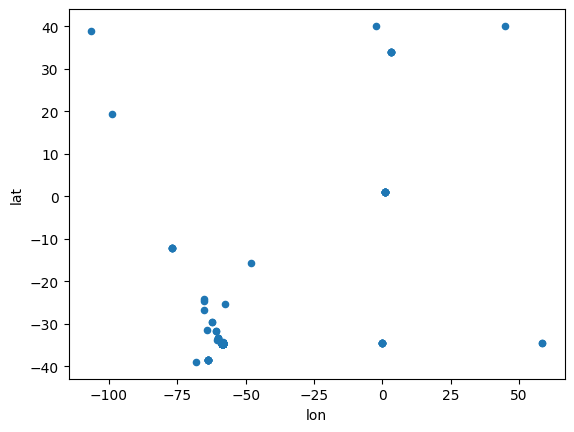

In [ ]:
df_ent.plot.scatter("lon", "lat")

<Axes: xlabel='lon', ylabel='lat'>

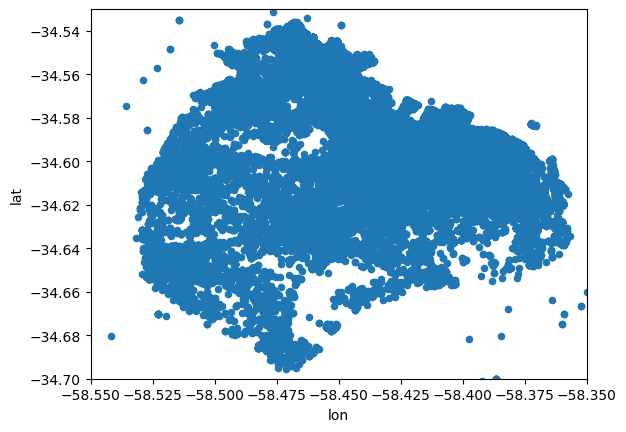

In [ ]:
# Me fui acercando a mano a que me quede CABA
df_ent.plot.scatter(x="lon", y="lat", xlim=(-58.55, -58.35),ylim=(-34.7,-34.53))

In [ ]:
# OUTLIERS

# Convertimos las columnas a float
df_ent["lon"] = pd.to_numeric(df_ent["lon"], errors='coerce')
df_ent["lat"] = pd.to_numeric(df_ent["lat"], errors='coerce')

# Defino los límites
lon_min, lon_max = -58.55, -58.35
lat_min, lat_max = -34.7, -34.53

# Creamos la condición (True si está dentro, False si está fuera)
dentro_limites = (
    df_ent["lon"].between(lon_min, lon_max) &
    df_ent["lat"].between(lat_min, lat_max)
)

<Axes: title={'center': 'Puntos resaltados dentro del área de interés'}, xlabel='lon', ylabel='lat'>

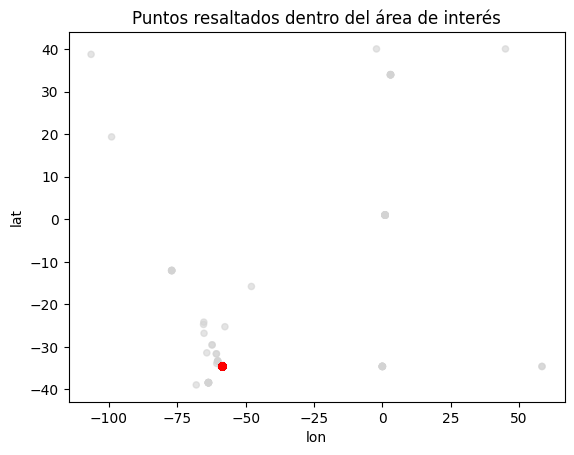

In [ ]:
# Asignamos color: 'blue' si está dentro, 'lightgrey' si está fuera
colores = dentro_limites.map({True: 'red', False: 'lightgrey'})

df_ent.plot.scatter(
    x="lon",
    y="lat",
    c=colores,
    alpha=0.6, # Transparencia para ver puntos encimados
    title="Puntos resaltados dentro del área de interés"
)

In [ ]:
#  Quiero ver el df de los datos que quedan por fuera del rango
#fuera_de_rango = ~(
#    df_ent["lon"].between(lon_min, lon_max) &
#    df_ent["lat"].between(lat_min, lat_max)
#)
#df_ent[fuera_de_rango]

In [ ]:
#sns.heatmap(df_ent.isnull(),yticklabels=False,cbar=False,cmap='viridis')

In [ ]:
# PARA LOS QUE ESTÁN FUERA DE RANGO:
# Calculamos las medianas por cada grupo de location_3
mediana_lat = df_ent.groupby("location_3")["lat"].transform("median")
mediana_lon = df_ent.groupby("location_3")["lon"].transform("median")

# Definimos quiénes son outliers
fuera_de_rango = ~(
    df_ent["lon"].between(lon_min, lon_max) &
    df_ent["lat"].between(lat_min, lat_max)
)

# Opcional: Convertimos los outliers en NaN antes de rellenar
# Esto asegura que el valor incorrecto desaparezca
df_ent.loc[fuera_de_rango, "lat"] = None
df_ent.loc[fuera_de_rango, "lon"] = None

# Rellenamos solo los valores nulos (que eran nuestros outliers)
df_ent["lat"] = df_ent["lat"].fillna(mediana_lat)
df_ent["lon"] = df_ent["lon"].fillna(mediana_lon)

<Axes: title={'center': 'Puntos resaltados dentro del área de interés'}, xlabel='lon', ylabel='lat'>

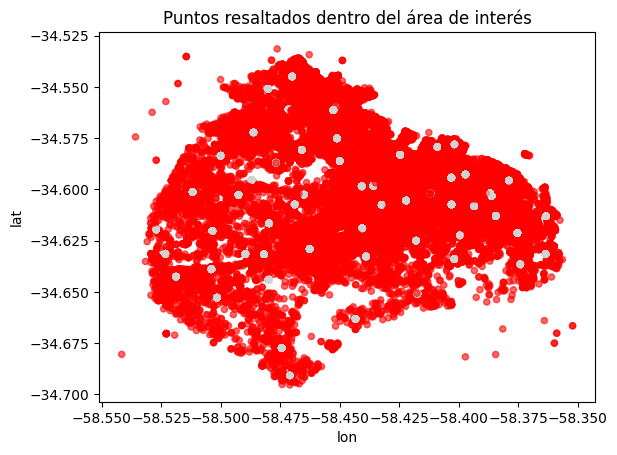

In [ ]:
# Asignamos color: 'blue' si está dentro, 'lightgrey' si está fuera
colores = dentro_limites.map({True: 'red', False: 'lightgrey'})

df_ent.plot.scatter(
    x="lon",
    y="lat",
    c=colores,
    alpha=0.6, # Transparencia para ver puntos encimados
    title="Puntos resaltados dentro del área de interés"
)

In [ ]:
# Defino los límites
lon_min, lon_max = -58.55, -58.35
lat_min, lat_max = -34.7, -34.53

# Creamos la condición (True si está dentro, False si está fuera)
dentro_limites = (
    df_ap["lon"].between(lon_min, lon_max) &
    df_ap["lat"].between(lat_min, lat_max)
)

# 1. Aseguramos que las columnas sean numéricas en df_ap
df_ap["lon"] = pd.to_numeric(df_ap["lon"], errors='coerce')
df_ap["lat"] = pd.to_numeric(df_ap["lat"], errors='coerce')

# 2. Calculamos las medianas por location_3 específicamente para df_ap
mediana_lat_ap = df_ap.groupby("location_3")["lat"].transform("median")
mediana_lon_ap = df_ap.groupby("location_3")["lon"].transform("median")

# 3. Identificamos los outliers en df_ap
fuera_de_rango_ap = ~(
    df_ap["lon"].between(lon_min, lon_max) &
    df_ap["lat"].between(lat_min, lat_max)
)

# 4. Limpiamos y rellenamos
# Seteamos como None los que están fuera de rango
df_ap.loc[fuera_de_rango_ap, "lat"] = None
df_ap.loc[fuera_de_rango_ap, "lon"] = None

# Rellenamos con las medianas calculadas
df_ap["lat"] = df_ap["lat"].fillna(mediana_lat_ap)
df_ap["lon"] = df_ap["lon"].fillna(mediana_lon_ap)

# 5. Plan de respaldo: si alguna location_3 quedó vacía, usamos la mediana global de df_ap
df_ap["lat"] = df_ap["lat"].fillna(df_ap["lat"].median())
df_ap["lon"] = df_ap["lon"].fillna(df_ap["lon"].median())

<Axes: title={'center': 'Puntos resaltados dentro del área de interés'}, xlabel='lon', ylabel='lat'>

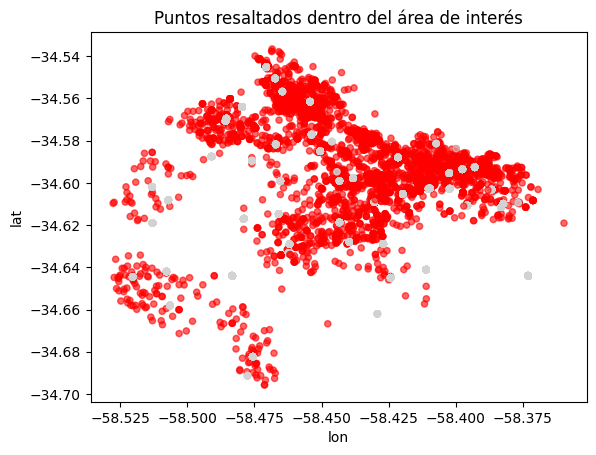

In [ ]:
# Asignamos color: 'blue' si está dentro, 'lightgrey' si está fuera
colores = dentro_limites.map({True: 'red', False: 'lightgrey'})

df_ap.plot.scatter(
    x="lon",
    y="lat",
    c=colores,
    alpha=0.6, # Transparencia para ver puntos encimados
    title="Puntos resaltados dentro del área de interés"
)

In [ ]:
"""
df_ent['lat'] = pd.to_numeric(df_ent['lat'], errors='coerce')
df_ent['lon'] = pd.to_numeric(df_ent['lon'], errors='coerce')

for col in ['lat', 'lon']:
    # Prioridad 1: location_3
    l3_map = df_ent.groupby('location_3')[col].transform('mean')
    df_ent[col] = df_ent[col].fillna(l3_map)

    # Prioridad 2: location_2
    l2_map = df_ent.groupby('location_2')[col].transform('mean')
    df_ent[col] = df_ent[col].fillna(l2_map)
"""

"\ndf_ent['lat'] = pd.to_numeric(df_ent['lat'], errors='coerce')\ndf_ent['lon'] = pd.to_numeric(df_ent['lon'], errors='coerce')\n\nfor col in ['lat', 'lon']:\n    # Prioridad 1: location_3\n    l3_map = df_ent.groupby('location_3')[col].transform('mean')\n    df_ent[col] = df_ent[col].fillna(l3_map)\n\n    # Prioridad 2: location_2\n    l2_map = df_ent.groupby('location_2')[col].transform('mean')\n    df_ent[col] = df_ent[col].fillna(l2_map)\n"

In [ ]:
"""
df_ap['lat'] = pd.to_numeric(df_ap['lat'], errors='coerce')
df_ap['lon'] = pd.to_numeric(df_ap['lon'], errors='coerce')

for col in ['lat', 'lon']:
    # Prioridad 1: location_3
    l3_map = df_ap.groupby('location_3')[col].transform('mean')
    df_ap[col] = df_ap[col].fillna(l3_map)

    # Prioridad 2: location_2
    l2_map = df_ap.groupby('location_2')[col].transform('mean')
    df_ap[col] = df_ap[col].fillna(l2_map)
"""

"\ndf_ap['lat'] = pd.to_numeric(df_ap['lat'], errors='coerce')\ndf_ap['lon'] = pd.to_numeric(df_ap['lon'], errors='coerce')\n\nfor col in ['lat', 'lon']:\n    # Prioridad 1: location_3\n    l3_map = df_ap.groupby('location_3')[col].transform('mean')\n    df_ap[col] = df_ap[col].fillna(l3_map)\n\n    # Prioridad 2: location_2\n    l2_map = df_ap.groupby('location_2')[col].transform('mean')\n    df_ap[col] = df_ap[col].fillna(l2_map)\n"

In [ ]:
#sns.heatmap(df_ent.isnull(),yticklabels=False,cbar=False,cmap='viridis')

## PRECIO

In [ ]:
df_ent.shape

(110695, 17)

In [ ]:
df_ent = df_ent.loc[df_ent['price'] <10000000]

In [ ]:
# Las variables q siguen las creé para ver/marcar registros que no deberían estar, el problema es que en df_ap también aparecen
# entonces decidí dejarlas como variable

In [ ]:
# CAMIONES
patron_camion = r'\b(camion|camión|camiones)\b'
df_ent["es_camion"] = df_ent['description'].str.contains(patron_camion, case=False, na=False).astype(int)
df_ap["es_camion"] = df_ap['description'].str.contains(patron_camion, case=False, na=False).astype(int)

#df_ent = df_ent.loc[df_ent['es_camion'] !=1]
#df_ap = df_ap.loc[df_ap['es_camion'] !=1]

#df_ent = df_ent.drop('es_camion', axis=1)
#df_ap = df_ap.drop('es_camion', axis=1)

/tmp/ipykernel_145/156382184.py:3: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df_ent["es_camion"] = df_ent['description'].str.contains(patron_camion, case=False, na=False).astype(int)
/tmp/ipykernel_145/156382184.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ent["es_camion"] = df_ent['description'].str.contains(patron_camion, case=False, na=False).astype(int)
/tmp/ipykernel_145/156382184.py:4: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df_ap["es_camion"] = df_ap['description'].str.contains(patron_camion, case=False, na=False).astype(int)


In [ ]:
# NORDELTA
patron_nordelta = r'\b(nordelta)\b'
df_ent["es_nordelta"] = df_ent['description'].str.contains(patron_nordelta, case=False, na=False).astype(int)
df_ap["es_nordelta"] = df_ap['description'].str.contains(patron_nordelta, case=False, na=False).astype(int)

#df_ent = df_ent.loc[df_ent['es_nordelta'] !=1]
#df_ap = df_ap.loc[df_ap['es_nordelta'] !=1]

#df_ent = df_ent.drop('es_nordelta', axis=1)
#df_ap = df_ap.drop('es_nordelta', axis=1)

/tmp/ipykernel_145/2771346978.py:3: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df_ent["es_nordelta"] = df_ent['description'].str.contains(patron_nordelta, case=False, na=False).astype(int)
/tmp/ipykernel_145/2771346978.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ent["es_nordelta"] = df_ent['description'].str.contains(patron_nordelta, case=False, na=False).astype(int)
/tmp/ipykernel_145/2771346978.py:4: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df_ap["es_nordelta"] = df_ap['description'].str.contains(patron_nordelta, case=False, na=False).astype(int)


In [ ]:
# MONTACARGAS
patron_montacargas = r'\b(montacarga|montacargas)\b'
df_ent["es_montacargas"] = df_ent['description'].str.contains(patron_montacargas, case=False, na=False).astype(int)
df_ap["es_montacargas"] = df_ap['description'].str.contains(patron_montacargas, case=False, na=False).astype(int)

#df_ent = df_ent.loc[df_ent['es_montacargas'] !=1]
#df_ap = df_ap.loc[df_ap['es_montacargas'] !=1]

#df_ent = df_ent.drop('es_montacargas', axis=1)
#df_ap = df_ap.drop('es_montacargas', axis=1)

/tmp/ipykernel_145/3558984777.py:3: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df_ent["es_montacargas"] = df_ent['description'].str.contains(patron_montacargas, case=False, na=False).astype(int)
/tmp/ipykernel_145/3558984777.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ent["es_montacargas"] = df_ent['description'].str.contains(patron_montacargas, case=False, na=False).astype(int)
/tmp/ipykernel_145/3558984777.py:4: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df_ap["es_montacargas"] = df_ap['description'].str.contains(patron_montacargas, case=False, na=False

In [ ]:
# DEPOSITO
patron_deposito = r'\b(deposito en venta|venta deposito|galpón en venta|galpones a refaccionar|depósito en venta|venta depósito|galpón en venta|galpon en venta|vende galpon|vende galpón|galpón alquiler|galpon alquiler|galpón en alquiler|galpon en alquiler|se alquila galpón|se alquila galpon|amplio depósito)\b'
df_ent["es_deposito"] = df_ent['description'].str.contains(patron_deposito, case=False, na=False).astype(int)
df_ap["es_deposito"] = df_ap['description'].str.contains(patron_deposito, case=False, na=False).astype(int)

#df_ent = df_ent.loc[df_ent['es_deposito'] !=1]
#df_ap = df_ap.loc[df_ap['es_deposito'] !=1]

#df_ent = df_ent.drop('es_deposito', axis=1)
#df_ap = df_ap.drop('es_deposito', axis=1)

/tmp/ipykernel_145/3465157998.py:3: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df_ent["es_deposito"] = df_ent['description'].str.contains(patron_deposito, case=False, na=False).astype(int)
/tmp/ipykernel_145/3465157998.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ent["es_deposito"] = df_ent['description'].str.contains(patron_deposito, case=False, na=False).astype(int)
/tmp/ipykernel_145/3465157998.py:4: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df_ap["es_deposito"] = df_ap['description'].str.contains(patron_deposito, case=False, na=False).astype(int)


In [ ]:
# LOTE
patron_lote = r'\b(lote unico|lote único|lote en venta|espectacular lote|lote importante casona|vende lote|venta de lote)\b'
df_ent["es_lote"] = df_ent['description'].str.contains(patron_lote, case=False, na=False).astype(int)
df_ap["es_lote"] = df_ap['description'].str.contains(patron_lote, case=False, na=False).astype(int)

#df_ent = df_ent.loc[df_ent['es_lote'] !=1]
#df_ap = df_ap.loc[df_ap['es_lote'] !=1]

#df_ent = df_ent.drop('es_lote', axis=1)
#df_ap = df_ap.drop('es_lote', axis=1)

/tmp/ipykernel_145/2852499661.py:3: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df_ent["es_lote"] = df_ent['description'].str.contains(patron_lote, case=False, na=False).astype(int)
/tmp/ipykernel_145/2852499661.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ent["es_lote"] = df_ent['description'].str.contains(patron_lote, case=False, na=False).astype(int)
/tmp/ipykernel_145/2852499661.py:4: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df_ap["es_lote"] = df_ap['description'].str.contains(patron_lote, case=False, na=False).astype(int)


In [ ]:
# TERRENO
patron_terreno = r'\b(terreno en venta|terreno en esquina|terreno de zonificacion|terreno en|terreno vacío|terreno vacio|gran terreno|terreno grande|importante terreno|vende terreno|venta de terreno)\b'
df_ent["es_terreno"] = df_ent['description'].str.contains(patron_terreno, case=False, na=False).astype(int)
df_ap["es_terreno"] = df_ap['description'].str.contains(patron_terreno, case=False, na=False).astype(int)

#df_ent = df_ent.loc[df_ent['es_terreno'] !=1]
#df_ap = df_ap.loc[df_ap['es_terreno'] !=1]

#df_ent = df_ent.drop('es_terreno', axis=1)
#df_ap = df_ap.drop('es_terreno', axis=1)

/tmp/ipykernel_145/1044830897.py:3: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df_ent["es_terreno"] = df_ent['description'].str.contains(patron_terreno, case=False, na=False).astype(int)
/tmp/ipykernel_145/1044830897.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ent["es_terreno"] = df_ent['description'].str.contains(patron_terreno, case=False, na=False).astype(int)
/tmp/ipykernel_145/1044830897.py:4: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df_ap["es_terreno"] = df_ap['description'].str.contains(patron_terreno, case=False, na=False).astype(int)


In [ ]:
# Venta hotel
patron_hotel = r'\b(venta hotel|hotel en venta|petithotel)\b'
df_ent.loc[:, 'ventahotel'] = df_ent['description'].str.contains(patron_hotel, case=False, na=False).astype(int)

# Terreno
#patron_terreno = r'\b(terreno en venta|terreno en esquina|terreno de zonificacion|terreno en almagro)\b'
#df_ent.loc[:, 'terreno'] = df_ent['description'].str.contains(patron_terreno, case=False, na=False).astype(int)

# Penthouse
#patron_ph = r'\b(penthouse a estrenar|excelente pent-house|venta departamento penthouse|penthouses piso|penthouse en torre|penthouse en duplex|increíble penthouse|exclusivo penthouse)\b'
#df_ent.loc[:, 'penthouse'] = df_ent['description'].str.contains(patron_ph, case=False, na=False).astype(int)

# Triplex
#patron_triplex = r'\b(es un triplex|triplex de 4 ambientes|penthouse tríplex|triplex en penthouse)\b'
#df_ent.loc[:, 'triplex'] = df_ent['description'].str.contains(patron_triplex, case=False, na=False).astype(int)

# Duplex
#patron_duplex = r'\b(es un duplex|venta penthouse duplex|exclusivo dúplex reciclado|duplex a estrenar|duplex de 3 ambientes|dúplex muy alto|dúplex en venta)\b'
#df_ent.loc[:, 'duplex'] = df_ent['description'].str.contains(patron_duplex, case=False, na=False).astype(int)


/tmp/ipykernel_145/3407929903.py:3: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df_ent.loc[:, 'ventahotel'] = df_ent['description'].str.contains(patron_hotel, case=False, na=False).astype(int)
/tmp/ipykernel_145/3407929903.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ent.loc[:, 'ventahotel'] = df_ent['description'].str.contains(patron_hotel, case=False, na=False).astype(int)


In [ ]:
#df_ent[df_ent['penthouse']==1].head(5)

In [ ]:
df_ent.shape

(110684, 24)

In [ ]:
df_ap.shape

(13471, 23)

In [ ]:
#df_ent = df_ent.loc[df_ent['camiones'] !=1]
df_ent = df_ent.loc[df_ent['ventahotel'] !=1]
#df_ent = df_ent.loc[df_ent['nordelta'] !=1]
#df_ent = df_ent.loc[df_ent['deposito'] !=1]
#df_ent = df_ent.loc[df_ent['terreno'] !=1]
#df_ent = df_ent.loc[df_ent['lote'] !=1]
#df_ent = df_ent.loc[df_ent['montacargas'] !=1]
#df_ent = df_ent.loc[df_ent['penthouse'] !=1]
#df_ent = df_ent.loc[df_ent['triplex'] !=1]
#df_ent = df_ent.loc[df_ent['duplex'] !=1]

In [ ]:
#df_ent = df_ent.drop(columns=['camiones',"ventahotel","nordelta","deposito","terreno","lote","montacargas","penthouse","triplex","duplex"])
df_ent = df_ent.drop('ventahotel', axis=1)

In [ ]:
df_ent.shape

(110672, 23)

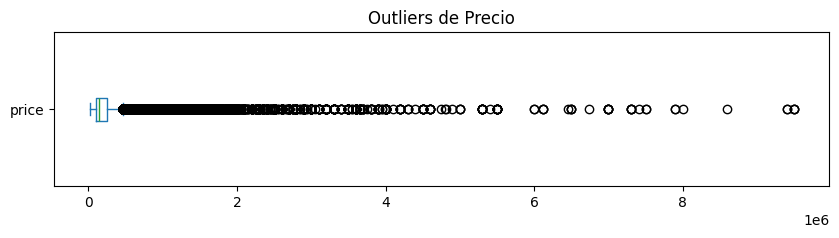

In [ ]:
# OUTLIERS DE PRECIO EN GENERAL, SIN BARRIO
df_ent["price"].plot(kind='box', vert=False, figsize=(10, 2))
plt.title("Outliers de Precio")
plt.show()

In [ ]:
#df_ent[df_ent["price"]>7000000]

### PRECIO POR BARRIO

In [ ]:
# REVISAR

In [ ]:
## FILTROS
# Conservamos registros que NO sean Balvanera O que, siendo Balvanera, cuesten menos de 1M
#df_ent = df_ent[(df_ent['location_3'] != 'Balvanera') | (df_ent['price'] < 1000000)]
#df_ent = df_ent[(df_ent['location_3'] != 'Ciudad Autónoma de Buenos Aires') | (df_ent['price'] < 4000000)]


In [ ]:
# BARRIOS QUE HAY EN DF_AP
with pd.option_context('display.max_rows', None):
    print(df_ap["location_3"].value_counts())

location_3
Palermo                            1093
Ciudad Autónoma de Buenos Aires    1008
Caballito                           833
Belgrano                            787
Recoleta                            777
Villa Urquiza                       636
Almagro                             621
Villa Crespo                        596
Villa Devoto                        411
Flores                              388
Liniers                             348
Villa del Parque                    319
Barrio Norte                        290
Villa Luro                          278
Saavedra                            272
Puerto Madero                       272
Nuñez                               248
Colegiales                          241
Mataderos                           215
Barracas                            209
Parque Chacabuco                    199
San Telmo                           180
Boedo                               178
Balvanera                           174
Villa Pueyrredon             

In [ ]:
# BARRIOS QUE HAY EN DF_ENT
with pd.option_context('display.max_rows', None):
    print(df_ent["location_3"].value_counts())

location_3
Palermo                            11430
Belgrano                            8160
Ciudad Autónoma de Buenos Aires     6449
Caballito                           6382
Recoleta                            5962
Constitucion                        5717
Villa Crespo                        4383
Nuñez                               4302
Villa Urquiza                       4266
Almagro                             4185
Balvanera                           3656
Flores                              3131
Villa Devoto                        2276
Barrio Norte                        2202
Colegiales                          2052
Monserrat                           1547
San Nicolás                         1496
Barracas                            1457
Villa del Parque                    1450
San Cristobal                       1447
San Telmo                           1398
Saavedra                            1305
Liniers                             1284
Villa Luro                          1236
Retir

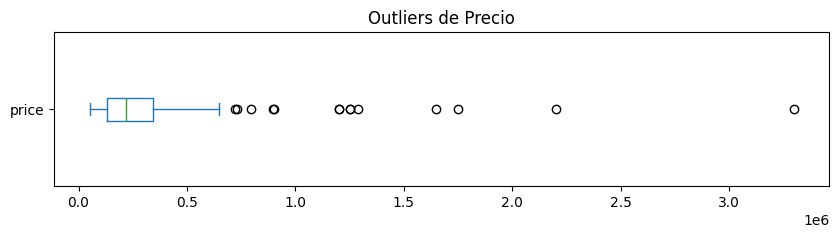

In [ ]:
# Esto lo use para ir mirando por barrio
df_barrio = df_ent[df_ent["location_3"] == "Belgrano C"]
df_barrio["price"].plot(kind='box', vert=False, figsize=(10, 2))
plt.title("Outliers de Precio")
plt.show()

In [ ]:
df_barrio[df_barrio["price"]>1000000].head(3)

,description,address,lat,lon,publication_date,publisher_id,features,location_0,location_1,location_2,...,source,price,currency_type,location_2_aux,es_camion,es_nordelta,es_montacargas,es_deposito,es_lote,es_terreno
id,,,,,,,,,,,,,,,,,,,,,
98447,exclusivo penthouse en dúplex – piso 24 en tor...,"2222, Calle Arcos 2581, Buenos Aires, Ciudad A...",-34.555744,-58.457718,28 nov 2025,None,3 dormitorios;3 baños;220 m²;garage;cerca de:,Argentina,Capital Federal,Capital Federal,...,properati,1250000.0,dolares,Buenos Aires,0,0,0,0,0,0
388796,forum alcorta – ramsay - belgrano chico<br />...,Ramsay al 2000,-34.553185,-58.439175,2026-01-02T00:18:06Z,17622787,cantidad plantas: 1; cobertura cochera: cubier...,Argentina,Capital Federal,Capital Federal,...,zonaprop,3300000.0,dolares,Belgrano,0,0,0,0,0,0
470943,reciclado de revista 548 mts. 5 dor + play<br>...,Virrey Del Pino 1800,-34.563114,-58.446175,2025-09-12T13:38:45Z,17083796,departamentos por piso: 0; cantidad plantas: 2...,Argentina,Capital Federal,Capital Federal,...,zonaprop,1650000.0,dolares,Belgrano,0,0,0,0,0,0


In [ ]:
# ESTOS TENÍAN ADDRESS PERO ASIGNADA Ciudad Autónoma de Buenos Aires EN LOCATION_3

In [ ]:
df_ent = df_ent.drop(700954) #repetido y muuuy caro de barrio parque

In [ ]:
# Definimos la lista de variantes
patron = 'forum alcorta|forum alcorta,'

df_ent.loc[df_ent['description'].str.contains(patron, case=False, na=False), 'location_3'] = 'Belgrano Chico'
df_ap.loc[df_ap['description'].str.contains(patron, case=False, na=False), 'location_3'] = 'Belgrano Chico'

In [ ]:
# Definimos la lista de variantes
patron = 'Ramsay 2081|Forum Alcorta|Calle Ramsay 2002-2100'

df_ent.loc[df_ent['address'].str.contains(patron, case=False, na=False), 'location_3'] = 'Belgrano Chico'
df_ap.loc[df_ap['address'].str.contains(patron, case=False, na=False), 'location_3'] = 'Belgrano Chico'

In [ ]:
df_ent.loc[106080, 'location_2'] = 'Capital Federal'
df_ent.loc[106080, 'location_3'] = 'Recoleta'

df_ent.loc[114469, 'location_2'] = 'Capital Federal'
df_ent.loc[114469, 'location_3'] = 'Nuñez'

df_ent.loc[112684, 'location_2'] = 'Capital Federal'
df_ent.loc[112684, 'location_3'] = 'Nuñez'

df_ent.loc[112685, 'location_2'] = 'Capital Federal'
df_ent.loc[112685, 'location_3'] = 'Nuñez'

df_ent.loc[112711, 'location_2'] = 'Capital Federal'
df_ent.loc[112711, 'location_3'] = 'Nuñez'

df_ent.loc[112652, 'location_2'] = 'Capital Federal'
df_ent.loc[112652, 'location_3'] = 'Nuñez'

df_ent.loc[110149, 'location_2'] = 'Capital Federal'
df_ent.loc[110149, 'location_3'] = 'Palermo Soho'

df_ent.loc[324340, 'location_2'] = 'Capital Federal'
df_ent.loc[324340, 'location_3'] = 'Palermo Chico'

df_ent.loc[266062, 'location_2'] = 'Capital Federal'
df_ent.loc[266062, 'location_3'] = 'Palermo Chico'

df_ent.loc[324488, 'location_2'] = 'Capital Federal'
df_ent.loc[324488, 'location_3'] = 'Palermo Chico'

df_ent.loc[324729, 'location_2'] = 'Capital Federal'
df_ent.loc[324729, 'location_3'] = 'Palermo Chico'

df_ent.loc[98827, 'location_2'] = 'Capital Federal'
df_ent.loc[98827, 'location_3'] = 'Belgrano Chico'

df_ent.loc[98233, 'location_2'] = 'Capital Federal'
df_ent.loc[98233, 'location_3'] = 'Belgrano'

df_ent.loc[105420, 'location_2'] = 'Capital Federal'
df_ent.loc[105420, 'location_3'] = 'Recoleta'

df_ent.loc[114257, 'location_2'] = 'Capital Federal'
df_ent.loc[114257, 'location_3'] = 'Nuñez'

df_ent.loc[114502, 'location_2'] = 'Capital Federal'
df_ent.loc[114502, 'location_3'] = 'Nuñez'

df_ent.loc[98309, 'location_2'] = 'Capital Federal'
df_ent.loc[98309, 'location_3'] = 'Belgrano Chico'

df_ent.loc[97788, 'location_2'] = 'Capital Federal'
df_ent.loc[97788, 'location_3'] = 'Belgrano Chico'

df_ent.loc[324406, 'location_2'] = 'Capital Federal'
df_ent.loc[324406, 'location_3'] = 'Palermo Chico'

df_ent.loc[96874, 'location_2'] = 'Capital Federal'
df_ent.loc[96874, 'location_3'] = 'Belgrano'

df_ent.loc[324743, 'location_2'] = 'Capital Federal'
df_ent.loc[324743, 'location_3'] = 'Palermo Chico'

<Axes: title={'center': 'Puntos en CABA'}, xlabel='lon', ylabel='lat'>

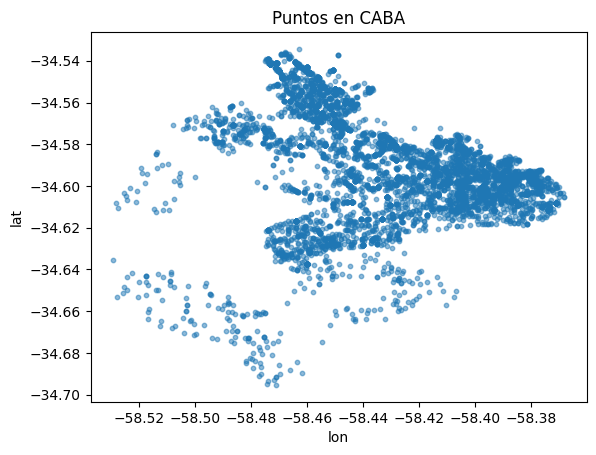

In [ ]:
# CIUDAD AUTONOMA DE BUENOS AIRES
# 1. Filtramos el DataFrame
df_caba = df_ent[df_ent["location_3"] == "Ciudad Autónoma de Buenos Aires"]

# 2. Graficamos sobre el DataFrame filtrado
df_caba.plot.scatter(
    x="lon",
    y="lat",
    #xlim=(-58.55, -58.35),
    #ylim=(-34.7, -34.53),
    alpha=0.5,           # Añadimos transparencia para ver la densidad
    s=10,                # Tamaño de los puntos
    title="Puntos en CABA"
)

<Axes: title={'center': 'Puntos en CABA'}, xlabel='lon', ylabel='lat'>

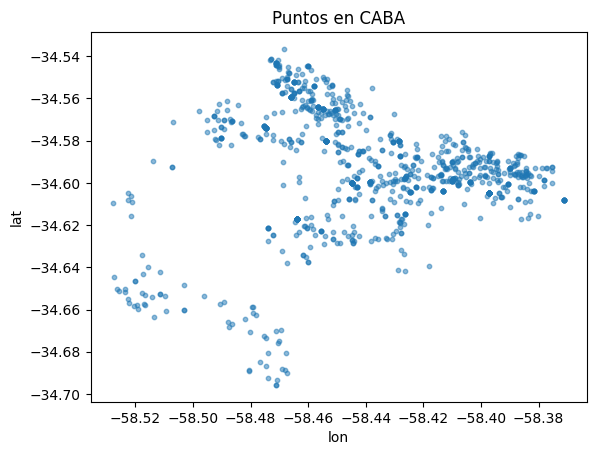

In [ ]:
# CIUDAD AUTONOMA DE BUENOS AIRES
# 1. Filtramos el DataFrame
df_caba_ap = df_ap[df_ap["location_3"] == "Ciudad Autónoma de Buenos Aires"]

# 2. Graficamos sobre el DataFrame filtrado
df_caba_ap.plot.scatter(
    x="lon",
    y="lat",
    #xlim=(-58.55, -58.35),
    #ylim=(-34.7, -34.53),
    alpha=0.5,           # Añadimos transparencia para ver la densidad
    s=10,                # Tamaño de los puntos
    title="Puntos en CABA"
)

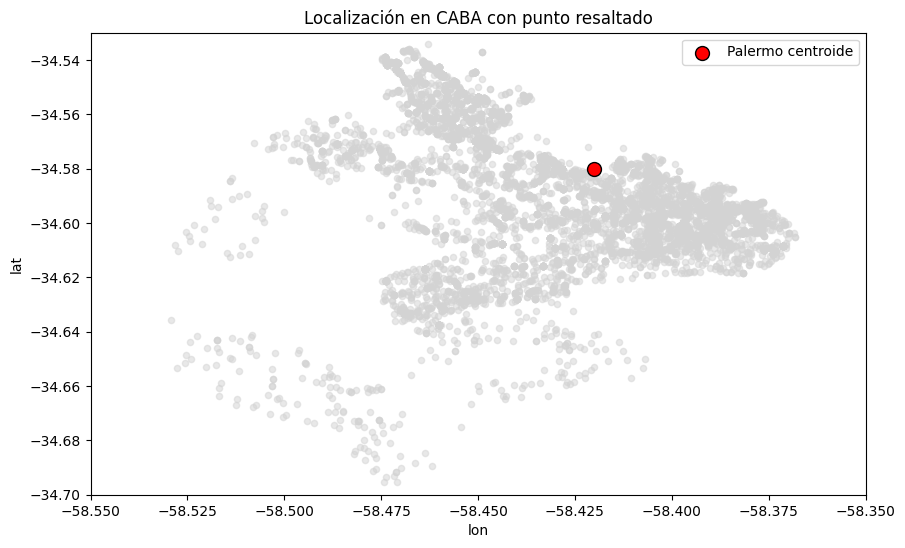

In [ ]:
# 1. Filtramos los datos de CABA
df_caba = df_ent[df_ent["location_3"] == "Ciudad Autónoma de Buenos Aires"]

# 2. Creamos el gráfico base
ax = df_caba.plot.scatter(
    x="lon",
    y="lat",
    xlim=(-58.55, -58.35),
    ylim=(-34.7, -34.53),
    color="lightgrey",   # Fondo en gris para que resalte el punto rojo
    alpha=0.5,
    figsize=(10, 6)
)

# 3. Dibujamos el punto específico encima
# Nota: scatter(x, y) -> lon es x, lat es y.
# Tu punto es lat: -34.58, lon: -58.42
plt.scatter(-58.42, -34.58, color="red", s=100, label="Palermo centroide", edgecolor='black')

plt.title("Localización en CABA con punto resaltado")
plt.legend()
plt.show()

## NUEVAS VARIABLES

In [ ]:
df_ent["es_casa"] = df_ent["property_type"].str.contains("casa", case=False, na=False).astype(int)
df_ap["es_casa"] = df_ap["property_type"].str.contains("casa", case=False, na=False).astype(int)

In [ ]:
df_ent = df_ent.drop('location_2_aux', axis=1)

In [ ]:
df_ap = df_ap.drop('location_2_aux', axis=1)

In [ ]:
df_ent = df_ent.drop('location_1', axis=1)

In [ ]:
df_ap = df_ap.drop('location_1', axis=1)

In [ ]:
df_ent = df_ent.drop('location_0', axis=1)

In [ ]:
df_ap = df_ap.drop('location_0', axis=1)

In [ ]:
## METROS CUADRADOS --> despues mas abajo lo sigo mejorando con baños y dormitorios
#def saco_m2(texto):
#    if pd.isna(texto):
#        return np.nan
#    texto = str(texto)
#    m = re.search(r"(\d+)\s*m²", texto, re.IGNORECASE)
#    if m:
#        return float(m.group(1))
#    m = re.search(r"(\d+)\s*m2", texto, re.IGNORECASE)
#    if m:
#        return float(m.group(1))
#    return np.nan
#df_ent["m2"] = df_ent["features"].apply(saco_m2)

In [ ]:
#zonaprop=df_ent[df_ent["source"]=="properati"]
#zonaprop[["description","features","features_estandarizado","m2"]].sample(10)

### M2

In [ ]:
def limpiar_puntos_multiples(val):
    if not isinstance(val, str):
        return val
    # Quitamos todos los puntos menos el último
    if val.count('.') > 1:
        partes = val.split('.')
        # Une todo menos el último con nada, y pega el último con un punto
        val = "".join(partes[:-1]) + "." + partes[-1]
    return val

In [ ]:
#PARA COMPLETAR NULOS DE M2 - DF ENT - ZONAPROP
# El regex busca "stotal:", permite espacios (\s*) y captura el número (\d+\.?\d*)
#pattern_stotal = r'stotal:\s*(\d+\.?\d*)'
pattern_stotal = r'stotal:\s*([0-9,.]+)'

# Extraemos de la columna features
#extracted_stotal = df_ent['features'].str.lower().str.extract(pattern_stotal).astype(float)
extracted_stotal = df_ent['features'].str.lower().str.extract(pattern_stotal)[0]

# 3. Reemplazamos coma por punto y convertimos a float
extracted_final = (extracted_stotal
                   .str.replace(',', '.')
                   .apply(limpiar_puntos_multiples)
                   .astype(float))

# Asignamos a la columna m2 solo donde sea nulo
#df_ent['m2'] = df_ent['m2'].fillna(extracted_stotal[0])
df_ent['m2'] = extracted_final

In [ ]:
#PARA COMPLETAR NULOS DE M2 - DF AP - ZONAPROP
# El regex busca "stotal:", permite espacios (\s*) y captura el número (\d+\.?\d*)
#pattern_stotal = r'stotal:\s*(\d+\.?\d*)'
pattern_stotal = r'stotal:\s*([0-9,.]+)'

# Extraemos de la columna features
#extracted_stotal = df_ap['features'].str.lower().str.extract(pattern_stotal).astype(float)
extracted_stotal = df_ap['features'].str.lower().str.extract(pattern_stotal)[0]

# 3. Reemplazamos coma por punto y convertimos a float
extracted_final = (extracted_stotal
                   .str.replace(',', '.')
                   .apply(limpiar_puntos_multiples)
                   .astype(float))

# Asignamos a la columna m2 solo donde sea nulo
#df_ap['m2'] = df_ap['m2'].fillna(extracted_stotal[0])
df_ap['m2'] = extracted_final

In [ ]:
# Reemplaza los 0 por NaN en la columna m2
df_ent['m2'] = df_ent['m2'].replace(0, np.nan)
df_ap['m2'] = df_ap['m2'].replace(0, np.nan)

In [ ]:
df_ent["m2"].isna().sum()

np.int64(96754)

In [ ]:
#PARA COMPLETAR NULOS DE M2 - DF ENT - ARGENPROP
#pattern = r'sup\.\s*cubierta:(\d+\.?\d*)'
pattern = r'sup\.\s*cubierta:\s*([0-9,.]+)'

# 2. Extraemos el texto (sin convertir a float todavía)
#extracted_m2 = df_ent['features'].str.lower().str.extract(pattern).astype(float)
extracted_m2 = df_ent['features'].str.lower().str.extract(pattern)[0]

# 3. Limpiamos: cambiamos coma por punto y convertimos a float
#extracted_m2_clean = extracted_m2.str.replace(',', '.').astype(float)
extracted_final = (extracted_m2
                   .str.replace(',', '.')
                   .apply(limpiar_puntos_multiples)
                   .astype(float))

# 3. Llenamos los nulos de la columna m2 original
df_ent['m2'] = df_ent['m2'].fillna(extracted_final)

In [ ]:
#PARA COMPLETAR NULOS DE M2 - DF AP - ARGENPROP
#pattern = r'sup\.\s*cubierta:(\d+\.?\d*)'
pattern = r'sup\.\s*cubierta:\s*([0-9,.]+)'

# 2. Extraemos y convertimos a float
#extracted_m2 = df_ap['features'].str.lower().str.extract(pattern).astype(float)
extracted_m2 = df_ap['features'].str.lower().str.extract(pattern)[0]

# 3. Limpiamos: cambiamos coma por punto y convertimos a float
#extracted_m2_clean = extracted_m2.str.replace(',', '.').astype(float)
extracted_final = (extracted_m2
                   .str.replace(',', '.')
                   .apply(limpiar_puntos_multiples)
                   .astype(float))

# 3. Llenamos los nulos de la columna m2 original
df_ap['m2'] = df_ap['m2'].fillna(extracted_final)

In [ ]:
# Reemplaza los 0 por NaN en la columna m2
df_ent['m2'] = df_ent['m2'].replace(0, np.nan)
df_ap['m2'] = df_ap['m2'].replace(0, np.nan)

In [ ]:
df_ent["m2"].isna().sum()

np.int64(31674)

In [ ]:
#PARA COMPLETAR NULOS DE M2 - DF ENT - PROPERATI
# Buscamos números que estén inmediatamente antes de " m²"
# El patrón \d+ busca los números y \s* contempla si hay espacio o no
pattern_properati = r'([0-9,.]+)\s*m²'

# Extraemos de la columna features (o la que corresponda de Properati)
extracted_m2 = df_ent['features'].str.extract(pattern_properati)[0]

# Reemplazamos la coma por el punto para que Python lo reconozca como decimal
# Luego convertimos a float
#extracted_m2_clean = extracted_m2.str.replace(',', '.').astype(float)
extracted_final = (extracted_m2
                   .str.replace(',', '.')
                   .apply(limpiar_puntos_multiples)
                   .astype(float))

# Llenamos nulos en la columna m2 principal
df_ent['m2'] = df_ent['m2'].fillna(extracted_final)

In [ ]:
#PARA COMPLETAR NULOS DE M2 - DF AP - PROPERATI
# Buscamos números que estén inmediatamente antes de " m²"
# El patrón \d+ busca los números y \s* contempla si hay espacio o no
pattern_properati = r'([0-9,.]+)\s*m²'

# Extraemos de la columna features (o la que corresponda de Properati)
extracted_m2 = df_ap['features'].str.extract(pattern_properati)[0]

# Reemplazamos la coma por el punto para que Python lo reconozca como decimal
# Luego convertimos a float
#extracted_m2_clean = extracted_m2.str.replace(',', '.').astype(float)
extracted_final = (extracted_m2
                   .str.replace(',', '.')
                   .apply(limpiar_puntos_multiples)
                   .astype(float))

# Llenamos nulos en la columna m2 principal
df_ap['m2'] = df_ap['m2'].fillna(extracted_final)

In [ ]:
# Reemplaza los 0 por NaN en la columna m2
df_ent['m2'] = df_ent['m2'].replace(0, np.nan)
df_ap['m2'] = df_ap['m2'].replace(0, np.nan)

In [ ]:
df_ent["m2"].isna().sum()

np.int64(12173)

In [ ]:
# Buscamos "superficie total", luego dos puntos, y capturamos el número
# El patrón \d+ captura el número
# m[2²] acepta el 2 normal o el símbolo de cuadrado
#patron_total = r'superficie total:\s*(\d+)'
patron_total = r'superficie total:\s*([0-9,.]+)'

#extracted_total = df_ent['features'].str.lower().str.extract(patron_total).astype(float).fillna(0)
extracted_total = df_ent['features'].str.lower().str.extract(patron_total)[0]

extracted_final = (extracted_total
                   .str.replace(',', '.')
                   .apply(limpiar_puntos_multiples)
                   .astype(float))

# Asignamos a la columna m2 solo donde sea nulo
df_ent['m2'] = df_ent['m2'].fillna(extracted_final)

In [ ]:
# Buscamos "superficie total", luego dos puntos, y capturamos el número
# El patrón \d+ captura el número
# m[2²] acepta el 2 normal o el símbolo de cuadrado
#patron_total = r'superficie total:\s*(\d+)'
patron_total = r'superficie total:\s*([0-9,.]+)'

#extracted_total = df_ap['features'].str.lower().str.extract(patron_total).astype(float).fillna(0)
extracted_total = df_ap['features'].str.lower().str.extract(patron_total)[0]

extracted_final = (extracted_total
                   .str.replace(',', '.')
                   .apply(limpiar_puntos_multiples)
                   .astype(float))

# Asignamos a la columna m2 solo donde sea nulo
df_ap['m2'] = df_ap['m2'].fillna(extracted_final)

In [ ]:
# Reemplaza los 0 por NaN en la columna m2
df_ent['m2'] = df_ent['m2'].replace(0, np.nan)
df_ap['m2'] = df_ap['m2'].replace(0, np.nan)

In [ ]:
df_ent["m2"].isna().sum()

np.int64(11536)

In [ ]:
# Buscamos "superficie del terreno", dos puntos y el número
#patron_terreno = r'superficie del terreno:\s*(\d+)'
patron_terreno = r'superficie del terreno:\s*([0-9,.]+)'

#extracted_terreno = df_ent['features'].str.lower().str.extract(patron_terreno).astype(float).fillna(0)
extracted_terreno = df_ent['features'].str.lower().str.extract(patron_terreno)[0]

extracted_terreno_final = (extracted_terreno
                           .str.replace(',', '.')
                           .apply(limpiar_puntos_multiples)
                           .astype(float))

# Asignamos a la columna m2 solo donde sea nulo
df_ent['m2'] = df_ent['m2'].fillna(extracted_terreno_final)

In [ ]:
# Buscamos "superficie del terreno", dos puntos y el número
#patron_terreno = r'superficie del terreno:\s*(\d+)'
patron_terreno = r'superficie del terreno:\s*([0-9,.]+)'

#extracted_terreno = df_ap['features'].str.lower().str.extract(patron_terreno).astype(float).fillna(0)
extracted_terreno = df_ap['features'].str.lower().str.extract(patron_terreno)[0]

extracted_terreno_final = (extracted_terreno
                           .str.replace(',', '.')
                           .apply(limpiar_puntos_multiples)
                           .astype(float))

# Asignamos a la columna m2 solo donde sea nulo
df_ap['m2'] = df_ap['m2'].fillna(extracted_terreno_final)

In [ ]:
df_ent["m2"].isna().sum()

np.int64(11536)

In [ ]:
# Reemplaza los 0 por NaN en la columna m2
df_ent['m2'] = df_ent['m2'].replace(0, np.nan)
df_ap['m2'] = df_ap['m2'].replace(0, np.nan)

In [ ]:
# Definimos el patrón:
# "scubierta:" seguido de posibles espacios \s* # y capturamos los dígitos (\d+)
#patron_m2 = r"scubierta:\s*(\d+)"
patron_m2 = r'scubierta:\s*([0-9,.]+)'

# Extraemos el valor para los que tienen m2 (o la columna que uses) en nulo
# str.extract devuelve un DataFrame, así que tomamos la primera columna [0]
#extraidos = df_ent["features"].str.lower().str.extract(patron_m2, expand=False, flags=re.IGNORECASE)
extracted_scubierta = df_ent['features'].str.lower().str.extract(patron_m2)[0]

# Convertimos a numérico (los que no coinciden quedan como NaN)
#extraidos = pd.to_numeric(extraidos, errors='coerce')
extracted_final = (extracted_scubierta
                   .str.replace(',', '.')
                   .apply(limpiar_puntos_multiples)
                   .astype(float))

# Actualizamos solo donde m2 es nulo
#mask = df_ent["m2"].isna()
#df_ent.loc[mask, "m2"] = extraidos
df_ent['m2'] = df_ent['m2'].fillna(extracted_final)

In [ ]:
# Definimos el patrón:
# "scubierta:" seguido de posibles espacios \s* # y capturamos los dígitos (\d+)
#patron_m2 = r"scubierta:\s*(\d+)"
patron_m2 = r'scubierta:\s*([0-9,.]+)'

# Extraemos el valor para los que tienen m2 (o la columna que uses) en nulo
# str.extract devuelve un DataFrame, así que tomamos la primera columna [0]
#extraidos = df_ap["features"].str.lower().str.extract(patron_m2, expand=False, flags=re.IGNORECASE)
extracted_scubierta = df_ap['features'].str.lower().str.extract(patron_m2)[0]

# Convertimos a numérico (los que no coinciden quedan como NaN)
#extraidos = pd.to_numeric(extraidos, errors='coerce')
extracted_final = (extracted_scubierta
                   .str.replace(',', '.')
                   .apply(limpiar_puntos_multiples)
                   .astype(float))

# Actualizamos solo donde m2 es nulo
#mask = df_ap["m2"].isna()
#df_ap.loc[mask, "m2"] = extraidos
df_ap['m2'] = df_ap['m2'].fillna(extracted_final)

In [ ]:
df_ent["m2"].isna().sum()

np.int64(11502)

In [ ]:
# Reemplaza los 0 por NaN en la columna m2
df_ent['m2'] = df_ent['m2'].replace(0, np.nan)
df_ap['m2'] = df_ap['m2'].replace(0, np.nan)

In [ ]:
# Vi que habian muchas palabras parecidas que referian a lo mismo ej toilette y baño
# Por eso creo un campo features_estandarizado → lo uso para unificar palabras como m² , m2, metros cubiertos, etc. ;
# También para unificar palabras de dormitorio y palabras de baño
df_ent["features_estandarizado"] = (
    df_ent["features"].fillna("")
    .str.lower()
    .str.replace("m2", "m²", regex=False)
    .str.replace("metros cuadrados", "m²", regex=False)
    .str.replace("metros cubiertos", "m²", regex=False)
    .str.replace("habitacion", "dormitorios", regex=False)
    .str.replace("habitación", "dormitorios", regex=False)
    .str.replace("habitaciones", "dormitorios", regex=False)
    .str.replace("dorm.", "dormitorios", regex=False)
    .str.replace("dormitorio", "dormitorios", regex=False)
    .str.replace("dormitorioss", "dormitorios", regex=False)
    .str.replace("banos", "baños", regex=False)
    .str.replace("bano", "baños", regex=False)
    .str.replace("baño", "baños", regex=False)
    .str.replace("toilette", "baños", regex=False)
    .str.replace("toilete", "baños", regex=False)
    .str.replace("bañoss", "baños", regex=False)
    #.str.replace("ambiente", "ambientes", regex=False)
)

In [ ]:
df_ap["features_estandarizado"] = (
    df_ap["features"].fillna("")
    .str.lower()
    .str.replace("m2", "m²", regex=False)
    .str.replace("metros cuadrados", "m²", regex=False)
    .str.replace("metros cubiertos", "m²", regex=False)
    .str.replace("habitacion", "dormitorios", regex=False)
    .str.replace("habitación", "dormitorios", regex=False)
    .str.replace("habitaciones", "dormitorios", regex=False)
    .str.replace("dorm.", "dormitorios", regex=False)
    .str.replace("dormitorio", "dormitorios", regex=False)
    .str.replace("dormitorioss", "dormitorios", regex=False)
    .str.replace("banos", "baños", regex=False)
    .str.replace("bano", "baños", regex=False)
    .str.replace("baño", "baños", regex=False)
    .str.replace("toilette", "baños", regex=False)
    .str.replace("toilete", "baños", regex=False)
    .str.replace("bañoss", "baños", regex=False)
    #.str.replace("ambiente", "ambientes", regex=False)
)

In [ ]:
# Extraer cantidad de m2, dormitorios y baños
def obtener_cantidad(text, keyword):
    if pd.isna(text):
        return np.nan
    parts = str(text).split(";") #separa el texto en partes usando el ;
    for part in parts:
        part = part.strip()
        if keyword in part:
            for token in part.split():
                try:
                    return float(token.replace(",", "."))
                except:
                    pass
    return np.nan

# Para df_ent
mask_ent = df_ent["m2"].isna()
df_ent.loc[mask_ent, "m2"] = df_ent.loc[mask_ent, "features_estandarizado"].apply(lambda x: obtener_cantidad(x, "m²"))

# Para df_ap
mask_ap = df_ap["m2"].isna()
df_ap.loc[mask_ap, "m2"] = df_ap.loc[mask_ap, "features_estandarizado"].apply(lambda x: obtener_cantidad(x, "m²"))

In [ ]:
df_ent["m2"].isna().sum()

np.int64(11496)

In [ ]:
# Reemplaza los 0 por NaN en la columna m2
df_ent['m2'] = df_ent['m2'].replace(0, np.nan)
df_ap['m2'] = df_ap['m2'].replace(0, np.nan)

In [ ]:
# PARA COMPLETAR NULOS DE M2 - DF ENT - DESCRIPTION (SUP TOTAL)
# 1. Definimos el patrón: buscamos "sup. total:", espacios, y el número con m2
# El \.? contempla si escriben "sup" con o sin punto
patron_sup_total = r'sup\.?\s*total:\s*([0-9,.]+)\s*m2'

# 2. Extraemos de la descripción
extracted_sup_total = df_ent['description'].str.lower().str.extract(patron_sup_total)[0]

# 3. FILTRO DE SEGURIDAD: Evitamos el error de solo puntos o caracteres sin números
extracted_sup_total = extracted_sup_total.where(extracted_sup_total.str.contains(r'\d', na=False))

# 4. Cadena de limpieza completa
extracted_final = (extracted_sup_total
                   .str.replace(',', '.')
                   .apply(limpiar_puntos_multiples)
                   .astype(float))

# 5. Actualizamos solo donde m2 es nulo
df_ent['m2'] = df_ent['m2'].fillna(extracted_final)

In [ ]:
# PARA COMPLETAR NULOS DE M2 - DF AP - DESCRIPTION (SUP TOTAL)
# 1. Definimos el patrón: buscamos "sup. total:", espacios, y el número con m2
# El \.? contempla si escriben "sup" con o sin punto
patron_sup_total = r'sup\.?\s*total:\s*([0-9,.]+)\s*m2'

# 2. Extraemos de la descripción
extracted_sup_total = df_ap['description'].str.lower().str.extract(patron_sup_total)[0]

# 3. FILTRO DE SEGURIDAD: Evitamos el error de solo puntos o caracteres sin números
extracted_sup_total = extracted_sup_total.where(extracted_sup_total.str.contains(r'\d', na=False))

# 4. Cadena de limpieza completa
extracted_final = (extracted_sup_total
                   .str.replace(',', '.')
                   .apply(limpiar_puntos_multiples)
                   .astype(float))

# 5. Actualizamos solo donde m2 es nulo
df_ap['m2'] = df_ap['m2'].fillna(extracted_final)

In [ ]:
df_ent["m2"].isna().sum()

np.int64(11443)

In [ ]:
# Reemplaza los 0 por NaN en la columna m2
df_ent['m2'] = df_ent['m2'].replace(0, np.nan)
df_ap['m2'] = df_ap['m2'].replace(0, np.nan)

In [ ]:
# PARA COMPLETAR NULOS DE M2 - DF ENT - DESCRIPTION (SUPERFICIE TOTAL EXPLICITA)
# 1. Definimos el patrón:
# [0-9,.]+ captura el número con decimales
# m[2²] captura tanto "m2" como "m²"
patron_total_simbolo = r'superficie\s*total:\s*([0-9,.]+)\s*m[2²]'

# 2. Extraemos de la descripción
extracted_total = df_ent['description'].str.lower().str.extract(patron_total_simbolo)[0]

# 3. FILTRO DE SEGURIDAD: Validamos que haya dígitos para evitar el error del punto solitario
extracted_total = extracted_total.where(extracted_total.str.contains(r'\d', na=False))

# 4. Cadena de limpieza completa
extracted_final = (extracted_total
                   .str.replace(',', '.')
                   .apply(limpiar_puntos_multiples)
                   .astype(float))

# 5. Llenamos nulos en la columna m2
df_ent['m2'] = df_ent['m2'].fillna(extracted_final)

In [ ]:
# PARA COMPLETAR NULOS DE M2 - DF AP - DESCRIPTION (SUPERFICIE TOTAL EXPLICITA)
# 1. Definimos el patrón:
# [0-9,.]+ captura el número con decimales
# m[2²] captura tanto "m2" como "m²"
patron_total_simbolo = r'superficie\s*total:\s*([0-9,.]+)\s*m[2²]'

# 2. Extraemos de la descripción
extracted_total = df_ap['description'].str.lower().str.extract(patron_total_simbolo)[0]

# 3. FILTRO DE SEGURIDAD: Validamos que haya dígitos para evitar el error del punto solitario
extracted_total = extracted_total.where(extracted_total.str.contains(r'\d', na=False))

# 4. Cadena de limpieza completa
extracted_final = (extracted_total
                   .str.replace(',', '.')
                   .apply(limpiar_puntos_multiples)
                   .astype(float))

# 5. Llenamos nulos en la columna m2
df_ap['m2'] = df_ap['m2'].fillna(extracted_final)

In [ ]:
df_ent["m2"].isna().sum()

np.int64(10971)

In [ ]:
# Reemplaza los 0 por NaN en la columna m2
df_ent['m2'] = df_ent['m2'].replace(0, np.nan)
df_ap['m2'] = df_ap['m2'].replace(0, np.nan)

In [ ]:
# PARA COMPLETAR NULOS DE M2 - DF ENT - DESCRIPTION (MTS POR ESCRITURA)
# mts\.?\s*cubiertos\s*por\s*escritura\s*:\s* -> Busca la frase literal (con o sin punto en mts)
# \s*mts?[2²]? -> Captura "mts2", "mt2", "mts", "m2" o "m²"
patron_escritura = r'mts?\.?\s*cubiertos\s*por\s*escritura\s*:\s*([0-9,.]+)\s*mts?[2²]?'

# 2. Extraemos de la descripción
extracted_escritura = df_ent['description'].str.lower().str.extract(patron_escritura)[0]

# 3. FILTRO DE SEGURIDAD: Validamos presencia de dígitos
extracted_escritura = extracted_escritura.where(extracted_escritura.str.contains(r'\d', na=False))

# 4. Cadena de limpieza completa
extracted_final = (extracted_escritura
                   .str.replace(',', '.')
                   .apply(limpiar_puntos_multiples)
                   .astype(float))

# 5. Llenamos nulos en la columna m2
df_ent['m2'] = df_ent['m2'].fillna(extracted_final)

In [ ]:
# PARA COMPLETAR NULOS DE M2 - DF AP - DESCRIPTION (MTS POR ESCRITURA)
# mts\.?\s*cubiertos\s*por\s*escritura\s*:\s* -> Busca la frase literal (con o sin punto en mts)
# \s*mts?[2²]? -> Captura "mts2", "mt2", "mts", "m2" o "m²"
patron_escritura = r'mts?\.?\s*cubiertos\s*por\s*escritura\s*:\s*([0-9,.]+)\s*mts?[2²]?'

# 2. Extraemos de la descripción
extracted_escritura = df_ap['description'].str.lower().str.extract(patron_escritura)[0]

# 3. FILTRO DE SEGURIDAD: Validamos presencia de dígitos
extracted_escritura = extracted_escritura.where(extracted_escritura.str.contains(r'\d', na=False))

# 4. Cadena de limpieza completa
extracted_final = (extracted_escritura
                   .str.replace(',', '.')
                   .apply(limpiar_puntos_multiples)
                   .astype(float))

# 5. Llenamos nulos en la columna m2
df_ap['m2'] = df_ap['m2'].fillna(extracted_final)

In [ ]:
df_ent["m2"].isna().sum()

np.int64(10970)

In [ ]:
# Reemplaza los 0 por NaN en la columna m2
df_ent['m2'] = df_ent['m2'].replace(0, np.nan)
df_ap['m2'] = df_ap['m2'].replace(0, np.nan)

In [ ]:
# PARA COMPLETAR NULOS DE M2 - DF ENT - DESCRIPTION (MT2 CUBIERTOS)
patron_mt2_cubiertos = r'([0-9,.]+)\s*mt2\s*cubiertos'

# 2. Extraemos de la descripción
extracted_mt2 = df_ent['description'].str.lower().str.extract(patron_mt2_cubiertos)[0]

# 3. FILTRO DE SEGURIDAD: Validamos presencia de números para evitar errores de conversión
extracted_mt2 = extracted_mt2.where(extracted_mt2.str.contains(r'\d', na=False))

# 4. Cadena de limpieza completa
extracted_final = (extracted_mt2
                   .str.replace(',', '.')
                   .apply(limpiar_puntos_multiples)
                   .astype(float))

# 5. Llenamos nulos en la columna m2
df_ent['m2'] = df_ent['m2'].fillna(extracted_final)

In [ ]:
# PARA COMPLETAR NULOS DE M2 - DF AP - DESCRIPTION (MT2 CUBIERTOS)
patron_mt2_cubiertos = r'([0-9,.]+)\s*mt2\s*cubiertos'

# 2. Extraemos de la descripción
extracted_mt2 = df_ap['description'].str.lower().str.extract(patron_mt2_cubiertos)[0]

# 3. FILTRO DE SEGURIDAD: Validamos presencia de números para evitar errores de conversión
extracted_mt2 = extracted_mt2.where(extracted_mt2.str.contains(r'\d', na=False))

# 4. Cadena de limpieza completa
extracted_final = (extracted_mt2
                   .str.replace(',', '.')
                   .apply(limpiar_puntos_multiples)
                   .astype(float))

# 5. Llenamos nulos en la columna m2
df_ap['m2'] = df_ap['m2'].fillna(extracted_final)

In [ ]:
df_ent["m2"].isna().sum()

np.int64(10959)

In [ ]:
# Reemplaza los 0 por NaN en la columna m2
df_ent['m2'] = df_ent['m2'].replace(0, np.nan)
df_ap['m2'] = df_ap['m2'].replace(0, np.nan)

In [ ]:
# PARA COMPLETAR NULOS DE M2 - DF ENT - DESCRIPTION (M2 TOTALES)
patron_m2_totales = r'([0-9,.]+)\s*m2\s*totales'

# 2. Extraemos de la descripción
extracted_totales = df_ent['description'].str.lower().str.extract(patron_m2_totales)[0]

# 3. FILTRO DE SEGURIDAD: Evita errores si captura caracteres no numéricos
extracted_totales = extracted_totales.where(extracted_totales.str.contains(r'\d', na=False))

# 4. Cadena de limpieza completa
extracted_final = (extracted_totales
                   .str.replace(',', '.')
                   .apply(limpiar_puntos_multiples)
                   .astype(float))

# 5. Llenamos nulos en la columna m2
df_ent['m2'] = df_ent['m2'].fillna(extracted_final)

In [ ]:
# PARA COMPLETAR NULOS DE M2 - DF AP - DESCRIPTION (M2 TOTALES)
patron_m2_totales = r'([0-9,.]+)\s*m2\s*totales'

# 2. Extraemos de la descripción
extracted_totales = df_ap['description'].str.lower().str.extract(patron_m2_totales)[0]

# 3. FILTRO DE SEGURIDAD: Evita errores si captura caracteres no numéricos
extracted_totales = extracted_totales.where(extracted_totales.str.contains(r'\d', na=False))

# 4. Cadena de limpieza completa
extracted_final = (extracted_totales
                   .str.replace(',', '.')
                   .apply(limpiar_puntos_multiples)
                   .astype(float))

# 5. Llenamos nulos en la columna m2
df_ap['m2'] = df_ap['m2'].fillna(extracted_final)

In [ ]:
df_ent["m2"].isna().sum()

np.int64(10666)

In [ ]:
# Reemplaza los 0 por NaN en la columna m2
df_ent['m2'] = df_ent['m2'].replace(0, np.nan)
df_ap['m2'] = df_ap['m2'].replace(0, np.nan)

In [ ]:
# PARA COMPLETAR NULOS DE M2 - DF ENT - DESCRIPTION (M 2 ESPACIADO)
# \s*m\s*2\s* -> Busca la "m", permite espacios, y luego el "2"
patron_m_espacio_2 = r'([0-9,.]+)\s*m\s*2\s*cubiertos'

# 2. Extraemos de la descripción
extracted_m_espacio = df_ent['description'].str.lower().str.extract(patron_m_espacio_2)[0]

# 3. FILTRO DE SEGURIDAD: Validamos que haya números
extracted_m_espacio = extracted_m_espacio.where(extracted_m_espacio.str.contains(r'\d', na=False))

# 4. Cadena de limpieza completa
extracted_final = (extracted_m_espacio
                   .str.replace(',', '.')
                   .apply(limpiar_puntos_multiples)
                   .astype(float))

# 5. Llenamos nulos en la columna m2
df_ent['m2'] = df_ent['m2'].fillna(extracted_final)

In [ ]:
# PARA COMPLETAR NULOS DE M2 - DF AP - DESCRIPTION (M 2 ESPACIADO)
# \s*m\s*2\s* -> Busca la "m", permite espacios, y luego el "2"
patron_m_espacio_2 = r'([0-9,.]+)\s*m\s*2\s*cubiertos'

# 2. Extraemos de la descripción
extracted_m_espacio = df_ap['description'].str.lower().str.extract(patron_m_espacio_2)[0]

# 3. FILTRO DE SEGURIDAD: Validamos que haya números
extracted_m_espacio = extracted_m_espacio.where(extracted_m_espacio.str.contains(r'\d', na=False))

# 4. Cadena de limpieza completa
extracted_final = (extracted_m_espacio
                   .str.replace(',', '.')
                   .apply(limpiar_puntos_multiples)
                   .astype(float))

# 5. Llenamos nulos en la columna m2
df_ap['m2'] = df_ap['m2'].fillna(extracted_final)

In [ ]:
df_ent["m2"].isna().sum()

np.int64(10411)

In [ ]:
# Reemplaza los 0 por NaN en la columna m2
df_ent['m2'] = df_ent['m2'].replace(0, np.nan)
df_ap['m2'] = df_ap['m2'].replace(0, np.nan)

In [ ]:
# Si m2 es null buscar si en la descripcion dice algo como "x metros cuadrados"
# Buscamos: Dígitos (\d+) + Espacios opcionales (\s*) + "metros cuadrados"
#regex_m2_desc = r'(\d+\.?\d*)\s*metros\s*cuadrados'
#regex_m2_desc = r'([0-9,.]+)\s*(?:metros\s*cuadrados|m2|m²)'
regex_m2_desc = r'([0-9,.]+)\s*(?:m2|m²|metros\s*cuadrados)\s*(?:totales|cubiertos)?'

# Extraemos de la descripción
#extraido_m2 = df_ent["description"].str.lower().str.extract(regex_m2_desc, expand=False).astype(float)
extracted_desc = df_ent["description"].str.lower().str.extract(regex_m2_desc)[0]

extracted_desc = extracted_desc.where(extracted_desc.str.contains(r'\d', na=False))

extracted_final = (extracted_desc
                   .str.replace(',', '.')
                   .apply(limpiar_puntos_multiples)
                   .astype(float))

# Llenamos solo los nulos de la columna m2
#df_ent["m2"] = df_ent["m2"].fillna(extraido_m2)
df_ent["m2"] = df_ent["m2"].fillna(extracted_final)

In [ ]:
# Si m2 es null buscar si en la descripcion dice algo como "x metros cuadrados"
# Buscamos: Dígitos (\d+) + Espacios opcionales (\s*) + "metros cuadrados"
#regex_m2_desc = r'(\d+\.?\d*)\s*metros\s*cuadrados'
#regex_m2_desc = r'([0-9,.]+)\s*(?:metros\s*cuadrados|m2|m²)'
regex_m2_desc = r'([0-9,.]+)\s*(?:m2|m²|metros\s*cuadrados)\s*(?:totales|cubiertos)?'


# Extraemos de la descripción
#extraido_m2 = df_ap["description"].str.lower().str.extract(regex_m2_desc, expand=False).astype(float)
extracted_desc = df_ap["description"].str.lower().str.extract(regex_m2_desc)[0]

extracted_desc = extracted_desc.where(extracted_desc.str.contains(r'\d', na=False))


extracted_final = (extracted_desc
                   .str.replace(',', '.')
                   .apply(limpiar_puntos_multiples)
                   .astype(float))

# Llenamos solo los nulos de la columna m2
#df_ap["m2"] = df_ap["m2"].fillna(extraido_m2)
df_ap["m2"] = df_ap["m2"].fillna(extracted_final)

In [ ]:
df_ent["m2"].isna().sum()

np.int64(7277)

In [ ]:
# Reemplaza los 0 por NaN en la columna m2
df_ent['m2'] = df_ent['m2'].replace(0, np.nan)
df_ap['m2'] = df_ap['m2'].replace(0, np.nan)

In [ ]:
# m2 < 1
df_ent.loc[df_ent["m2"] == 0.41, "m2"] = 41
df_ent.loc[df_ent["m2"] == 0.226, "m2"] = 226
df_ent.loc[df_ent["m2"] == 0.44, "m2"] = 44
df_ent.loc[df_ent["m2"] == 0.135, "m2"] = 135
df_ent.loc[df_ent["m2"] == 0.14, "m2"] = 140
df_ent.loc[df_ent["m2"] == 0.177, "m2"] = 177

In [ ]:
#df_ent[df_ent["m2"]<1][["description","features","m2"]]

### DORMITORIOS

In [ ]:
# PARA COMPLETAR NULOS DE DORMITORIOS - DF ENT - ZONAPROP
# Usamos \d+ porque los dormitorios suelen ser números enteros
patron_dormitorios = r'dormitorio:\s*(\d+)'

# 2. Extraemos de la columna features (en minúsculas)
extracted_dorm = df_ent['features'].str.lower().str.extract(patron_dormitorios)[0]

# 3. FILTRO DE SEGURIDAD: Validamos que haya dígitos y convertimos a float
# (Usamos float por si hay algún NaN, ya que int no los soporta en versiones viejas de pandas)
extracted_final = (extracted_dorm
                   .where(extracted_dorm.str.contains(r'\d', na=False))
                   .astype(float))

df_ent['dormitorios'] = extracted_final

In [ ]:
# PARA COMPLETAR NULOS DE DORMITORIOS - DF ENT - ZONAPROP
# Usamos \d+ porque los dormitorios suelen ser números enteros
patron_dormitorios = r'dormitorio:\s*(\d+)'

# 2. Extraemos de la columna features (en minúsculas)
extracted_dorm = df_ap['features'].str.lower().str.extract(patron_dormitorios)[0]

# 3. FILTRO DE SEGURIDAD: Validamos que haya dígitos y convertimos a float
# (Usamos float por si hay algún NaN, ya que int no los soporta en versiones viejas de pandas)
extracted_final = (extracted_dorm
                   .where(extracted_dorm.str.contains(r'\d', na=False))
                   .astype(float))

df_ap['dormitorios'] = extracted_final

In [ ]:
df_ent["dormitorios"].isna().sum()

np.int64(98013)

In [ ]:
# Reemplaza los 0 por NaN en la columna m2
df_ent['dormitorios'] = df_ent['dormitorios'].replace(0, np.nan)
df_ap['dormitorios'] = df_ap['dormitorios'].replace(0, np.nan)

In [ ]:
# PARA COMPLETAR NULOS DE DORMITORIOS - DF ENT - ARGENPROP Y MUDAFY
patron_dorm_simple = r'dormitorios:\s*(\d+)'

# 2. Extraemos de la columna features
extracted_dorm = df_ent['features'].str.lower().str.extract(patron_dorm_simple)[0]

# 3. FILTRO DE SEGURIDAD: Validamos presencia de números y pasamos a float
extracted_final = (extracted_dorm
                   .where(extracted_dorm.str.contains(r'\d', na=False))
                   .astype(float))

# 4. Llenamos los nulos en la columna dormitorios
df_ent['dormitorios'] = df_ent['dormitorios'].fillna(extracted_final)

In [ ]:
# PARA COMPLETAR NULOS DE DORMITORIOS - DF ENT - ARGENPROP Y MUDAFY
patron_dorm_simple = r'dormitorios:\s*(\d+)'

# 2. Extraemos de la columna features
extracted_dorm = df_ap['features'].str.lower().str.extract(patron_dorm_simple)[0]

# 3. FILTRO DE SEGURIDAD: Validamos presencia de números y pasamos a float
extracted_final = (extracted_dorm
                   .where(extracted_dorm.str.contains(r'\d', na=False))
                   .astype(float))

# 4. Llenamos los nulos en la columna dormitorios
df_ap['dormitorios'] = df_ap['dormitorios'].fillna(extracted_final)

In [ ]:
df_ent["dormitorios"].isna().sum()

np.int64(42455)

In [ ]:
# Reemplaza los 0 por NaN en la columna m2
df_ent['dormitorios'] = df_ent['dormitorios'].replace(0, np.nan)
df_ap['dormitorios'] = df_ap['dormitorios'].replace(0, np.nan)

In [ ]:
# PARA EXTRAER DORMITORIOS DE LISTAS SEPARADAS POR PUNTOS Y COMA - PROPERATI
patron_prop_list = r'(\d+)\s*dormitorio'

# 2. Extraemos de la columna donde vienen esos textos (ajustá el nombre si es 'features' o 'description')
extracted_dorm = df_ent['features'].str.lower().str.extract(patron_prop_list)[0]

# 3. FILTRO DE SEGURIDAD Y CONVERSIÓN
extracted_final = (extracted_dorm
                   .where(extracted_dorm.str.contains(r'\d', na=False))
                   .astype(float))

# 4. Llenamos los nulos en la columna dormitorios
df_ent['dormitorios'] = df_ent['dormitorios'].fillna(extracted_final)

In [ ]:
# PARA EXTRAER DORMITORIOS DE LISTAS SEPARADAS POR PUNTOS Y COMA - PROPERATI
patron_prop_list = r'(\d+)\s*dormitorio'

# 2. Extraemos de la columna donde vienen esos textos (ajustá el nombre si es 'features' o 'description')
extracted_dorm = df_ap['features'].str.lower().str.extract(patron_prop_list)[0]

# 3. FILTRO DE SEGURIDAD Y CONVERSIÓN
extracted_final = (extracted_dorm
                   .where(extracted_dorm.str.contains(r'\d', na=False))
                   .astype(float))

# 4. Llenamos los nulos en la columna dormitorios
df_ap['dormitorios'] = df_ap['dormitorios'].fillna(extracted_final)

In [ ]:
df_ent["dormitorios"].isna().sum()

np.int64(19604)

In [ ]:
# Reemplaza los 0 por NaN en la columna m2
df_ent['dormitorios'] = df_ent['dormitorios'].replace(0, np.nan)
df_ap['dormitorios'] = df_ap['dormitorios'].replace(0, np.nan)

In [ ]:
# Para df_ent
mask_ent = df_ent["dormitorios"].isna()
df_ent.loc[mask_ent, "dormitorios"] = df_ent.loc[mask_ent, "features_estandarizado"].apply(
    lambda x: obtener_cantidad(x, "dormitorios")
)

# Para df_ap
mask_ap = df_ap["dormitorios"].isna()
df_ap.loc[mask_ap, "dormitorios"] = df_ap.loc[mask_ap, "features_estandarizado"].apply(
    lambda x: obtener_cantidad(x, "dormitorios")
)

In [ ]:
df_ent["dormitorios"].isna().sum()

np.int64(19604)

In [ ]:
# Reemplaza los 0 por NaN en la columna m2
df_ent['dormitorios'] = df_ent['dormitorios'].replace(0, np.nan)
df_ap['dormitorios'] = df_ap['dormitorios'].replace(0, np.nan)

### BAÑOS

In [ ]:
# 1. Definimos los patrones para cada tipo de baño - ZONAPROP
patron_bano = r'bano:\s*(\d+)'
patron_toilete = r'toilete:\s*(\d+)'
patron_toilette = r'toilette:\s*(\d+)'

# 2. Extraemos los valores
cant_bano = df_ent['features'].str.lower().str.extract(patron_bano)[0].astype(float)
cant_toilete = df_ent['features'].str.lower().str.extract(patron_toilete)[0].astype(float)
cant_toilette = df_ent['features'].str.lower().str.extract(patron_toilette)[0].astype(float)

# 3. Inicializamos la columna de destino (Ojo: usá el mismo nombre que abajo)
df_ent['banos'] = np.nan

# Máscara para saber dónde hay al menos un dato
tiene_dato = cant_bano.notna() | cant_toilete.notna() | cant_toilette.notna()

# 4. Realizamos la suma
df_ent.loc[tiene_dato, 'banos'] = (
    cant_bano.fillna(0) +
    cant_toilete.fillna(0) +
    cant_toilette.fillna(0)
)

In [ ]:
# 1. Definimos los patrones para cada tipo de baño - ZONAPROP
patron_bano = r'bano:\s*(\d+)'
patron_toilete = r'toilete:\s*(\d+)'
patron_toilette = r'toilette:\s*(\d+)'

# 2. Extraemos los valores
cant_bano = df_ap['features'].str.lower().str.extract(patron_bano)[0].astype(float)
cant_toilete = df_ap['features'].str.lower().str.extract(patron_toilete)[0].astype(float)
cant_toilette = df_ap['features'].str.lower().str.extract(patron_toilette)[0].astype(float)

# 3. Inicializamos la columna de destino (Ojo: usá el mismo nombre que abajo)
df_ap['banos'] = np.nan

# Máscara para saber dónde hay al menos un dato
tiene_dato = cant_bano.notna() | cant_toilete.notna() | cant_toilette.notna()

# 4. Realizamos la suma
df_ap.loc[tiene_dato, 'banos'] = (
    cant_bano.fillna(0) +
    cant_toilete.fillna(0) +
    cant_toilette.fillna(0)
)

In [ ]:
df_ent["banos"].isna().sum()

np.int64(96351)

In [ ]:
# EXTRAER CANTIDAD DE BAÑOS - CASO ARGENPROP
# 1. Definimos los patrones para las dos etiquetas que aparecen en tu ejemplo
patron_banos_simple = r'baños:\s*(\d+)'
patron_cant_banos = r'cant\.\s*baños:\s*(\d+)'

# 2. Extraemos de la columna features
# Usamos expand=True para obtener la primera coincidencia de cada patrón
ext_banos = df_ent['features'].str.lower().str.extract(patron_banos_simple)[0].astype(float)
ext_cant_banos = df_ent['features'].str.lower().str.extract(patron_cant_banos)[0].astype(float)

# 3. Consolidamos en una columna temporal
# Si aparece en ambos, priorizamos uno (son el mismo dato en este caso)
# Si falta uno, rellenamos con el otro
banos_final = ext_banos.fillna(ext_cant_banos)

# 4. Rellenamos solo los nulos en la columna original del DataFrame
df_ent['banos'] = df_ent['banos'].fillna(banos_final)

In [ ]:
# EXTRAER CANTIDAD DE BAÑOS - CASO ARGENPROP
# 1. Definimos los patrones para las dos etiquetas que aparecen en tu ejemplo
patron_banos_simple = r'baños:\s*(\d+)'
patron_cant_banos = r'cant\.\s*baños:\s*(\d+)'

# 2. Extraemos de la columna features
# Usamos expand=True para obtener la primera coincidencia de cada patrón
ext_banos = df_ap['features'].str.lower().str.extract(patron_banos_simple)[0].astype(float)
ext_cant_banos = df_ap['features'].str.lower().str.extract(patron_cant_banos)[0].astype(float)

# 3. Consolidamos en una columna temporal
# Si aparece en ambos, priorizamos uno (son el mismo dato en este caso)
# Si falta uno, rellenamos con el otro
banos_final = ext_banos.fillna(ext_cant_banos)

# 4. Rellenamos solo los nulos en la columna original del DataFrame
df_ap['banos'] = df_ap['banos'].fillna(banos_final)

In [ ]:
df_ent["banos"].isna().sum()

np.int64(31422)

In [ ]:
# EXTRAER BAÑOS DE LISTAS PROPERATI
patron_properati_bano = r'(\d+)\s*baño'

# 2. Extraemos de la columna features
ext_bano_prop = df_ent['features'].str.lower().str.extract(patron_properati_bano)[0].astype(float)

# 3. Rellenamos solo los nulos en la columna de baños
df_ent['banos'] = df_ent['banos'].fillna(ext_bano_prop)

In [ ]:
# EXTRAER BAÑOS DE LISTAS PROPERATI
patron_properati_bano = r'(\d+)\s*baño'

# 2. Extraemos de la columna features
ext_bano_prop = df_ap['features'].str.lower().str.extract(patron_properati_bano)[0].astype(float)

# 3. Rellenamos solo los nulos en la columna de baños
df_ap['banos'] = df_ap['banos'].fillna(ext_bano_prop)

In [ ]:
df_ent["banos"].isna().sum()

np.int64(5148)

In [ ]:
# Creamos la máscara de filas donde 'banos' es NaN
mask_ent_null = df_ent["banos"].isna()

# Aplicamos la función solo a esas filas
df_ent.loc[mask_ent_null, "banos"] = df_ent.loc[mask_ent_null, "features_estandarizado"].apply(
    lambda x: obtener_cantidad(x, "baños")
)

# Creamos la máscara de filas donde 'banos' es NaN
mask_ap_null = df_ap["banos"].isna()

# Aplicamos la función solo a esas filas
df_ap.loc[mask_ap_null, "banos"] = df_ap.loc[mask_ap_null, "features_estandarizado"].apply(
    lambda x: obtener_cantidad(x, "baños")
)

In [ ]:
df_ent["banos"].isna().sum()

np.int64(5148)

In [ ]:
#PARA COMPLETAR NULOS EN BAÑOS - DF ENT
# Extraemos los valores de la columna features
# El patrón r'baños?:' permite que la 's' sea opcional
extracted_banos = df_ent['features'].str.lower().str.extract(r'baños?:\s*(\d+)').astype(float).fillna(0)
# Ajustamos el Regex para capturar toilette, toilettes o toilete
# El patrón r'toilett?es?:(\d+)' hace lo siguiente:
# t? -> la segunda 't' es opcional
# s? -> la 's' final es opcional
extracted_toilettes = df_ent['features'].str.lower().str.extract(r'toilett?es?:(\d+)').astype(float).fillna(0)

# 2. Creamos una columna temporal de "total_extraido"
total_extraido = extracted_banos[0] + extracted_toilettes[0]

# 3. Llenamos los nulos de la columna original con lo extraído
df_ent['banos'] = df_ent['banos'].fillna(total_extraido)

In [ ]:
#PARA COMPLETAR NULOS EN BAÑOS - DF AP
# Extraemos los valores de la columna features
# El patrón r'baños?:' permite que la 's' sea opcional
extracted_banos = df_ap['features'].str.lower().str.extract(r'baños?:\s*(\d+)').astype(float).fillna(0)
# Ajustamos el Regex para capturar toilette, toilettes o toilete
# El patrón r'toilett?es?:(\d+)' hace lo siguiente:
# t? -> la segunda 't' es opcional
# s? -> la 's' final es opcional
extracted_toilettes = df_ap['features'].str.lower().str.extract(r'toilett?es?:(\d+)').astype(float).fillna(0)

# 2. Creamos una columna temporal de "total_extraido"
total_extraido = extracted_banos[0] + extracted_toilettes[0]

# 3. Llenamos los nulos de la columna original con lo extraído
df_ap['banos'] = df_ap['banos'].fillna(total_extraido)

In [ ]:
# Reemplaza los 0 por NaN en la columna m2
df_ent['banos'] = df_ent['banos'].replace(0, np.nan)
df_ap['banos'] = df_ap['banos'].replace(0, np.nan)

In [ ]:
df_ent["banos"].isna().sum()

np.int64(5106)

### CREO VARIABLES Y COMPLETO PARA MONOAMBIENTE

In [ ]:
#df_ent.head()

In [ ]:
# Ahora creo variables personalizadas, mirando si la palabra que me interesa aparece tanto en features (features_estandarizado) como en description
texto_ent = (df_ent["features_estandarizado"].fillna("") + " " + df_ent["description"].fillna("").astype(str).str.lower())
texto_ap = (df_ap["features_estandarizado"].fillna("") + " " + df_ap["description"].fillna("").astype(str).str.lower())

for variable, claves in {
    "tiene_ph": ["penthouse","pent-house","penthouses","p.h.","penhouse"],
    "tiene_triplex": ["triplex","tríplex"],
    "tiene_duplex": ["duplex","dúplex"],
    "tiene_cowork": ["cowork", "coworking"],
    "tiene_amueblado": ["amueblado", "amoblado"],
    "tiene_gran_estado": ["impecable estado", "gran categoría","gran categoria","edificio de categoría","edificio de categoria","exclusividad absoluta","primera categoría","primera categoria","exclusivo departamento","alta gama"],
    "tiene_remodelar": ["a reciclar", "para reciclar","a remodelar", "para remodelar", "a refaccionar", "para refaccionar"],
    "tiene_recliclado": ["reciclado"],
    "tiene_a_estrenar": ["a estrenar", "para estrenar"],
    "tiene_leparc": ["torres le parc","torre le parc","torres leparc","torre leparc","leparc.","en leparc","leparc demaria", "le parc demaria"],
    "tiene_zaha_hadid":["saha hadid","zaha hadid","l'avenue","l´avenue"],
    "tiene_cochera": ["cochera", "garage", "garaje", "guardacoche"],
    "tiene_pileta": ["pileta", "piscina"],
    "tiene_balcon": ["balcón", "balcon"],
    "tiene_terraza": ["terraza"],
    "tiene_parrilla": ["parrilla"],
    "tiene_jardin": ["jardín", "jardin"],
    "tiene_gimnasio": ["gimnasio", "gym"],
    "tiene_lavadero": ["lavadero","laundry"],
    "tiene_quincho": ["quincho", " sum ", "salon de usos multiples", "salón de usos multiples", "salon de usos múltiples", "salón de usos múltiples"],
    "tiene_sauna_solarium":["sauna","solarium","solárium","solaríum","solariúm"],
    "tiene_jacuzzi": ["jacuzzi","yacuzzi","jacuzi","yacuzi"],
    "tiene_cancha_tenis":["tenis","tennis"],
    "tiene_cancha_padel":["padel","paddle","padle","padél","pádel","padél"],
    "tiene_pozo": ["pozo"],
    "tiene_oportunidad": ["oportunidad"],
    "tiene_gas": ["gas"],
    "tiene_cuarto_servicio": ["dependencia de servicio","cuarto de servicio"],
    "tiene_iluminado":["iluminado","iluminacion","iluminación"],
    "tiene_tren":["tren"],
    "tiene_humedad":["humedad","húmedad"],
    "tiene_transporte":["transporte","subte","colectivo","metrobus"]
}.items():
    patron = "|".join(claves)
    df_ent[variable] = texto_ent.str.contains(patron, na=False).astype(int)
    df_ap[variable] = texto_ap.str.contains(patron, na=False).astype(int)


In [ ]:
# cantidad de amenities de la propiedad
mas_amenities = ["tiene_pileta", "tiene_gimnasio", "tiene_parrilla", "tiene_cochera", "tiene_terraza","tiene_quincho","tiene_sauna_solarium","tiene_jacuzzi","tiene_cancha_tenis","tiene_cancha_padel","tiene_cowork","tiene_amueblado","tiene_lavadero"]

for variables in mas_amenities:
    if variables not in df_ent.columns:
        df_ent[variables] = 0
    if variables not in df_ap.columns:
        df_ap[variables] = 0

df_ent["mas_amenities"] = df_ent[mas_amenities].sum(axis=1)
df_ap["mas_amenities"] = df_ap[mas_amenities].sum(axis=1)

In [ ]:
# Penthouse
#patron_ph = r'\b(penthouse en duplex|increíble penthouse|exclusivo penthouse|p.h.)\b'
#df_ent.loc[:, 'penthouse'] = df_ent['description'].str.contains(patron_ph, case=False, na=False).astype(int)
#df_ent["es_ph"] = df_ent['description'].str.contains(patron_ph, na=False).astype(int)
#df_ap["es_ph"] = df_ap['description'].str.contains(patron_ph, na=False).astype(int)

# Triplex
#patron_triplex = r'\b(es un triplex|triplex de 4 ambientes|penthouse tríplex|triplex en penthouse|triplex|tríplex)\b'
#df_ent.loc[:, 'triplex'] = df_ent['description'].str.contains(patron_triplex, case=False, na=False).astype(int)
#df_ent["es_triplex"] = df_ent['description'].str.contains(patron_triplex, na=False).astype(int)
#df_ap["es_triplex"] = df_ap['description'].str.contains(patron_triplex, na=False).astype(int)

# Duplex
#patron_duplex = r'\b(es un duplex|venta penthouse duplex|exclusivo dúplex reciclado|duplex a estrenar|duplex de 3 ambientes|dúplex muy alto|dúplex en venta|duplex|dúplex)\b'
#df_ent.loc[:, 'duplex'] = df_ent['description'].str.contains(patron_duplex, case=False, na=False).astype(int)
#df_ent["es_duplex"] = df_ent['description'].str.contains(patron_duplex, na=False).astype(int)
#df_ap["es_duplex"] = df_ap['description'].str.contains(patron_duplex, na=False).astype(int)

In [ ]:
# Definimos las palabras clave para detectar un monoambiente
palabras_mono = "monoambiente|mono ambiente|monoamb|único ambiente|unico ambiente|1 solo ambiente|1 sólo ambiente|un solo ambiente|un sólo ambiente|solo un ambiente|sólo un ambiente|solo 1 ambiente|sólo 1 ambiente"
# Aplicamos la búsqueda
df_ent["es_monoambiente"] = texto_ent.str.contains(palabras_mono, na=False, case=False).astype(int)
df_ap["es_monoambiente"] = texto_ap.str.contains(palabras_mono, na=False, case=False).astype(int)

In [ ]:
# Si es monoambiente, asignamos 1 a dormitorios y 1 a baños
# Para df_ent
df_ent.loc[(df_ent["es_monoambiente"] == 1), ["dormitorios", "banos"]] = 1

# Para df_ap
df_ap.loc[(df_ap["es_monoambiente"] == 1), ["dormitorios", "banos"]] = 1

In [ ]:
df_ent["banos"].isna().sum()

np.int64(3997)

In [ ]:
df_ent["dormitorios"].isna().sum()

np.int64(5026)

In [ ]:
# SI TIENE MENOS DE 50 M2 LE ASIGNO 1 DORMITORIO
# Definimos la máscara lógica:
# 1. m2 sea menor o igual a 50
# 2. dormitorios sea nulo (NaN)
condicion = (df_ent["m2"] <= 50) & (df_ent["dormitorios"].isna())

# Asignamos el valor 1 a esas filas específicas
df_ent.loc[condicion, "dormitorios"] = 1

In [ ]:
# SI TIENE MENOS DE 50 M2 LE ASIGNO 1 DORMITORIO
# Definimos la máscara lógica:
# 1. m2 sea menor o igual a 50
# 2. dormitorios sea nulo (NaN)
condicion = (df_ap["m2"] <= 50) & (df_ap["dormitorios"].isna())

# Asignamos el valor 1 a esas filas específicas
df_ap.loc[condicion, "dormitorios"] = 1

In [ ]:
df_ent["dormitorios"].isna().sum()

np.int64(2745)

In [ ]:
# SI ES MONOAMBIENTE LE PONGO 40 M2
# Si "es_monoambiente" == 1 y si los m2 son null entonces le asigno
condicion = (
    (df_ent["es_monoambiente"] == 1) &
    (df_ent["m2"].isna())
)

# Asignamos el valor 40 solo a las filas que cumplen la condición
df_ent.loc[condicion, "m2"] = 40

In [ ]:
# SI ES MONOAMBIENTE LE PONGO 40 M2
# Si "es_monoambiente" == 1 y si los m2 son null entonces le asigno
condicion = (
    (df_ap["es_monoambiente"] == 1) &
    (df_ap["m2"].isna())
)

# Asignamos el valor 40 solo a las filas que cumplen la condición
df_ap.loc[condicion, "m2"] = 40

In [ ]:
df_ent["m2"].isna().sum()

np.int64(6122)

In [ ]:
# Definimos el patrón de búsqueda
patron = "2 amp dormitorios"

# Creamos la condición: que dormitorios sea nulo Y que la descripción contenga el texto
mask = (df_ent["dormitorios"].isnull()) & (df_ent["description"].str.contains(patron, case=False, na=False))
# Asignamos el valor 2
df_ent.loc[mask, "dormitorios"] = 2

# Creamos la condición: que dormitorios sea nulo Y que la descripción contenga el texto
mask = (df_ap["dormitorios"].isnull()) & (df_ap["description"].str.contains(patron, case=False, na=False))
# Asignamos el valor 2
df_ap.loc[mask, "dormitorios"] = 2

In [ ]:
# Buscamos cualquiera de las variantes en una sola pasada
patrones_3 = "3 comodas habitaciones|3 amplios dormitorios|3 dorm"

mask_3_total = (df_ent["dormitorios"].isnull()) & (df_ent["description"].str.contains(patrones_3, case=False, na=False))
df_ent.loc[mask_3_total, "dormitorios"] = 3

mask_3_total = (df_ap["dormitorios"].isnull()) & (df_ap["description"].str.contains(patrones_3, case=False, na=False))
df_ap.loc[mask_3_total, "dormitorios"] = 3

In [ ]:
df_ent["dormitorios"].isna().sum()

np.int64(2648)

In [ ]:
# AHORA BUSCO COMPLETAR DORMITORIOS
# Definimos el mapeo de palabras a números
mapeo_ambientes = {
    "dos dormitorios": 2,
    "2 dormitorios": 2,
    "tres dormitorios": 3,
    "3 dormitorios": 3,
    "cuatro dormitorios": 4,
    "4 dormitorios": 4,
    "cinco dormitorios": 5,
    "5 dormitorios": 5,
    "seis dormitorios": 6,
    "6 dormitorios": 6,
    "siete dormitorios": 7,
    "7 dormitorios": 7,
    "ocho dormitorios": 8,
    "8 dormitorios": 8,
    "nueve dormitorios": 9,
    "9 dormitorios": 9
}

# Iteramos por el mapeo para llenar los nulos
for texto, valor in mapeo_ambientes.items():
    condicion = (df_ent["dormitorios"].isna()) & \
                (df_ent["description"].str.lower().str.contains(texto, case=False, na=False))
    df_ent.loc[condicion, "dormitorios"] = valor

In [ ]:
# AHORA BUSCO COMPLETAR DORMITORIOS
# Iteramos por el mapeo para llenar los nulos
for texto, valor in mapeo_ambientes.items():
    condicion = (df_ap["dormitorios"].isna()) & \
                (df_ap["description"].str.lower().str.contains(texto, case=False, na=False))
    df_ap.loc[condicion, "dormitorios"] = valor

In [ ]:
df_ent["dormitorios"].isna().sum()

np.int64(2302)

In [ ]:
# Si baños es 0 le asigno null
# Reemplazamos el valor 0 por el valor nulo de NumPy
df_ent['banos'] = df_ent['banos'].replace(0, np.nan)
df_ap['banos'] = df_ap['banos'].replace(0, np.nan)

In [ ]:
# Si dormitorios es 0 le asigno null
# Reemplazamos el valor 0 por el valor nulo de NumPy
df_ent['dormitorios'] = df_ent['dormitorios'].replace(0, np.nan)
df_ap['dormitorios'] = df_ap['dormitorios'].replace(0, np.nan)

In [ ]:
# Definimos los patrones: la clave es el número, el valor es el regex
# El patrón r"(dos|do|2)\s*baño" busca "dos", "do" o "2", seguido de espacios y "baño"
patrones_baños = {
    1: r"(un|1)\s*baño",
    2: r"(dos|do|2)\s*baño",
    3: r"(tres|tre|3)\s*baño",
    4: r"(cuatro|4)\s*baño",
    5: r"(cinco|5)\s*baño",
    6: r"(seis|sei|6)\s*baño",
    7: r"(siete|7)\s*baño",
    8: r"(ocho|8)\s*baño",
    9: r"(nueve|9)\s*baño",
}

for valor, patron in patrones_baños.items():
    # case=False para ignorar mayúsculas
    # regex=True para habilitar el poder de las expresiones regulares
    condicion = (df_ent["banos"].isna()) & \
                (df_ent["description"].str.contains(patron, case=False, na=False, regex=True))

    df_ent.loc[condicion, "banos"] = valor

/tmp/ipykernel_145/3676794580.py:19: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  (df_ent["description"].str.contains(patron, case=False, na=False, regex=True))
/tmp/ipykernel_145/3676794580.py:19: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  (df_ent["description"].str.contains(patron, case=False, na=False, regex=True))
/tmp/ipykernel_145/3676794580.py:19: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  (df_ent["description"].str.contains(patron, case=False, na=False, regex=True))
/tmp/ipykernel_145/3676794580.py:19: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  (df_ent["description"].str.contains(patron, case=False, na=False, regex=Tru

In [ ]:
for valor, patron in patrones_baños.items():
    # case=False para ignorar mayúsculas
    # regex=True para habilitar el poder de las expresiones regulares
    condicion = (df_ap["banos"].isna()) & \
                (df_ap["description"].str.contains(patron, case=False, na=False, regex=True))

    df_ap.loc[condicion, "banos"] = valor

/tmp/ipykernel_145/2953941175.py:5: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  (df_ap["description"].str.contains(patron, case=False, na=False, regex=True))
/tmp/ipykernel_145/2953941175.py:5: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  (df_ap["description"].str.contains(patron, case=False, na=False, regex=True))
/tmp/ipykernel_145/2953941175.py:5: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  (df_ap["description"].str.contains(patron, case=False, na=False, regex=True))
/tmp/ipykernel_145/2953941175.py:5: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  (df_ap["description"].str.contains(patron, case=False, na=False, regex=True))
/tmp

In [ ]:
# Si baños es 0 le asigno null
# Reemplazamos el valor 0 por el valor nulo de NumPy
df_ent['banos'] = df_ent['banos'].replace(0, np.nan)
df_ap['banos'] = df_ap['banos'].replace(0, np.nan)

In [ ]:
df_ent["banos"].isna().sum()

np.int64(3393)

In [ ]:
# si dormitorios=1 y banos es null entonces a banos=1
condicion_baño = (df_ent["dormitorios"] == 1) & (df_ent["banos"].isna())

# Asignamos 1 a la columna banos
df_ent.loc[condicion_baño, "banos"] = 1

In [ ]:
# si dormitorios=1 y banos es null entonces a banos=1
condicion_baño = (df_ap["dormitorios"] == 1) & (df_ap["banos"].isna())

# Asignamos 1 a la columna banos
df_ap.loc[condicion_baño, "banos"] = 1

In [ ]:
df_ent["banos"].isna().sum()

np.int64(2473)

In [ ]:
df_ent["m2"].isna().sum()

np.int64(6122)

In [ ]:
def calcular_superficie(row):
    # Solo operamos si m2 es nulo
    if pd.isna(row['m2']):
        # Verificamos que tengamos datos para estimar
        if pd.notna(row['banos']) and pd.notna(row['dormitorios']):
            # Coeficientes sugeridos para m2 reales:
            # banos (~4m2), dormitorios (~11m2), cocina/living (~15m2 base)
            resultado = (row['banos'] * 4) + (row['dormitorios'] * 11) + 15

            # Sumamos la suite (pueden ser 2-3 m2 extra por el vestidor/espacio)
            # Aquí asumo que tienes una columna 'es_suite'
            if 'es_suite' in row and row['es_suite'] == 1:
                resultado += 2

            # Sumar balcón (3m2 es un estándar razonable)
            if 'tiene_balcon' in row and row['tiene_balcon'] == 1:
                resultado += 3

            return resultado

    return row['m2']

# Aplicamos la función a la columna
df_ent['m2'] = df_ent.apply(calcular_superficie, axis=1)

In [ ]:
df_ap['m2'] = df_ap.apply(calcular_superficie, axis=1)

In [ ]:
df_ent["m2"].isna().sum()

np.int64(1225)

In [ ]:
df_ent["banos"].isna().sum()

np.int64(2473)

In [ ]:
# El \s+ permite uno o más espacios
patron_doble = r"baño completo y (toilette|toilete|baño de servicio)"

# Aplicamos la condición
condicion_doble = (df_ent["banos"].isna()) & \
                  (df_ent["description"].str.contains(patron_doble, case=False, na=False, regex=True))

df_ent.loc[condicion_doble, "banos"] = 2

/tmp/ipykernel_145/798033123.py:6: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  (df_ent["description"].str.contains(patron_doble, case=False, na=False, regex=True))


In [ ]:
# El \s+ permite uno o más espacios
patron_doble = r"baño completo y (toilette|toilete|baño de servicio)"

# Aplicamos la condición
condicion_doble = (df_ap["banos"].isna()) & \
                  (df_ap["description"].str.contains(patron_doble, case=False, na=False, regex=True))

df_ap.loc[condicion_doble, "banos"] = 2

/tmp/ipykernel_145/3388291908.py:6: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  (df_ap["description"].str.contains(patron_doble, case=False, na=False, regex=True))


In [ ]:
df_ent["banos"].isna().sum()

np.int64(2441)

In [ ]:
df_ent["dormitorios"].isna().sum()

np.int64(2302)

In [ ]:
df_ent["m2"].isna().sum()

np.int64(1225)

In [ ]:
# EXTRAER SUPERFICIE CUBIERTA - CASOS VARIADOS
# cubierta: 39,50m2
#cubierta: 132,16 m²
patron = r'cubierta:\s*([0-9,.]+)'
extracted = df_ent['description'].str.lower().str.extract(patron)[0]

# 2. Aplicamos tu función de limpieza
df_ent['m2'] = df_ent['m2'].fillna(extracted.apply(limpiar_puntos_multiples))

In [ ]:
# EXTRAER SUPERFICIE CUBIERTA - CASOS VARIADOS
# cubierta: 39,50m2
#cubierta: 132,16 m²
patron = r'cubierta:\s*([0-9,.]+)'
extracted = df_ap['description'].str.lower().str.extract(patron)[0]

# 2. Aplicamos tu función de limpieza
df_ap['m2'] = df_ap['m2'].fillna(extracted.apply(limpiar_puntos_multiples))

In [ ]:
df_ent["m2"].isna().sum()

np.int64(1224)

In [ ]:
# Buscamos "suite" ignorando mayúsculas/minúsculas
df_ent["tiene_suite"] = df_ent["description"].str.contains("suite", case=False, na=False)
df_ap["tiene_suite"] = df_ent["description"].str.contains("suite", case=False, na=False)

In [ ]:
# Buscamos "suite" ignorando mayúsculas/minúsculas
df_ent["tiene_dependencia"] = df_ent["description"].str.contains("dependencia", case=False, na=False)
df_ap["tiene_dependencia"] = df_ent["description"].str.contains("dependencia", case=False, na=False)

In [ ]:
#df_ent = df_ent.drop(columns=['aux_suite'])
#df_ap = df_ap.drop(columns=['aux_suite'])

In [ ]:
#df_ent[(df_ent["banos"].isna()) & (df_ent["aux_suite"] == True)].head()

In [ ]:
# Para df_ent
df_ent.loc[df_ent["banos"] == 35, "banos"] = 4
df_ent.loc[df_ent["banos"] == 11, "banos"] = 1
df_ent.loc[df_ent["banos"] == 125, "banos"] = 1
df_ent.loc[df_ent["dormitorios"] == 31, "dormitorios"] = 2
df_ent.loc[df_ent["dormitorios"] == 22, "dormitorios"] = 2
df_ent.loc[df_ent["m2"] == 413.5, "m2"] = 50
df_ent.loc[df_ent["dormitorios"] == 43, "dormitorios"] = 3
df_ent.loc[df_ent["m2"] == 1.34, "m2"] = 1340
df_ent.loc[df_ent["m2"] == 1.348, "m2"] = 1348
df_ent.loc[df_ent["m2"] == 1.548, "m2"] = 1549
df_ent.loc[df_ent["m2"] == 3.3, "m2"] = 3300
df_ent.loc[df_ent["m2"] == 1.484, "m2"] = 1484
df_ent.loc[df_ent["m2"] == 1.03, "m2"] = 1030
df_ent.loc[df_ent["m2"] == 1.28, "m2"] = 1280
df_ent.loc[df_ent["m2"] == 50.5, "m2"] = 1300
df_ent.loc[df_ent["m2"] == 1.70, "m2"] = 1700
df_ent.loc[df_ent["m2"] == 1.20, "m2"] = 1200
df_ent.loc[df_ent["m2"] == 1.60, "m2"] = 1600
df_ent.loc[df_ent["m2"] == 4.5, "m2"] = 139
df_ent.loc[df_ent["m2"] == 1.535, "m2"] = 1535
df_ent.loc[df_ent["m2"] == 1.933, "m2"] = 1933
df_ent.loc[df_ent["m2"] == 1.276, "m2"] = 1276
df_ent.loc[df_ent["m2"] == 1.416, "m2"] = 1416
df_ent.loc[df_ent["m2"] == 4.000, "m2"] = 4000
df_ent.loc[df_ent["m2"] == 1.205, "m2"] = 1205
df_ent.loc[df_ent["m2"] == 1.151, "m2"] = 1151
df_ent.loc[df_ent["m2"] == 1.04, "m2"] = 1040
df_ent.loc[df_ent["m2"] == 1.45, "m2"] = 1450
df_ent.loc[df_ent["m2"] == 1.483, "m2"] = 1483
df_ent.loc[df_ent["m2"] == 1.342, "m2"] = 1342
df_ent.loc[df_ent["m2"] == 1.15, "m2"] = 1150
df_ent.loc[df_ent["m2"] == 1.744, "m2"] = 1744
df_ent.loc[df_ent["m2"] == 1.5, "m2"] = 1500
df_ent.loc[df_ent["m2"] == 1.87, "m2"] = 1870
df_ent.loc[df_ent["m2"] == 1.1, "m2"] = 1100
df_ent.loc[df_ent["m2"] == 1.3, "m2"] = 1300
df_ent.loc[df_ent["m2"] == 2.843, "m2"] = 2843
df_ent.loc[df_ent["m2"] == 1.872, "m2"] = 1872
df_ent.loc[df_ent["m2"] == 1.583, "m2"] = 1583
df_ent.loc[df_ent["m2"] == 1.090, "m2"] = 1090
df_ent.loc[df_ent["m2"] == 1.026, "m2"] = 1026
df_ent.loc[df_ent["m2"] == 1.239, "m2"] = 1239
df_ent.loc[df_ent["m2"] == 1.191, "m2"] = 1191
df_ent.loc[df_ent["m2"] == 1.006, "m2"] = 1006
df_ent.loc[df_ent["m2"] == 1.662, "m2"] = 1662
df_ent.loc[df_ent["m2"] == 3.249, "m2"] = 3249
df_ent.loc[df_ent["m2"] == 2.327, "m2"] = 2327
df_ent.loc[df_ent["m2"] == 2.797, "m2"] = 2797
df_ent.loc[df_ent["m2"] == 7.382, "m2"] = 7382
df_ent.loc[df_ent["m2"] == 7.481, "m2"] = 7481
df_ent.loc[df_ent["m2"] == 9.465, "m2"] = 9465
#df_ent.loc[df_ent["m2"] == 4.83, "m2"] = 29.21
#df_ent.loc[df_ent["m2"] == 5.64, "m2"] = 61.54
#df_ent.loc[df_ent["m2"] == 5.26, "m2"] = 60
df_ent.loc[df_ent["m2"] == 5.845, "m2"] = 64
#df_ent.loc[df_ent["m2"] == 6.3, "m2"] = 134
#df_ent.loc[df_ent["m2"] == 7.5, "m2"] = 69.5
#df_ent.loc[df_ent["m2"] == 7.8, "m2"] = 98
#df_ent.loc[df_ent["m2"] == 8.77, "m2"] = 100.21
#df_ent.loc[df_ent["m2"] == 8.93, "m2"] = 123.38
#df_ent.loc[df_ent["m2"] == 8.7, "m2"] = 141
#df_ent.loc[df_ent["m2"] == 8.81, "m2"] = 130

In [ ]:
#df_ent[df_ent["m2"] == 5.845][["description","features","m2"]]

In [ ]:
df_ent.shape

(110671, 61)

In [ ]:
# ELIMINO LAS FILAS QUE TIENEN TODAS ESTAS COLUMNAS COMO NULL
# Definimos las columnas que deben estar todas nulas para eliminar la fila
columnas_vacias = [
    "description",
    "address",
    "lat",
    "lon",
    "publication_date",
    "publisher_id",
    "features"
]

# Eliminamos las filas donde TODAS esas columnas son NaN
df_ent = df_ent.dropna(subset=columnas_vacias, how='all')

# Verificamos cuántas filas quedaron
print(f"Registros restantes en df_ent: {len(df_ent)}")

Registros restantes en df_ent: 110671


In [ ]:
df_ent.shape

(110671, 61)

In [ ]:
#df_ent[df_ent["m2"].isna()]

In [ ]:
# Definimos la condición (valores entre 1 y 2, sin incluirlos)
condicion_error = (df_ap["m2"] > 1) & (df_ap["m2"] < 2)

# Asignamos el valor nulo a la columna m2 para esas filas
df_ap.loc[condicion_error, "m2"] = np.nan

In [ ]:
# Filtramos por dormitorios igual a 17 Y m2 igual a 76
mask_outlier = (df_ent["banos"] == 40) & (df_ent["dormitorios"] == 30)
# Asignamos el valor 333 a la columna m2 para esas filas
df_ent.loc[mask_outlier, "m2"] = 582

In [ ]:
# Estaba marcada como lote y no es; tenia mal los m2
df_ent.loc[430836, ["es_lote", "m2"]] = [0, 51.29]

# Estaba marcada como deposito y no es; tenia mal los m2
df_ent.loc[789155, ["es_deposito", "m2"]] = [0, 95]

In [ ]:
df_ent.shape

(110671, 61)

In [ ]:
# PARA LOS QUE SON DEPOSITO, LOTE O TERRENO MULTIPLICO POR 1000 EL VALOR DE M2 PORQ SE GUARDO CON EL PUNTO COMO COMA (o sea 2250 como 2.25)
df_ent["m2"] = pd.to_numeric(df_ent["m2"], errors='coerce')

# 2. DEFINICIÓN DE CONDICIONES
columnas_tipo = ['es_deposito', 'es_lote', 'es_terreno']
# Usamos .any(axis=1) para ver si alguna de esas columnas tiene un 1
condicion_tipo = df_ent[columnas_tipo].eq(1).any(axis=1)
condicion_m2_bajo = (df_ent["m2"] < 10)

# 3. FILTRO Y CORRECCIÓN
filtro_correccion = condicion_tipo & condicion_m2_bajo

# Aplicamos la multiplicación por 1000
df_ent.loc[filtro_correccion, "m2"] = df_ent.loc[filtro_correccion, "m2"] * 1000

# Verificación rápida
print(f"Se corrigieron {filtro_correccion.sum()} registros de depósitos/lotes.")

Se corrigieron 8 registros de depósitos/lotes.


In [ ]:
df_ent = df_ent.drop(index=793038, errors='ignore') # es de uruguay

In [ ]:
#df_ent[df_ent["m2"]<2]
# Filtra m2 mayores a 1 Y menores a 2
#df_ent[(df_ent["m2"] > 9) & (df_ent["m2"] < 10)][["description","features","m2","dormitorios","banos"]].head(10)

In [ ]:
# Filtramos por dormitorios igual a 17 Y m2 igual a 76
mask_outlier = (df_ent["banos"] == 40) & (df_ent["dormitorios"] == 30)
# Asignamos el valor 333 a la columna m2 para esas filas
df_ent.loc[mask_outlier, "m2"] = 582

In [ ]:
# Filtramos por dormitorios igual a 17 Y m2 igual a 76
mask_outlier = (df_ent["dormitorios"] == 17) & (df_ent["m2"] == 76)
# Asignamos el valor 333 a la columna m2 para esas filas
df_ent.loc[mask_outlier, "m2"] = 333

In [ ]:
# Filtramos por dormitorios igual a 17 Y m2 igual a 76
mask_outlier = (df_ent["dormitorios"] == 14) & (df_ent["m2"] == 35)
# Asignamos el valor 333 a la columna m2 para esas filas
df_ent.loc[mask_outlier, "dormitorios"] = 1

In [ ]:
# Filtramos por dormitorios igual a 17 Y m2 igual a 76
mask_outlier = (df_ent["dormitorios"] == 11) & (df_ent["m2"] == 36)
# Asignamos el valor 333 a la columna m2 para esas filas
df_ent.loc[mask_outlier, "dormitorios"] = 1

In [ ]:
# Filtramos por dormitorios igual a 17 Y m2 igual a 76
mask_outlier = (df_ent["dormitorios"] == 11) & (df_ent["m2"] == 48)
# Asignamos el valor 333 a la columna m2 para esas filas
df_ent.loc[mask_outlier, "m2"] = 1500

In [ ]:
# Filtramos por dormitorios igual a 17 Y m2 igual a 76
mask_outlier = (df_ent["dormitorios"] == 10) & (df_ent["m2"] == 42.5)
# Asignamos el valor 333 a la columna m2 para esas filas
df_ent.loc[mask_outlier, "m2"] = 413

In [ ]:
# Filtramos por dormitorios igual a 17 Y m2 igual a 76
mask_outlier = (df_ent["dormitorios"] == 10) & (df_ent["m2"] == 55)
# Asignamos el valor 333 a la columna m2 para esas filas
df_ent.loc[mask_outlier, "m2"] = 255

In [ ]:
# Filtramos por dormitorios igual a 17 Y m2 igual a 76
mask_outlier = (df_ent["dormitorios"] == 10) & (df_ent["m2"] == 40)
# Asignamos el valor 333 a la columna m2 para esas filas
df_ent.loc[mask_outlier, "m2"] = 151

In [ ]:
# Filtramos por dormitorios igual a 17 Y m2 igual a 76
mask_outlier = (df_ent["dormitorios"] == 9) & (df_ent["m2"] == 45)
# Asignamos el valor 333 a la columna m2 para esas filas
df_ent.loc[mask_outlier, "m2"] = 558

In [ ]:
# Filtramos por dormitorios igual a 17 Y m2 igual a 76
mask_outlier = (df_ent["dormitorios"] == 9) & (df_ent["m2"] == 42.5)
# Asignamos el valor 333 a la columna m2 para esas filas
df_ent.loc[mask_outlier, "m2"] = 327

In [ ]:
#df_ent.at[1164931, "m2"] = 240

In [ ]:
# Filtramos por dormitorios igual a 17 Y m2 igual a 76
mask_outlier = (df_ent["dormitorios"] == 9) & (df_ent["m2"] == 42)
# Asignamos el valor 333 a la columna m2 para esas filas
df_ent.loc[mask_outlier, "m2"] = 303

In [ ]:
# Filtramos por dormitorios igual a 17 Y m2 igual a 76
mask_outlier = (df_ent["dormitorios"] == 8) & (df_ent["m2"] == 42)
# Asignamos el valor 333 a la columna m2 para esas filas
df_ent.loc[mask_outlier, "m2"] = 450

In [ ]:
# Filtramos por dormitorios igual a 17 Y m2 igual a 76
mask_outlier = (df_ent["dormitorios"] == 8) & (df_ent["m2"] == 8.66)
# Asignamos el valor 333 a la columna m2 para esas filas
df_ent.loc[mask_outlier, "m2"] = 155

In [ ]:
# Filtramos por dormitorios igual a 17 Y m2 igual a 76
mask_outlier = (df_ent["dormitorios"] == 9) & (df_ent["m2"] == 39.5)
# Asignamos el valor 333 a la columna m2 para esas filas
df_ent.loc[mask_outlier, "m2"] = 200

In [ ]:
# Filtramos por dormitorios igual a 17 Y m2 igual a 76
mask_outlier = (df_ent["dormitorios"] == 7) & (df_ent["m2"] == 1)
# Asignamos el valor 333 a la columna m2 para esas filas
df_ent.loc[mask_outlier, "m2"] = 1000

In [ ]:
# Filtramos por dormitorios igual a 17 Y m2 igual a 76
mask_outlier = (df_ent["dormitorios"] == 7) & (df_ent["m2"] == 1.4)
# Asignamos el valor 333 a la columna m2 para esas filas
df_ent.loc[mask_outlier, "m2"] = 1400

In [ ]:
# Filtramos por dormitorios igual a 17 Y m2 igual a 76
mask_outlier = (df_ent["dormitorios"] == 7) & (df_ent["m2"] == 33.5)
# Asignamos el valor 333 a la columna m2 para esas filas
df_ent.loc[mask_outlier, "m2"] = 190

In [ ]:
# Filtramos por dormitorios igual a 17 Y m2 igual a 76
mask_outlier = (df_ent["dormitorios"] == 7) & (df_ent["m2"] == 39)
# Asignamos el valor 333 a la columna m2 para esas filas
df_ent.loc[mask_outlier, "m2"] = 383

In [ ]:
# Filtramos por dormitorios igual a 17 Y m2 igual a 76
mask_outlier = (df_ent["dormitorios"] == 7) & (df_ent["m2"] == 3)
# Asignamos el valor 333 a la columna m2 para esas filas
df_ent.loc[mask_outlier, "m2"] = 149

In [ ]:
# Filtramos por dormitorios igual a 17 Y m2 igual a 76
mask_outlier = (df_ent["dormitorios"] == 7) & (df_ent["m2"] == 41.5)
# Asignamos el valor 333 a la columna m2 para esas filas
df_ent.loc[mask_outlier, "m2"] = 500

In [ ]:
# Filtramos por dormitorios igual a 17 Y m2 igual a 76
mask_outlier = (df_ent["dormitorios"] == 7) & (df_ent["m2"] == 36.5)
# Asignamos el valor 333 a la columna m2 para esas filas
df_ent.loc[mask_outlier, "m2"] = 229

In [ ]:
#df_ent[df_ent["dormitorios"]>20][["description","dormitorios","m2","price"]]

In [ ]:
# REVISAR LA PROX CORRIDA SI QUIERO CORRER ESTO
df_ent = df_ent[df_ent["dormitorios"] < 20]

In [ ]:
# Filtramos por dormitorios igual a 17 Y m2 igual a 76
mask_outlier = (df_ent["m2"] == 34) & (df_ent["dormitorios"] == 0)
# Asignamos el valor 333 a la columna m2 para esas filas
df_ent.loc[mask_outlier, "dormitorios"] = 1

In [ ]:
# Filtramos por dormitorios igual a 17 Y m2 igual a 76
mask_outlier = (df_ent["dormitorios"] == 4) & (df_ent["m2"] == 531)
# Asignamos el valor 333 a la columna m2 para esas filas
df_ent.loc[mask_outlier, "banos"] = 6

In [ ]:
# Filtramos por dormitorios igual a 17 Y m2 igual a 76
mask_outlier = (df_ent["dormitorios"] == 6) & (df_ent["banos"] == 8)
# Asignamos el valor 333 a la columna m2 para esas filas
df_ent.loc[mask_outlier, "m2"] = 1100

In [ ]:
# Filtramos por dormitorios igual a 17 Y m2 igual a 76
mask_outlier = (df_ent["banos"] == 7) & (df_ent["m2"] == 43.5)
# Asignamos el valor 333 a la columna m2 para esas filas
df_ent.loc[mask_outlier, "m2"] = 605

In [ ]:
# df_ent[df_ent["m2"]<10] --> creo m2_aux_2

texto_objetivo = "superficie total:"
condicion_m2 = (df_ent["m2"] < 10) | (df_ent["m2"].isna())

# 2. Máscara combinada (que contenga la frase y m2 sea bajo/nulo)
mascara = condicion_m2 & df_ent["description"].str.contains(texto_objetivo, case=False, na=False)

# 3. Patrón de extracción:
# Buscamos el texto y LUEGO el número que le sigue
# r'superficie cubierta:\s*(\d+(?:[.,]\d+)?)'
patron_extraer = r'superficie total:\s*(\d+(?:[.,]\d+)?)'

# 4. Aplicamos la extracción
df_ent.loc[mascara, "m2_aux_2"] = (
    df_ent.loc[mascara, "description"]
    .str.extract(patron_extraer, expand=False, flags=re.IGNORECASE)
    .str.replace(',', '.', regex=False)  # Quita la coma (ej: 1,200 -> 1200)
)

In [ ]:
# df_ent[df_ent["m2"]<10] --> creo m2_aux_2

texto_objetivo = "superficie total:"
condicion_m2 = (df_ap["m2"] < 10) | (df_ap["m2"].isna())

# 2. Máscara combinada (que contenga la frase y m2 sea bajo/nulo)
mascara = condicion_m2 & df_ent["description"].str.contains(texto_objetivo, case=False, na=False)

# 3. Patrón de extracción:
# Buscamos el texto y LUEGO el número que le sigue
# r'superficie cubierta:\s*(\d+(?:[.,]\d+)?)'
patron_extraer = r'superficie total:\s*(\d+(?:[.,]\d+)?)'

# 4. Aplicamos la extracción
df_ap.loc[mascara, "m2_aux_2"] = (
    df_ap.loc[mascara, "description"]
    .str.extract(patron_extraer, expand=False, flags=re.IGNORECASE)
    .str.replace(',', '.', regex=False)  # Quita la coma (ej: 1,200 -> 1200)
)

In [ ]:
# 1. Forzamos la columna m2 a ser numérica.
# errors='coerce' transformará cualquier texto que no sea un número en NaN.
df_ent["m2"] = pd.to_numeric(df_ent["m2"], errors='coerce')

# 2. Ahora sí podés correr tu lógica sin errores
condicion_reemplazo = (df_ent["m2"] < 10) & (df_ent["m2_aux_2"].notna())

# 3. Asegurate de que m2_aux_2 también sea numérica (por las dudas)
df_ent["m2_aux_2"] = pd.to_numeric(df_ent["m2_aux_2"], errors='coerce')

# 4. Asignamos los valores rescatados
df_ent.loc[condicion_reemplazo, "m2"] = df_ent.loc[condicion_reemplazo, "m2_aux_2"]

In [ ]:
# 1. Forzamos la columna m2 a ser numérica.
# errors='coerce' transformará cualquier texto que no sea un número en NaN.
df_ap["m2"] = pd.to_numeric(df_ap["m2"], errors='coerce')

# 2. Ahora sí podés correr tu lógica sin errores
condicion_reemplazo = (df_ap["m2"] < 10) & (df_ap["m2_aux_2"].notna())

# 3. Asegurate de que m2_aux_2 también sea numérica (por las dudas)
df_ap["m2_aux_2"] = pd.to_numeric(df_ap["m2_aux_2"], errors='coerce')

# 4. Asignamos los valores rescatados
df_ap.loc[condicion_reemplazo, "m2"] = df_ap.loc[condicion_reemplazo, "m2_aux_2"]

In [ ]:
df_ent = df_ent.drop(columns=["m2_aux_2"])

In [ ]:
df_ap = df_ap.drop(columns=["m2_aux_2"])

In [ ]:
# 1. Definimos la condición: m2 inconsistente o nulo
condicion_m2 = (df_ent["m2"] < 10) | (df_ent["m2"].isna())

# 2. Creamos m2_aux_2 inicializada en NaN
df_ent["m2_aux_2"] = np.nan

# 3. Definimos el patrón de búsqueda
# Busca 'stotal' o 'sup total' seguido de dos puntos (opcional), espacios y el número
patron_features = r'(?:stotal|sup total):?\s*(\d+(?:[.,]\d+)?)'

# 4. Aplicamos la extracción solo en la columna 'features' para las filas que cumplen la condición
df_ent.loc[condicion_m2, "m2_aux_2"] = (
    df_ent.loc[condicion_m2, "features"]
    .str.extract(patron_features, expand=False, flags=re.IGNORECASE)
    .str.replace('.', '', regex=False)
    .str.replace(',', '', regex=False)
    .astype(float)
)

In [ ]:
# 1. Definimos la condición: m2 inconsistente o nulo
condicion_m2 = (df_ap["m2"] < 10) | (df_ap["m2"].isna())

# 2. Creamos m2_aux_2 inicializada en NaN
df_ap["m2_aux_2"] = np.nan

# 3. Definimos el patrón de búsqueda
# Busca 'stotal' o 'sup total' seguido de dos puntos (opcional), espacios y el número
patron_features = r'(?:stotal|sup total):?\s*(\d+(?:[.,]\d+)?)'

# 4. Aplicamos la extracción solo en la columna 'features' para las filas que cumplen la condición
df_ap.loc[condicion_m2, "m2_aux_2"] = (
    df_ap.loc[condicion_m2, "features"]
    .str.extract(patron_features, expand=False, flags=re.IGNORECASE)
    .str.replace('.', '', regex=False)
    .str.replace(',', '', regex=False)
    .astype(float)
)

In [ ]:
# 1. Forzamos la columna m2 a ser numérica.
# errors='coerce' transformará cualquier texto que no sea un número en NaN.
df_ent["m2"] = pd.to_numeric(df_ent["m2"], errors='coerce')

# 2. Ahora sí podés correr tu lógica sin errores
condicion_reemplazo = (df_ent["m2"] < 10) & (df_ent["m2_aux_2"].notna())

# 3. Asegurate de que m2_aux_2 también sea numérica (por las dudas)
df_ent["m2_aux_2"] = pd.to_numeric(df_ent["m2_aux_2"], errors='coerce')

# 4. Asignamos los valores rescatados
df_ent.loc[condicion_reemplazo, "m2"] = df_ent.loc[condicion_reemplazo, "m2_aux_2"]

In [ ]:
# 1. Forzamos la columna m2 a ser numérica.
# errors='coerce' transformará cualquier texto que no sea un número en NaN.
df_ap["m2"] = pd.to_numeric(df_ap["m2"], errors='coerce')

# 2. Ahora sí podés correr tu lógica sin errores
condicion_reemplazo = (df_ap["m2"] < 10) & (df_ap["m2_aux_2"].notna())

# 3. Asegurate de que m2_aux_2 también sea numérica (por las dudas)
df_ap["m2_aux_2"] = pd.to_numeric(df_ap["m2_aux_2"], errors='coerce')

# 4. Asignamos los valores rescatados
df_ap.loc[condicion_reemplazo, "m2"] = df_ap.loc[condicion_reemplazo, "m2_aux_2"]

In [ ]:
#df_ent[df_ent["m2_aux_2"].notna()][["description","features","m2","m2_aux_2","price"]].head()

In [ ]:
df_ent = df_ent.drop(columns=["m2_aux_2"])

In [ ]:
df_ap = df_ap.drop(columns=["m2_aux_2"])

In [ ]:
df_ent = df_ent.drop(1158792) # pack de 5 cocheras fijas

In [ ]:
# 1. Definimos el patrón para buscar ambos términos y capturar el número
# El patrón busca "superficie terreno/total:" O "superficie construcción:"
patron_compuesto = r'(?:superficie terreno\/total:|superficie construcción:)\s*(\d+(?:[.,]\d+)?)'

# 2. Extraemos y limpiamos el valor
# No eliminamos el punto directamente para evitar transformar decimales (ej: 150.0) en miles (1500)
df_ent["aux_m2_3"] = (
    df_ent["features"]
    .str.extract(patron_compuesto, flags=re.IGNORECASE, expand=False)
    .str.replace(',', '.', regex=False) # Normalizamos decimales
    .astype(float)
)

In [ ]:
# 3. Filtramos los registros donde m2 y aux_m2_3 NO coinciden
# Incluimos .notna() para que solo compare filas donde realmente encontramos un valor en features
diferencias = df_ent[
    (df_ent["aux_m2_3"].notna()) &
    (df_ent["m2"] != df_ent["aux_m2_3"])
]

# 4. Vemos los resultados (incluyendo el ID para control)
diferencias[["m2", "aux_m2_3", "features"]].head(10)

,m2,aux_m2_3,features
id,,,
695188,262.29,262.3,superficie terreno/total: 262.3; superficie co...
695193,170.77,170.8,superficie terreno/total: 170.8; superficie co...
695214,184.68,184.7,superficie terreno/total: 184.7; superficie co...
695241,250.58,250.6,superficie terreno/total: 250.6; superficie co...
695244,138.12,138.1,superficie terreno/total: 138.1; superficie co...
695263,40.00,43.0,superficie construcción: 43.0; dormitorios tot...
695268,66.27,66.3,superficie terreno/total: 66.3; superficie con...
695277,39.64,39.6,superficie terreno/total: 39.6; superficie con...
695278,61.67,61.7,superficie terreno/total: 61.7; superficie con...


In [ ]:
# ACTUALIZO
# 1. Identificamos las filas donde logramos extraer un valor en aux_m2_3
condicion_actualizar = df_ent["aux_m2_3"].notna()

# 2. Asignamos el valor de la auxiliar a la columna m2
df_ent.loc[condicion_actualizar, "m2"] = df_ent["aux_m2_3"]

In [ ]:
df_ent = df_ent.drop(columns=["aux_m2_3"])

In [ ]:
#df_fila = df_ent.loc[[1002995]]
#df_fila[["description","features","m2"]]

In [ ]:
# MODIFICO MENORES DE 10 METROS
#df_ent.loc[98731, "m2"] = 29.21 #haciendo un total de 29,21 m2 totales
df_ent.loc[100879, "m2"] = 273 #superficie cubierta: 273m2
#df_ent.loc[100970, "m2"] = 126.55 #superficie cubierta: 126.55 m²
df_ent.loc[101965, "m2"] = 93 #de 93 metros totales
df_ent.loc[1158791, "m2"] = 675 #posibilidad de 675 metros
df_ent.loc[1159759, "m2"] = 1800 #para subdividir o apto construccion 1800 m2
df_ent.loc[1163080, "m2"] = 1278 #la superficie construible vendible aproximada es de 1278 m2
df_ent.loc[1150734, "m2"] = 194.40 #totalizando una superficie de 194,40 m2
df_ent.loc[1179958, "m2"] = 10000 #con 1.000 m² cubiertos
df_ent.loc[106991, "m2"] = 56
df_ent.loc[322387, "m2"] = 179.24 #superficies por escritura: total: 179,24m²
df_ent.loc[321915, "m2"] = 61.54 #sup. total: 61,54 m2
df_ent.loc[123514, "m2"] = 48
df_ent.loc[830386, "m2"] = 47 #de 47mt2
df_ent.loc[1002995, "m2"] = 47.80 # total: 47,80 m2
df_ent.loc[267345, "m2"] = 200 #superficie 200m2
df_ent.loc[117421, "m2"] = 95 #95m2 amplio departamento
df_ent.loc[108711, "m2"] = 123.38 #123,38 m² totales
df_ent.loc[108089, "m2"] = 72 #departamento de 72 m²
df_ent.loc[322099, "m2"] = 34.15 # sup total: 34.15m2
df_ent.loc[112529, "m2"] = 69.5 #en total unos amplios 69,5m2 distribuido
df_ent.loc[119900, "m2"] = 58.82 #58,82m2
df_ent.loc[265965, "m2"] = 85 #cuenta con una superficie total construida de 85 m²
df_ent.loc[1044211, "m2"] = 2700  #superficie cubierta: 2.700
df_ent.loc[116670, "m2"] = 82  #82 m² totales
df_ent.loc[116593, "m2"] = 57  #este departamento de 57 m²
df_ent.loc[99219, "m2"] = 31.45  #m2 totales: 31,45
df_ent.loc[322101, "m2"] = 34.15  #sup total: 34.15 m2
df_ent.loc[322102, "m2"] = 34.15  #sup total: 34.15 m2
df_ent.loc[695554, "m2"] = 80  #80 m2 totales
df_ent.loc[101033, "m2"] = 126.55  #superficie cubierta:
df_ent.loc[114161, "m2"] = 29.2  #29,2m2 totales
df_ent.loc[267282, "m2"] = 277  #277m2 cubiertos
df_ent.loc[267356, "m2"] = 374  #374 m2 cubiertos
df_ent.loc[1059762, "m2"] = 300  #374 m2 cubiertos
df_ent.loc[1180620, "m2"] = 785  #sup. terreno:785 m² terreno
df_ent.loc[267365, "m2"] = 147  #calculo
df_ent.loc[471507, "m2"] = 381  #calculo
df_ent.loc[119231, "m2"] = 37 #calculo
df_ent.loc[265466, "m2"] = 100 #calculo
df_ent.loc[267392, "m2"] = 75 #calculo
df_ent.loc[472847, "m2"] = 32 #calculo
df_ent.loc[722929, "m2"] = 60 #calculo
df_ent.loc[993546, "m2"] = 52 #calculo

In [ ]:
# Actualizamos múltiples columnas para el índice 267357 en una sola línea
df_ent.loc[267357, ["dormitorios", "banos", "m2"]] = [5, 4, 260]
df_ent.loc[267666, ["dormitorios", "banos", "m2"]] = [3, 2, 240]
df_ent.loc[267734, ["dormitorios", "banos", "m2","es_lote"]] = [0, 0, 700,1]

In [ ]:
df_ent = df_ent.drop(index=846219, errors='ignore')
df_ent = df_ent.drop(index=937647, errors='ignore')
df_ent = df_ent.drop(index=952082, errors='ignore')
df_ent = df_ent.drop(index=968680, errors='ignore')
df_ent = df_ent.drop(index=980498, errors='ignore')
df_ent = df_ent.drop(index=1004995, errors='ignore')
df_ent = df_ent.drop(index=1023678, errors='ignore') #cochera
df_ent = df_ent.drop(index=1023679, errors='ignore') #cochera
df_ent = df_ent.drop(index=1023680, errors='ignore') #cochera
df_ent = df_ent.drop(index=1023681, errors='ignore') #cochera
df_ent = df_ent.drop(index=1196023, errors='ignore') #øutlier
df_ent = df_ent.drop(index=995256, errors='ignore') #øutlier
df_ent = df_ent.drop(index=265113, errors='ignore') #edificio entero
df_ent = df_ent.drop(index=1162636, errors='ignore') #edificio entero
df_ent = df_ent.drop(index=825251, errors='ignore') #øutlier
df_ent = df_ent.drop(index=264921, errors='ignore') #øutlier
df_ent = df_ent.drop(index=265513, errors='ignore') #øutlier

In [ ]:
# Acceso directo por etiqueta de índice
#df_ent.loc[950472][["banos","features","m2","es_lote"]]

In [ ]:
#df_ent[df_ent["m2"]==3.8]

In [ ]:
#df_ent[df_ent["m2"]==1][["description","features","location_3","dormitorios","banos","m2"]]

In [ ]:
# dormitorios==-1
df_ent.loc[729591, "es_terreno"] = 1 #venta terreno/lote
df_ent.loc[792786, "es_terreno"] = 1 #venta terreno/lote
df_ent.loc[772066, "es_terreno"] = 1 #venta terreno/lote
df_ent.loc[1016234, "es_terreno"] = 1 #venta terreno/lote
df_ent.loc[832755, "dormitorios"] = 1
df_ent.loc[808692, "es_terreno"] = 1 #venta terreno/lote
df_ent.loc[1028603, "es_terreno"] = 1 #venta terreno/lote
df_ent.loc[817424, "es_lote"] = 1 #venta terreno/lote
df_ent.loc[1049854, "es_lote"] = 1 #venta terreno/lote
df_ent.loc[1028489, "es_lote"] = 1 #venta terreno/lote
df_ent.loc[1150748, "es_lote"] = 1 #venta terreno/lote
df_ent.loc[1192097, "es_lote"] = 1 #venta terreno/lote
df_ent.loc[1196022, "es_lote"] = 1 #venta terreno/lote
df_ent.loc[1198538, "es_lote"] = 1 #venta terreno/lote
df_ent.loc[1198619, "es_lote"] = 1 #venta terreno/lote
df_ent.loc[1198672, "es_lote"] = 1 #venta terreno/lote
df_ent.loc[1198619, "m2"] = 2090 #venta terreno/lote
df_ent.loc[950472, "dormitorios"] = 0 #local
df_ent.loc[1017757, "dormitorios"] = 0 #local
df_ent.loc[1193165, "dormitorios"] = 0 #local
df_ent.loc[956708, "dormitorios"] = 2 #local
df_ent.loc[958056, "es_terreno"] = 1 #local
df_ent.loc[1078971, "dormitorios"] = 4 #correcciom
df_ent.loc[1101417, "dormitorios"] = 7 #correcciom
df_ent.loc[963687, "dormitorios"] = 1 #local
df_ent.loc[963687, "banos"] = 1 #local
df_ent.loc[970580, "dormitorios"] = 4 #local
df_ent.loc[979130, "dormitorios"] = 2 #local
df_ent.loc[979130, "banos"] = 1 #local
df_ent.loc[979132, "dormitorios"] = 2 #local
df_ent.loc[979132, "banos"] = 1 #local
df_ent.loc[984887, "dormitorios"] = 0 #local
df_ent.loc[1000012, "dormitorios"] = 4 #local
df_ent.loc[1000012, "banos"] = 3 #local
df_ent.loc[1158975, "dormitorios"] = 8 #local
df_ent.loc[1158975, "banos"] = 4 #local
df_ent.loc[1191693, "dormitorios"] = 6 #correcciom

In [ ]:
df_ent.loc[1195428, ["banos", "dormitorios","es_terreno"]] = [2, 2, 0]

In [ ]:
df_ent.loc[757279, ["banos", "dormitorios","es_lote"]] = [2, 2, 0]

In [ ]:
df_ent.loc[1049854, ["banos", "dormitorios"]] = [2, 3]

In [ ]:
# Definimos la condición: dormitorios es -1 Y (es lote O es terreno)
condicion = (df_ent["dormitorios"] == -1) & ((df_ent["es_lote"] == 1) | (df_ent["es_terreno"] == 1))

# Aplicamos el cambio a las columnas específicas para las filas que cumplen la condición
df_ent.loc[condicion, ["dormitorios", "banos"]] = 0

In [ ]:
# Definimos la condición: dormitorios es -1 Y (es lote O es terreno)
condicion = (df_ap["dormitorios"] == -1) & ((df_ap["es_lote"] == 1) | (df_ap["es_terreno"] == 1))

# Aplicamos el cambio a las columnas específicas para las filas que cumplen la condición
df_ap.loc[condicion, ["dormitorios", "banos"]] = 0

In [ ]:
# Definimos la condición: es terreno y dormitorios es nulo
condicion_terreno = (df_ent["es_terreno"] == 1) & (df_ent["dormitorios"].isna())

# Asignamos 0 a ambas columnas para las filas que cumplen la condición
df_ent.loc[condicion_terreno, ["dormitorios", "banos"]] = 0

In [ ]:
# Definimos la condición: es terreno y dormitorios es nulo
condicion_terreno = (df_ap["es_terreno"] == 1) & (df_ap["dormitorios"].isna())

# Asignamos 0 a ambas columnas para las filas que cumplen la condición
df_ap.loc[condicion_terreno, ["dormitorios", "banos"]] = 0

In [ ]:
# Definimos la condición: es lote y dormitorios es nulo
condicion_terreno = (df_ent["es_lote"] == 1) & (df_ent["dormitorios"].isna())

# Asignamos 0 a ambas columnas para las filas que cumplen la condición
df_ent.loc[condicion_terreno, ["dormitorios", "banos"]] = 0

In [ ]:
# Definimos la condición: es terreno y dormitorios es nulo
condicion_terreno = (df_ap["es_lote"] == 1) & (df_ap["dormitorios"].isna())

# Asignamos 0 a ambas columnas para las filas que cumplen la condición
df_ap.loc[condicion_terreno, ["dormitorios", "banos"]] = 0

In [ ]:
# esto que sigue es para completar los que tienen m2 menor que 10 y es por ej 2.34 o 5.68

In [ ]:
# 1. Convertimos la columna a numérico
# errors='coerce' transformará cualquier texto que no se pudo limpiar en NaN
df_ent["m2"] = pd.to_numeric(df_ent["m2"], errors='coerce')

# 2. Ahora sí definimos la máscara y aplicamos
condicion = (df_ent["m2"] > 2) & (df_ent["m2"] < 3)
df_ent.loc[condicion, "m2"] = np.nan

In [ ]:
# Definimos la máscara para valores entre 3 y 4 (excluyentes)
condicion = (df_ent["m2"] > 3) & (df_ent["m2"] < 4)
df_ent.loc[condicion, "m2"] = np.nan

In [ ]:
# Definimos la máscara para valores entre 4 y 5 (excluyentes)
condicion = (df_ent["m2"] > 4) & (df_ent["m2"] < 5)
df_ent.loc[condicion, "m2"] = np.nan

In [ ]:
# Definimos la máscara para valores entre 5 y 6 (excluyentes)
condicion = (df_ent["m2"] > 5) & (df_ent["m2"] < 6)
df_ent.loc[condicion, "m2"] = np.nan

In [ ]:
# Definimos la máscara para valores entre 6 y 7 (excluyentes)
condicion = (df_ent["m2"] > 6) & (df_ent["m2"] < 7)
df_ent.loc[condicion, "m2"] = np.nan

In [ ]:
# Definimos la máscara para valores entre 7 y 8 (excluyentes)
condicion = (df_ent["m2"] > 7) & (df_ent["m2"] < 8)
df_ent.loc[condicion, "m2"] = np.nan

In [ ]:
# Definimos la máscara para valores entre 8 y 9 (excluyentes)
condicion = (df_ent["m2"] > 8) & (df_ent["m2"] < 9)
df_ent.loc[condicion, "m2"] = np.nan

In [ ]:
# Definimos la máscara para valores entre 9 y 10 (excluyentes)
condicion = (df_ent["m2"] >9) & (df_ent["m2"] < 10)
df_ent.loc[condicion, "m2"] = np.nan

In [ ]:
def calcular_superficie(row):
    # Solo operamos si m2 es nulo
    if pd.isna(row['m2']):
        # Verificamos que tengamos datos para estimar
        if pd.notna(row['banos']) and pd.notna(row['dormitorios']):
            # Coeficientes sugeridos para m2 reales:
            # banos (~4m2), dormitorios (~11m2), cocina/living (~15m2 base)
            resultado = (row['banos'] * 4) + (row['dormitorios'] * 11) + 15

            # Sumamos la suite (pueden ser 2-3 m2 extra por el vestidor/espacio)
            # Aquí asumo que tienes una columna 'es_suite'
            if 'es_suite' in row and row['es_suite'] == 1:
                resultado += 2

            # Sumar balcón (3m2 es un estándar razonable)
            if 'tiene_balcon' in row and row['tiene_balcon'] == 1:
                resultado += 3

            return resultado

    return row['m2']

# Aplicamos la función a la columna
df_ent['m2'] = df_ent.apply(calcular_superficie, axis=1)

In [ ]:
#df_ent[df_ent["dormitorios"].isna()][["description","features","m2", "dormitorios", "banos","price"]]

In [ ]:
#resultado = df_ent[(df_ent["dormitorios"].isna()) & (df_ent["es_nordelta"] ==1)][["description","features","m2", "dormitorios", "banos","price"]]
#df_ent[df_ent["banos"]==6][["aux_ambientes","description","features","m2", "dormitorios", "banos","price"]]
# Para visualizarlo mejor en la consola o Jupyter
#resultado

In [ ]:
#  si el depto tiene 5 banos y si m2<100 entonces quiero sacar de features stotal: 368 , guardar ese valor en una auxiliar y despues asignarselo en m2 a las filas q cumplen con esa condicion y sino dejar el valor q tenian en m2
# 1. Definimos la condición: 5 baños y m2 inconsistentes (< 100)
condicion = (df_ent["banos"] == 5) & (df_ent["m2"] < 100)

# 2. Extraemos el valor numérico que sigue a "stotal:" de la columna features
# El regex r'stotal:\s*(\d+)' busca la palabra, posibles espacios y captura los dígitos
extraido = df_ent["features"].str.extract(r'stotal:\s*(\d+)', expand=False)

# 3. Convertimos lo extraído a float (para que sea compatible con m2)
extraido_numerico = pd.to_numeric(extraido, errors='coerce')

# 4. Aplicamos el valor extraído SOLO a las filas que cumplen la condición
# Si no hay valor extraíble, mantendrá el valor que ya tenía
df_ent.loc[condicion & extraido_numerico.notna(), "m2"] = extraido_numerico

In [ ]:
# Te devuelve un DataFrame de una sola fila (ideal para visualizar en Jupyter)
#df_fila = df_ent.loc[[123928]]
#df_fila[["m2"]]

In [ ]:
df_ent.loc[105013, "m2"] = 300 #df_ent[(df_ent["banos"] == 5) & (df_ent["m2"] < 100)]
df_ent.loc[113360, "m2"] = 300 #df_ent[(df_ent["banos"] == 5) & (df_ent["m2"] < 100)]
df_ent.loc[114849, "m2"] = 502 #df_ent[(df_ent["banos"] == 5) & (df_ent["m2"] < 100)]
df_ent.loc[123928, "m2"] = 252 #df_ent[(df_ent["banos"] == 5) & (df_ent["m2"] < 100)]
df_ent.loc[265310, "m2"] = 300 #df_ent[(df_ent["banos"] == 5) & (df_ent["m2"] < 100)]
df_ent.loc[265552, "m2"] = 553 #df_ent[(df_ent["banos"] == 5) & (df_ent["m2"] < 100)]
df_ent.loc[265553, "m2"] = 260 #df_ent[(df_ent["banos"] == 5) & (df_ent["m2"] < 100)]
df_ent.loc[267466, "m2"] = 412 #df_ent[(df_ent["banos"] == 5) & (df_ent["m2"] < 100)]
df_ent.loc[324190, "m2"] = 358 #df_ent[(df_ent["banos"] == 5) & (df_ent["m2"] < 100)]
df_ent.loc[265619, "m2"] = 375 #df_ent[(df_ent["banos"] == 5) & (df_ent["m2"] < 100)]
df_ent.loc[267049, "m2"] = 355 #df_ent[(df_ent["banos"] == 5) & (df_ent["m2"] < 100)]
df_ent.loc[265915, "m2"] = 234 #df_ent[(df_ent["banos"] == 5) & (df_ent["m2"] < 100)]
df_ent.loc[266636, "m2"] = 370 #df_ent[(df_ent["banos"] == 5) & (df_ent["m2"] < 100)]
df_ent.loc[395242, "m2"] = 368 #df_ent[(df_ent["banos"] == 5) & (df_ent["m2"] < 100)]
df_ent.loc[1028724, "m2"] = 1400 #df_ent[(df_ent["banos"] == 5) & (df_ent["m2"] < 100)]
df_ent.loc[266317, "m2"] = 143 #df_ent[(df_ent["banos"] == 5) & (df_ent["m2"] < 100)]
df_ent.loc[715818, "m2"] = 250 #df_ent[(df_ent["banos"] == 5) & (df_ent["m2"] < 100)]
df_ent.loc[800988, "banos"] = 1 #df_ent[(df_ent["banos"] == 5) & (df_ent["m2"] < 100)]
df_ent.loc[741851, "banos"] = 1 #df_ent[(df_ent["banos"] == 5) & (df_ent["m2"] < 100)]
df_ent.loc[98906, "m2"] = 380 #df_ent[(df_ent["banos"] > 4) & (df_ent["m2"] < 100)]
df_ent.loc[751367, "m2"] = 350 #df_ent[(df_ent["banos"] > 4) & (df_ent["m2"] < 100)]
df_ent.loc[776162, "m2"] = 260 #df_ent[(df_ent["banos"] > 4) & (df_ent["m2"] < 100)]
df_ent.loc[766635, "m2"] = 350 #df_ent[(df_ent["banos"] > 4) & (df_ent["m2"] < 100)]
df_ent.loc[1160973, "m2"] = 1000 #df_ent[(df_ent["banos"] > 4) & (df_ent["m2"] < 100)]
df_ent.loc[124663, "m2"] = 342 #df_ent[(df_ent["dormitorios"] > 4) & (df_ent["m2"] < 100)]
df_ent.loc[987547, "m2"] = 981 #df_ent[(df_ent["dormitorios"] > 4) & (df_ent["m2"] < 100)]
df_ent.loc[312433, "m2"] = 350 #df_ent[(df_ent["dormitorios"] > 4) & (df_ent["m2"] < 100)]
df_ent.loc[312324, "m2"] = 240 #df_ent[(df_ent["dormitorios"] > 4) & (df_ent["m2"] < 100)]
df_ent.loc[267467, "m2"] = 550 #df_ent[(df_ent["dormitorios"] > 4) & (df_ent["m2"] < 100)]
df_ent.loc[265927, "m2"] = 300 #df_ent[(df_ent["banos"] > 4) & (df_ent["m2"] < 100)]
df_ent.loc[264940, "m2"] = 350 #df_ent[(df_ent["banos"] > 4) & (df_ent["m2"] < 100)]

df_ent.loc[939188, "m2"] = 210 #df_ent["dormitorios"] >5 ) & (df_ent["m2"] < 50)
df_ent.loc[719941, "m2"] = 300 #df_ent["dormitorios"] >5 ) & (df_ent["m2"] < 50)
df_ent.loc[939255, "m2"] = 125 #df_ent["dormitorios"] >5 ) & (df_ent["m2"] < 50)
df_ent.loc[1025528, "m2"] = 220 #df_ent["dormitorios"] >5 ) & (df_ent["m2"] < 50)
df_ent.loc[1025529, "m2"] = 220 #df_ent["dormitorios"] >5 ) & (df_ent["m2"] < 50)
df_ent.loc[1034762, "m2"] = 372 #df_ent["dormitorios"] >5 ) & (df_ent["m2"] < 50)
df_ent.loc[101962, "m2"] = 180 #df_ent["dormitorios"] >6 ) & (df_ent["m2"] < 100)
df_ent.loc[101962, "banos"] = 3 #df_ent["dormitorios"] >6 ) & (df_ent["m2"] < 100)
df_ent.loc[101310, "m2"] = 173 #df_ent["dormitorios"] >5 ) & (df_ent["m2"] < 100)
df_ent.loc[103290, "m2"] = 177 #df_ent["dormitorios"] >5 ) & (df_ent["m2"] < 100)
df_ent.loc[99945, "m2"] = 160 #df_ent["dormitorios"] >5 ) & (df_ent["m2"] < 100)
df_ent.loc[99945, "banos"] = 4 #df_ent["dormitorios"] >5 ) & (df_ent["m2"] < 100)
df_ent.loc[104604, "m2"] = 320 #df_ent["dormitorios"] >5 ) & (df_ent["m2"] < 100)
df_ent.loc[115702, "m2"] = 150 #df_ent["dormitorios"] >5 ) & (df_ent["m2"] < 100)
df_ent.loc[115702, "banos"] = 2 #df_ent["dormitorios"] >5 ) & (df_ent["m2"] < 100)
df_ent.loc[267032, "m2"] = 430 #df_ent["dormitorios"] >5 ) & (df_ent["m2"] < 100)
df_ent.loc[312354, "m2"] = 225 #df_ent["dormitorios"] >5 ) & (df_ent["m2"] < 100)
df_ent.loc[1053532, "m2"] = 192 #df_ent["dormitorios"] >5 ) & (df_ent["m2"] < 100)
df_ent.loc[265809, "m2"] = 200 #df_ent["dormitorios"] >5 ) & (df_ent["m2"] < 100)
df_ent.loc[312392, "m2"] = 200 #df_ent["dormitorios"] >5 ) & (df_ent["m2"] < 100)
df_ent.loc[559828, "m2"] = 264 #df_ent["dormitorios"] >5 ) & (df_ent["m2"] < 100)
df_ent.loc[739019, "m2"] = 240 #df_ent["dormitorios"] >5 ) & (df_ent["m2"] < 100)
df_ent.loc[739019, "m2"] = 264 #df_ent["dormitorios"] >5 ) & (df_ent["m2"] < 100)

In [ ]:
#  si el depto tiene mas de 5 dormitorios banos y si m2<100 entonces quiero sacar de features stotal: 368 , guardar ese valor en una auxiliar y despues asignarselo en m2 a las filas q cumplen con esa condicion y sino dejar el valor q tenian en m2
# 1. Definimos la condición: 5 baños y m2 inconsistentes (< 100)
condicion = (df_ent["dormitorios"] > 5) & (df_ent["m2"] < 100)

# 2. Extraemos el valor numérico que sigue a "stotal:" de la columna features
# El regex r'stotal:\s*(\d+)' busca la palabra, posibles espacios y captura los dígitos
extraido = df_ent["features"].str.extract(r'stotal:\s*(\d+)', expand=False)

# 3. Convertimos lo extraído a float (para que sea compatible con m2)
extraido_numerico = pd.to_numeric(extraido, errors='coerce')

# 4. Aplicamos el valor extraído SOLO a las filas que cumplen la condición
# Si no hay valor extraíble, mantendrá el valor que ya tenía
df_ent.loc[condicion & extraido_numerico.notna(), "m2"] = extraido_numerico

In [ ]:
#df_ent.loc[395242, "features"]

In [ ]:
resultado = df_ent[(df_ent["dormitorios"] >5 ) & (df_ent["m2"] < 100)][["description","features","m2", "dormitorios", "banos","price"]]
#df_ent[df_ent["banos"]==6][["aux_ambientes","description","features","m2", "dormitorios", "banos","price"]]
# Para visualizarlo mejor en la consola o Jupyter
resultado

,description,features,m2,dormitorios,banos,price
id,,,,,,
265683,corredor responsable: mariano aufseher cpi 425...,6 dormitorios;3 baños;cerca de:,96.0,6.0,3.0,280000.0
266870,corredor responsable: marcelo trujillo cpi 647...,6 dormitorios;2 baños;cerca de:,89.0,6.0,2.0,259900.0
268104,casa compuesta por 3 departamentos (se vende e...,6 dormitorios;3 baños;balcón;cuarto de servici...,96.0,6.0,3.0,245000.0
312386,venta casa con local – ¡excelente oportunidad ...,6 dormitorios;3 baños;garage;cocina equipada;e...,96.0,6.0,3.0,275000.0
312420,corredor responsable: ariel champanier cucicba...,6 dormitorios;3 baños;cerca de:,80.0,6.0,3.0,115000.0
736912,"casa desarrollada en 2 plantas con garage, pat...",dormitorios:6 dormitorios; antigüedad:40 años;...,70.0,6.0,3.0,450000.0
796194,"departamento - venta - argentina, capital fede...",sup. cubierta:98 m² cubierta; dormitorios:6 d...,98.0,6.0,1.0,155000.0
796196,"departamento - venta - argentina, capital fede...",sup. cubierta:98 m² cubierta; dormitorios:6 d...,98.0,6.0,1.0,155000.0
958716,"departamento - venta - argentina, capital fede...",sup. cubierta:98 m² cubierta; dormitorios:6 d...,98.0,6.0,1.0,155000.0


In [ ]:
df_ent.loc[379771, "banos"] = 3 #ratio dorm/baños
df_ent.loc[312337, "banos"] = 3 #ratio dorm/baños
df_ent.loc[99861, "banos"] = 3 #ratio dorm/baños
df_ent.loc[266033, "banos"] = 3 #ratio dorm/baños
df_ent.loc[119127, "banos"] = 3 #ratio dorm/baños
df_ent.loc[401104, "banos"] = 3 #ratio dorm/baños
df_ent.loc[108348, "banos"] = 7 #ratio dorm/baños

In [ ]:
df_ap['ratio_dorm_banos'] = df_ap['dormitorios'] / df_ap['banos']

In [ ]:
df_ent['ratio_dorm_banos'] = df_ent['dormitorios'] / df_ent['banos']

In [ ]:
# 2. Filtramos los que tienen más de 3 dormitorios por cada baño
# (Ejemplo: 4 dorm y 1 baño, o 7 dorm y 2 baños)
df_criticos = df_ent[df_ent['ratio_dorm_banos'] > 5]

# 3. Visualizamos las columnas clave para entender el contexto
columnas_vista = ["description", "features", "dormitorios", "banos", "ratio_dorm_banos", "price","m2"]
df_criticos[columnas_vista].sort_values(by='ratio_dorm_banos', ascending=False)

,description,features,dormitorios,banos,ratio_dorm_banos,price,m2
id,,,,,,,
1150747,casa en almagro ...,sup. cubierta:519 m² cubierta; dormitorios:16...,16.0,1.0,16.0,420000.0,519.00
1150746,casa en almagro ...,sup. cubierta:460 m² cubierta; dormitorios:16...,16.0,2.0,8.0,370000.0,460.00
471194,oficina en excelente edificio estilo francés e...,cantidad plantas: 1; superficie semicubierta (...,7.0,1.0,7.0,205000.0,149.00
1015173,venta piso alto al frente sobre av. callao 300...,sup. cubierta:138 m² cubierta; dormitorios:7 ...,7.0,1.0,7.0,184900.0,138.00
942454,amplio departamento de 7 habitaciones sobre av...,sup. cubierta:138 m² cubierta; dormitorios:7 ...,7.0,1.0,7.0,109000.0,138.00
1087270,venta 9 ambientes microcentro oportunidad lumi...,"sup. cubierta:183,50 m² cubierta; dormitorios...",7.0,1.0,7.0,198500.0,183.50
1162897,casa en 2 plantas - 9 ambientes ...,sup. cubierta:282 m² cubierta; dormitorios:7 ...,7.0,1.0,7.0,80000.0,282.00
1174039,venta casa de estilo nuñez ...,sup. cubierta:250 m² cubierta; dormitorios:7 ...,7.0,1.0,7.0,680000.0,250.00
1198341,casa en villa crespo ...,sup. cubierta:200 m² cubierta; dormitorios:13...,13.0,2.0,6.5,180000.0,200.00


In [ ]:
#df_ent["dormitorios"].value_counts()

In [ ]:
#df_ent["banos"].value_counts()

In [ ]:
#print(df_ent.loc[710089]['features']) 712637

In [ ]:
#print(df_ent.loc[710089])
#print(df_ent.loc[712637])
#print(df_ent.loc[374304])
#print(df_ent.loc[96026])
#print(df_ent.loc[376176])
#print(df_ent.loc[712695])
#print(df_ent.loc[1239375])
#print(df_ent.loc[324613])
#print(df_ent.loc[96525])

In [ ]:
#df_ent.head()

In [ ]:
df_ent.loc[700443, "banos"] = 2 #mudafy baño null
df_ent.loc[700443, "m2"] = 225 #mudafy m2 null

In [ ]:
cols_interes = ['m2', 'dormitorios', 'banos']
print(df_ent[cols_interes].isnull().sum())

m2              139
dormitorios       4
banos          1097
dtype: int64


In [ ]:
cols_interes = ['m2', 'dormitorios', 'banos']

# Agrupamos por source, seleccionamos las columnas y sumamos los nulos
nulos_por_source = df_ent.groupby('source')[cols_interes].apply(lambda x: x.isnull().sum())

print(nulos_por_source)

           m2  dormitorios  banos
source                           
argenprop  74            0    755
mudafy      0            0     55
properati  12            0     82
zonaprop    0            0    117


In [ ]:
# EJEMPLO DE DEPTO REPETIDO 376176 HASTA 376180

In [ ]:
# Filtro de filas + Selección de columnas
columnas_ver = ["description","features","m2", "dormitorios", "banos","address","price"]
df_ent[(df_ent["source"] == "mudafy") & (df_ent["banos"].isna())][columnas_ver].tail(10)

,description,features,m2,dormitorios,banos,address,price
id,,,,,,,
706188,"venta de casa 7 ambientes en flores, capital f...",superficie total:436m²; ambientes:7; dormitori...,436.0,6.0,NaN,ARTIGAS al 900,370000.0
706502,venta de departamento unico en la zona comerci...,superficie total:200m²; ambientes:4; dormitori...,180.0,3.0,NaN,Nazca 667,300000.0
706554,venta de departamento 3 ambientes con dependen...,superficie total:86m²; ambientes:4; dormitorio...,95.0,3.0,NaN,Cerviño 3900,513900.0
707758,venta de departamento 3ambientes con dependenc...,superficie total:77m²; ambientes:4; dormitorio...,77.0,3.0,NaN,SARMIENTO 3815,124000.0
707795,se trata de un departamento ubicado en un sext...,superficie total:62m²; ambientes:3; dormitorio...,60.0,2.0,NaN,Sarmiento 6 2149,115000.0
707958,lote propio en mataderos – con construcción ex...,superficie del terreno:300m²; sup. cubierta:12...,120.0,2.0,NaN,Chascomus 5000,280000.0
711159,"venta de casa en caballito, capital federalen ...",superficie total:180m²; ambientes:4; dormitori...,180.0,3.0,NaN,None,279000.0
712140,"venta de casa 7 ambientes en balvanera, capita...",superficie total:450m²; ambientes:7; dormitori...,450.0,6.0,NaN,None,550000.0
712290,moderno departamento de 3 ambientes con parril...,superficie total:80m²; ambientes:3; dormitorio...,62.0,2.0,NaN,TRONADOR 1187,177500.0


In [ ]:
# Filtramos las filas donde source es 'properati' Y m2 es nulo
#df_ent[(df_ent["source"] == "argenprop") & (df_ent["dormitorios"].isna())].head()

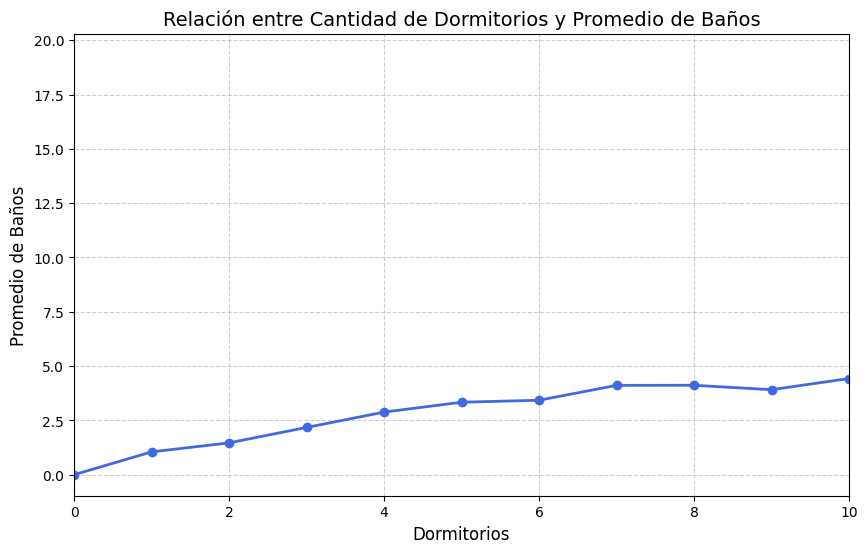

In [ ]:
# 1. Agrupamos por dormitorios y calculamos el promedio de baños
# Usamos df_ent (podés cambiarlo por df_ap si preferís)
df_linea = df_ent.groupby('dormitorios')['banos'].mean().reset_index()

# 2. Creamos el gráfico
plt.figure(figsize=(10, 6))
plt.plot(df_linea['dormitorios'], df_linea['banos'], marker='o', linestyle='-', color='royalblue', linewidth=2)

# Personalización
plt.title('Relación entre Cantidad de Dormitorios y Promedio de Baños', fontsize=14)
plt.xlabel('Dormitorios', fontsize=12)
plt.ylabel('Promedio de Baños', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Limitamos el eje X a un rango lógico (ej: hasta 10) para evitar que outliers arruinen la visual
plt.xlim(0, 10)

plt.show()

In [ ]:
# 1. Calculamos la mediana de baños según la cantidad de dormitorios
# transform('median') genera una serie del mismo tamaño que el DF original
medianas = df_ent.groupby('dormitorios')['banos'].transform('median')

# 2. Imputamos los valores faltantes en la columna 'banos'
df_ent['banos'] = df_ent['banos'].fillna(medianas)

# 3. Verificamos si aún quedan nulos
# (Podrían quedar si 'dormitorios' también es nulo en algunas filas)
print(f"Nulos restantes en baños: {df_ent['banos'].isnull().sum()}")

Nulos restantes en baños: 3


In [ ]:
df_ent = df_ent[df_ent['banos'].notna()]

In [ ]:
# 1. Calculamos la mediana de dormitorios agrupando por la cantidad de baños
# Usamos transform para obtener una serie alineada con el DataFrame original
medianas_dorm = df_ent.groupby('banos')['dormitorios'].transform('median')

# 2. Llenamos los nulos de la columna 'dormitorios'
df_ent['dormitorios'] = df_ent['dormitorios'].fillna(medianas_dorm)

# 3. Verificación de nulos persistentes
print(f"Nulos restantes en dormitorios: {df_ent['dormitorios'].isnull().sum()}")

Nulos restantes en dormitorios: 0


In [ ]:
# 1. Calculamos la mediana de m2 según la cantidad de dormitorios
# Solo funcionará para filas donde dormitorios NO sea null
medianas_m2 = df_ent.groupby('dormitorios')['m2'].transform('median')

# 2. Llenamos los nulos de 'm2' con esas medianas
df_ent['m2'] = df_ent['m2'].fillna(medianas_m2)

# 3. Verificación de resultados
nulos_finales = df_ent['m2'].isnull().sum()
print(f"Nulos restantes en m2: {nulos_finales}")

Nulos restantes en m2: 0


In [ ]:
#df_ent[df_ent['banos'].isnull()]

In [ ]:
# Imputación de Valores Faltantes mediante la técnica de la mediana
#for c in ["dormitorios", "banos","m2"]:
#    mediana = df_ent[c].median()
#    print(f"La mediana de {c} es: {mediana}")

In [ ]:
df_ent["lat"].isna().sum()

np.int64(34)

In [ ]:
df_ent["lon"].isna().sum()

np.int64(34)

In [ ]:
df_ent = df_ent.dropna(subset=["lon"])
df_ent = df_ent.dropna(subset=["lat"])

In [ ]:
df_ap["lat"].isna().sum()

np.int64(0)

In [ ]:
df_ap["lon"].isna().sum()

np.int64(0)

In [ ]:
# Imputación de valores faltantes con la mediana
columnas = ["m2", "dormitorios", "banos"]

for c in columnas:
    mediana = df_ent[c].median()
    df_ent[c] = df_ent[c].fillna(mediana)
    df_ap[c] = df_ap[c].fillna(mediana)

df_ent.loc[df_ent["m2"] <= 0, "m2"] = df_ent["m2"].median()
df_ap.loc[df_ap["m2"] <= 0, "m2"] = df_ent["m2"].median()

In [ ]:
# Aplico Frequency Encoding o Codificación por Frecuencia
# Es una forma de transformar variables categóricas en números, basándose en qué tan comunes son

freq_cols = ["source", "property_type", "location_2", "location_3", "publisher_id"]
#freq_cols = ["source", "property_type", "location_1", "location_2", "location_3"]
# quise sacar publisher_id pero me empeoraba
for c in freq_cols:
    freq_map = df_ent[c].fillna("desconocido").astype(str).value_counts(normalize=True) #tratalo como si perteneciera a una categoría llamada 'desconocido'"
    df_ent[c + "_freq"] = df_ent[c].fillna("desconocido").astype(str).map(freq_map)
    df_ap[c + "_freq"] = df_ap[c].fillna("desconocido").astype(str).map(freq_map).fillna(0)

In [ ]:
df_ent["location_3"].unique()

array(['Parque Patricios', 'Ciudad Autónoma de Buenos Aires', 'Belgrano',
       'Belgrano R', 'Belgrano C', 'Congreso', 'Constitucion',
       'Belgrano Chico', 'Barrio Chino', 'Villa Pueyrredon', 'Nuñez',
       'Las Cañitas', 'Recoleta', 'Palermo', 'Botánico', 'Centro',
       'Villa Urquiza', 'Palermo Hollywood', 'Coghlan', 'Primera Junta',
       'Colegiales', 'Barrio Norte', 'Villa Crespo', 'Barrio Parque',
       'Puerto Madero', 'Monserrat', 'San Nicolás', 'Retiro',
       'Tribunales', 'Mataderos', 'Balvanera', 'San Telmo',
       'Palermo Soho', 'Catalinas', 'San Cristobal', 'Barracas',
       'Parque Chacabuco', 'Abasto', 'Boca', 'Parque Centenario',
       'Parque Rivadavia', 'Saavedra', 'Flores', 'Almagro', 'Chacarita',
       'Villa Lugano', 'Monte Castro', 'Liniers', 'Velez Sarsfield',
       'Palermo Chico', 'Caballito', 'Palermo Viejo', 'Villa del Parque',
       'Caballito Norte', 'Caballito Sur', 'Cid Campeador', 'Villa Luro',
       'Paternal', 'Villa General Mitre'

In [ ]:
# es de distrito quartier y tenia mal los m2
#df_ent.loc[431738, "m2"] = 48
#df_ent.loc[653925, "m2"] = 51
#df_ent.loc[431739, "m2"] = 47
# es de concepcion y tenia mal los m2
#df_ent.loc[377375, "m2"] = 81
#df_ent.loc[387151, "m2"] = 103
#df_ent.loc[431840, "m2"] = 70
# puerto madero
df_ent.loc[964582, "m2"] = 196
df_ent.loc[837616, "m2"] = 139
# flores
df_ent.loc[124019, "m2"] = 140
df_ent.loc[265568, "m2"] = 170
df_ent.loc[265568, "location_3"] = "Flores"
# villa crespo
df_ent.loc[1015898, "m2"] = 62
# es de caballito y tenia mal los m2
df_ent.loc[695743, "m2"] = 53
df_ent.loc[695745, "m2"] = 44
df_ent.loc[695746, "m2"] = 85
df_ent.loc[123933, "m2"] = 200
df_ent.loc[808399, "m2"] = 145
df_ent.loc[732215, "m2"] = 42
df_ent.loc[969150, "m2"] = 45
df_ent.loc[1100643, "m2"] = 45
df_ent.loc[1079074, "m2"] = 60
df_ent.loc[695723, "m2"] = 82
df_ent.loc[108606, "m2"] = 91
df_ent.loc[107965, "m2"] = 88
df_ent.loc[108229, "m2"] = 180
df_ent.loc[108229, "location_3"] = "Caballito"
df_ent.loc[108606, "location_3"] = "Caballito"
df_ent.loc[107965, "location_3"] = "Caballito"
df_ent.loc[107156, "location_3"] = "Caballito"
df_ent.loc[106811, "location_3"] = "Caballito"
df_ent.loc[107953, "location_3"] = "Caballito"
df_ent.loc[107953, "m2"] = 88
df_ent.loc[106811, "m2"] = 156
df_ent.loc[107156, "m2"] = 156
df_ent.loc[123940, "m2"] = 65
# es de balvanera y tenia mal los m2
df_ent.loc[713884, "m2"] = 75
df_ent.loc[1227769, "m2"] = 46
df_ent.loc[1162636, "m2"] = 1134
df_ent.loc[965318, "m2"] = 52
df_ent.loc[114989, "price"] = 92000
# es de parque patricios y tenia mal los m2
df_ent.loc[948558, "m2"] = 92
# es de san nicolás y tenia mal los m2
df_ent.loc[1237489, "m2"] = 59
# es de villa lugano y tenia mal los m2
df_ent.loc[399597, "m2"] = 70
df_ent.loc[816326, "m2"] = 140
df_ent.loc[776473, "m2"] = 372
df_ent.loc[777634, "m2"] = 372
df_ent.loc[1038525, "m2"] = 372
df_ent.loc[1038535, "m2"] = 372
df_ent.loc[1062061, "m2"] = 216
df_ent.loc[266571, "m2"] = 216
df_ent.loc[399597, "m2"] = 70
# es de barracas y tenia mal los m2
df_ent.loc[695462, "m2"] = 44
# parque centenario
df_ent.loc[266893, "m2"] = 301
# monte castro
df_ent.loc[735481, "m2"] = 110
# liniers
df_ent.loc[464426, "m2"] = 48
df_ent.loc[754431, "m2"] = 190
# villa santa rita
df_ent.loc[1022696, "m2"] = 40
# centro
df_ent.loc[482907, "m2"] = 57
df_ent.loc[323313, "m2"] = 127
# villa devoto
df_ent.loc[696518, "m2"] = 72
df_ent.loc[696533, "m2"] = 72
df_ent.loc[696534, "m2"] = 122
df_ent.loc[266725, "m2"] = 226
df_ent.loc[695231, "m2"] = 342
df_ent.loc[266804, "m2"] = 749
df_ent.loc[810209, "m2"] = 205
df_ent.loc[747785, "m2"] = 52
df_ent.loc[266758, "m2"] = 562
df_ent.loc[266758, "m2"] = 128
df_ent.loc[380163, "m2"] = 100
df_ent.loc[768979, "m2"] = 100
df_ent.loc[945884, "m2"] = 100
df_ent.loc[266750, "m2"] = 368
df_ent.loc[266750, "location_3"] = "Villa Devoto"
# flores
df_ent.loc[965229, "m2"] = 187
df_ent.loc[965230, "m2"] = 187
df_ent.loc[265565, "m2"] = 209
df_ent.loc[265565, "location_3"] = "Flores"
df_ent.loc[122981, "location_3"] = "Caballito"
df_ent.loc[122981, "m2"] = 54
df_ent.loc[124246, "location_3"] = "Caballito"
df_ent.loc[124246, "m2"] = 94
# paternal
df_ent.loc[266214, "m2"] = 1460
# recoleta
df_ent.loc[1017911, "m2"] = 182
df_ent.loc[718808, "m2"] = 220
df_ent.loc[105984, "m2"] = 300
df_ent.loc[105780, "m2"] = 130
df_ent.loc[1007965, "m2"] = 154
df_ent.loc[1229184, "m2"] = 177
df_ent.loc[101856, "m2"] = 168
df_ent.loc[106346, "m2"] = 75
df_ent.loc[714741, "m2"] = 65
df_ent.loc[1103515, "m2"] = 122
df_ent.loc[103670, "m2"] = 48
df_ent.loc[103670, "location_3"] = "Recoleta"
df_ent.loc[104197, "m2"] = 230
df_ent.loc[106414, "m2"] = 119
df_ent.loc[842636, "m2"] = 67
df_ent.loc[939054, "m2"] = 293
df_ent.loc[948300, "m2"] = 161
df_ent.loc[973535, "m2"] = 459
df_ent.loc[973704, "m2"] = 231
df_ent.loc[977982, "m2"] = 195
df_ent.loc[1062753, "m2"] = 317
df_ent.loc[105503, "m2"] = 310
df_ent.loc[105757, "m2"] = 91
df_ent.loc[424865, "m2"] = 44.7
df_ent.loc[425974, "m2"] = 122
df_ent.loc[104687, "m2"] = 307
df_ent.loc[104710, "m2"] = 86
df_ent.loc[104732, "m2"] = 110
df_ent.loc[104833, "m2"] = 61
df_ent.loc[104933, "m2"] = 150
df_ent.loc[105073, "m2"] = 96
df_ent.loc[105486, "m2"] = 107
df_ent.loc[105911, "m2"] = 40
df_ent.loc[106731, "m2"] = 159
df_ent.loc[309772, "m2"] = 97
df_ent.loc[712236, "m2"] = 102
df_ent.loc[809997, "m2"] = 245
df_ent.loc[842636, "m2"] = 90
df_ent.loc[940785, "m2"] = 136
df_ent.loc[959629, "m2"] = 100
# constitucion
df_ent.loc[267225, "m2"] = 1240
df_ent.loc[120451, "m2"] = 203
df_ent.loc[265978, "m2"] = 110
df_ent.loc[124244, "m2"] = 120
df_ent.loc[103693, "m2"] = 80
df_ent.loc[100098, "m2"] = 60
df_ent.loc[103674, "m2"] = 378
df_ent.loc[103674, "location_3"] = "Recoleta"
df_ent.loc[120451, "location_3"] = "Recoleta"
df_ent.loc[103705, "location_3"] = "Recoleta"
df_ent.loc[103990, "location_3"] = "Recoleta"
df_ent.loc[103990, "m2"] = 185
df_ent.loc[103705, "m2"] = 236
df_ent.loc[107944, "m2"] = 112
df_ent.loc[267569, "m2"] = 170
df_ent.loc[107944, "location_3"] = "Caballito"
df_ent.loc[107962, "location_3"] = "Caballito"
df_ent.loc[107964, "location_3"] = "Caballito"
df_ent.loc[108614, "location_3"] = "Caballito"
df_ent.loc[109405, "location_3"] = "Caballito"
df_ent.loc[99183, "location_3"] = "Belgrano R"
df_ent.loc[99183, "m2"] = 112
df_ent.loc[267350, "m2"] = 210
df_ent.loc[323984, "m2"] = 60
df_ent.loc[109405, "m2"] = 170
df_ent.loc[108614, "m2"] = 215
df_ent.loc[107964, "m2"] = 112
df_ent.loc[107962, "m2"] = 112
df_ent.loc[115797, "m2"] = 101
#ciudad autónoma de buenos aires
df_ent.loc[266371, "m2"] = 11070
df_ent.loc[312412, "m2"] = 204
df_ent.loc[105837, "m2"] = 122
# almagro
df_ent.loc[267957, "m2"] = 1900
# parque rivadavia
df_ent.loc[107144, "m2"] = 100
# coghlan
df_ent.loc[695820, "m2"] = 91
df_ent.loc[936562, "m2"] = 170
# belgrano
df_ent.loc[1104253, "m2"] = 63.12
df_ent.loc[1071154, "m2"] = 65
df_ent.loc[267938, "m2"] = 210
# parque chacabuco
df_ent.loc[1038504, "m2"] = 172
# boedo
df_ent.loc[713609, "m2"] = 60
# barrio norte
df_ent.loc[1021252, "m2"] = 170
df_ent.loc[990085, "m2"] = 140
df_ent.loc[762920, "m2"] = 178
df_ent.loc[766411, "m2"] = 178
df_ent.loc[103730, "m2"] = 50
df_ent.loc[103731, "m2"] = 50
df_ent.loc[103732, "m2"] = 50
df_ent.loc[103733, "m2"] = 50
df_ent.loc[103734, "m2"] = 50
df_ent.loc[103735, "m2"] = 50
df_ent.loc[103736, "m2"] = 50
df_ent.loc[103737, "m2"] = 50
df_ent.loc[103738, "m2"] = 50
df_ent.loc[103739, "m2"] = 50
df_ent.loc[103740, "m2"] = 50
df_ent.loc[103741, "m2"] = 50
df_ent.loc[103743, "m2"] = 50
df_ent.loc[103744, "m2"] = 50
df_ent.loc[103745, "m2"] = 50
df_ent.loc[103746, "m2"] = 50
df_ent.loc[103747, "m2"] = 50
df_ent.loc[103748, "m2"] = 50
df_ent.loc[103749, "m2"] = 50
df_ent.loc[103750, "m2"] = 50
df_ent.loc[103751, "m2"] = 50
df_ent.loc[103752, "m2"] = 50
df_ent.loc[103753, "m2"] = 50
df_ent.loc[103754, "m2"] = 50
df_ent.loc[103755, "m2"] = 50
df_ent.loc[103756, "m2"] = 50
df_ent.loc[103757, "m2"] = 50
df_ent.loc[103758, "m2"] = 50
df_ent.loc[104814, "m2"] = 50
df_ent.loc[104815, "m2"] = 50
df_ent.loc[104816, "m2"] = 50
df_ent.loc[104817, "m2"] = 50
df_ent.loc[104818, "m2"] = 50
df_ent.loc[104819, "m2"] = 50
df_ent.loc[104820, "m2"] = 50
df_ent.loc[103796, "m2"] = 50
df_ent.loc[105641, "m2"] = 50
df_ent.loc[105642, "m2"] = 50
df_ent.loc[105643, "m2"] = 50
df_ent.loc[105644, "m2"] = 50
df_ent.loc[105645, "m2"] = 50
df_ent.loc[105646, "m2"] = 50
df_ent.loc[105647, "m2"] = 50
df_ent.loc[105648, "m2"] = 50
df_ent.loc[104684, "m2"] = 165
df_ent.loc[990085, "m2"] = 105
df_ent.loc[1160361, "m2"] = 620
df_ent.loc[1160361, "dormitorios"] = 5
df_ent.loc[1160361, "banos"] = 6
df_ent.loc[1160360, "m2"] = 300
df_ent.loc[1160360, "dormitorios"] = 3
df_ent.loc[1160360, "banos"] = 3
# villa urquiza
df_ent.loc[709724, "m2"] = 35
df_ent.loc[121479, "m2"] = 40
df_ent.loc[121480, "m2"] = 40
df_ent.loc[122073, "m2"] = 40
df_ent.loc[122829, "m2"] = 40
df_ent.loc[1056293, "m2"] = 286
# palermo chico
df_ent.loc[1160968, "m2"] = 600
df_ent.loc[1256130, "m2"] = 600
df_ent.loc[1160968, "dormitorios"] = 5
df_ent.loc[1160968, "banos"] = 6
df_ent.loc[324729, "m2"] = 434
df_ent.loc[819618, "m2"] = 165
df_ent.loc[324547, "m2"] = 140
df_ent.loc[324548, "m2"] = 140
df_ent.loc[990081, "m2"] = 140
df_ent.loc[324983, "m2"] = 142
df_ent.loc[990083, "m2"] = 140
df_ent.loc[990083, "address"] = "Av. del Libertador 2400"
# palermo hollywood
df_ent.loc[321697, "m2"] = 288
df_ent.loc[111792, "m2"] = 96
df_ent.loc[110596, "m2"] = 96
df_ent.loc[110595, "m2"] = 96
df_ent.loc[110416, "m2"] = 78
df_ent.loc[321695, "m2"] = 107
df_ent.loc[110416, "location_3"] = "Palermo Hollywood"
# palermo
df_ent.loc[831430, "m2"] = 40
df_ent.loc[990084, "m2"] = 140
df_ent.loc[1002931, "m2"] = 40
df_ent.loc[1159828, "m2"] = 60
df_ent.loc[1193780, "m2"] = 400
df_ent.loc[979497, "dormitorios"] = 3
df_ent.loc[979497, "m2"] = 205
df_ent.loc[995095, "m2"] = 50.50
df_ent.loc[117193, "location_3"] = "Almagro"
df_ent.loc[1003794, "m2"] = 309
df_ent.loc[1003795, "m2"] = 309
df_ent.loc[122981, "m2"] = 40
df_ent.loc[970805, "m2"] = 220
df_ent.loc[768194, "m2"] = 200
df_ent.loc[808656, "m2"] = 292
df_ent.loc[973181, "m2"] = 92
df_ent.loc[266749, "m2"] = 130
df_ent.loc[814304, "m2"] = 410
df_ent.loc[779873, "m2"] = 240
df_ent.loc[96121, "m2"] = 200
df_ent.loc[324181, "m2"] = 90
df_ent.loc[716649, "m2"] = 255
df_ent.loc[1160966, "m2"] = 338
df_ent.loc[1073512, "m2"] = 142
df_ent.loc[779874, "m2"] = 240
df_ent.loc[780098, "m2"] = 240
df_ent.loc[1160969, "m2"] = 323
df_ent.loc[999356, "m2"] = 102
df_ent.loc[981291, "m2"] = 63
df_ent.loc[1174254, "m2"] = 180
# belgrano
df_ent.loc[1159233, "m2"] = 255
df_ent.loc[954365, "m2"] = 205
df_ent.loc[97635, "m2"] = 190
df_ent.loc[1012948, "m2"] = 200
df_ent.loc[268110, "m2"] = 298
df_ent.loc[96526, "m2"] = 198
df_ent.loc[96526, "location_3"] = "Belgrano"
df_ent.loc[718876, "m2"] = 203
df_ent.loc[768199, "m2"] = 170
df_ent.loc[809020, "m2"] = 170
df_ent.loc[809123, "m2"] = 170
df_ent.loc[809119, "m2"] = 170
df_ent.loc[809118, "m2"] = 170
df_ent.loc[809022, "m2"] = 170
df_ent.loc[786656, "m2"] = 170
df_ent.loc[809018, "m2"] = 148
df_ent.loc[809017, "m2"] = 148
df_ent.loc[809117, "m2"] = 149
df_ent.loc[768201, "m2"] = 111
df_ent.loc[809125, "m2"] = 97
df_ent.loc[96549, "m2"] = 247
df_ent.loc[469122, "m2"] = 300
df_ent.loc[1013170, "m2"] = 300
df_ent.loc[1013178, "m2"] = 300
df_ent.loc[1013617, "m2"] = 363
df_ent.loc[1013176, "m2"] = 217
df_ent.loc[937977, "m2"] = 450
df_ent.loc[951225, "m2"] = 450
df_ent.loc[937978, "m2"] = 450
df_ent.loc[1017468, "m2"] = 450
df_ent.loc[1017469, "m2"] = 450
df_ent.loc[955599, "m2"] = 76
df_ent.loc[99241, "m2"] = 76
df_ent.loc[99241, "location_3"] = "Belgrano"
df_ent.loc[97635, "m2"] = 300
df_ent.loc[97659, "m2"] = 105
df_ent.loc[701215, "m2"] =203
df_ent.loc[701467, "m2"] =143
df_ent.loc[701566, "m2"] =180
df_ent.loc[701567, "m2"] =176
df_ent.loc[711563, "m2"] =483
df_ent.loc[715798, "m2"] =163
df_ent.loc[781462, "m2"] =241
df_ent.loc[951551, "m2"] =177
# puerto madero
df_ent.loc[1239174, "m2"] = 132
df_ent.loc[727361, "m2"] = 435
df_ent.loc[940587, "m2"] = 50
df_ent.loc[696203, "m2"] = 38
# nuñez
df_ent.loc[113220, "m2"] = 85
df_ent.loc[1222254, "m2"] = 45
df_ent.loc[378784, "m2"] = 40
df_ent.loc[696131, "m2"] = 161
df_ent.loc[98672, "m2"] = 116
df_ent.loc[1023568, "m2"] = 48
df_ent.loc[1012327, "m2"] = 250
df_ent.loc[1012327, "location_3"] = "Nuñez"
df_ent.loc[704803, "m2"] = 366
df_ent.loc[759367, "m2"] = 133
df_ent.loc[809727, "m2"] = 246
df_ent.loc[945156, "m2"] = 360
df_ent.loc[946330, "m2"] = 360
# almagro
df_ent.loc[716254, "m2"] = 55
df_ent.loc[475526, "m2"] = 40
df_ent.loc[848247, "m2"] = 70
df_ent.loc[826739, "m2"] = 146
# agronomia
df_ent.loc[1202564, "m2"] = 35
# floresta
df_ent.loc[1189609, "m2"] = 492
df_ent.loc[1189608, "m2"] = 375
df_ent.loc[755566, "m2"] = 320
# constitucion
df_ent.loc[109040, "m2"] = 108
df_ent.loc[419861, "m2"] = 67
df_ent.loc[735986, "m2"] = 67
df_ent.loc[125566, "m2"] = 168
df_ent.loc[323244, "m2"] = 120
df_ent.loc[100150, "m2"] = 130
df_ent.loc[100159, "m2"] = 130
df_ent.loc[113291, "m2"] = 48
df_ent.loc[827709, "m2"] = 425
df_ent.loc[125545, "m2"] = 421
# colegiales
df_ent.loc[847258, "m2"] = 80
df_ent.loc[125691, "m2"] = 421
df_ent.loc[125235, "m2"] = 421
df_ent.loc[125514, "m2"] = 421
df_ent.loc[125540, "m2"] = 421
df_ent.loc[125543, "m2"] = 421
df_ent.loc[704050, "m2"] = 48
df_ent.loc[778870, "m2"] = 48
df_ent.loc[125690, "m2"] = 269
df_ent.loc[125544, "m2"] = 269
df_ent.loc[124938, "m2"] = 345
df_ent.loc[125407, "m2"] = 135
# san telmo
df_ent.loc[1225885, "m2"] = 67
# villa soldati
df_ent.loc[266472, "m2"] = 451
# villa luro
df_ent.loc[1234815, "m2"] = 53
df_ent.loc[737954, "m2"] = 120
df_ent.loc[787449, "m2"] = 120
df_ent.loc[995973, "m2"] = 120
df_ent.loc[1239561, "m2"] = 150
df_ent.loc[736396, "m2"] = 250
df_ent.loc[1032417, "m2"] = 485
df_ent.loc[1032417, "dormitorios"] = 3
df_ent.loc[1032417, "banos"] = 2
# villa del parque
df_ent.loc[721542, "m2"] = 200
# retiro
df_ent.loc[943156, "m2"] = 221
df_ent.loc[944327, "m2"] = 200
df_ent.loc[944327, "location_3"] = "Palermo Chico"
df_ent.loc[936833, "m2"] = 105
df_ent.loc[956957, "m2"] = 180
df_ent.loc[104011, "location_3"] = "Palermo"
# villa ortuzar
df_ent.loc[696631, "m2"] = 173
df_ent.loc[111273, "m2"] = 74
# villa devoto
df_ent.loc[696487, "m2"] = 285
df_ent.loc[696524, "m2"] = 126
df_ent.loc[803526, "m2"] = 700
df_ent.loc[1071765, "m2"] = 100
df_ent.loc[964804, "m2"] = 81
# parque centenario
df_ent.loc[266869, "m2"] = 200
df_ent.loc[109316, "m2"] = 67
# villa crespo
df_ent.loc[111600, "m2"] = 49
# mataderos
df_ent.loc[795968, "m2"] = 125
df_ent.loc[1107385, "m2"] = 125
df_ent.loc[807860, "m2"] = 288
df_ent.loc[795961, "m2"] = 92
df_ent.loc[1107380, "m2"] = 92
df_ent.loc[947903, "m2"] = 48
# flores
df_ent.loc[791807, "m2"] = 50
df_ent.loc[1019109, "m2"] = 180
df_ent.loc[1167386, "m2"] = 130
df_ent.loc[1082356, "m2"] = 87
df_ent.loc[124327, "m2"] = 55
df_ent.loc[123040, "m2"] = 180
df_ent.loc[123911, "m2"] = 87
df_ent.loc[124451, "m2"] = 162
df_ent.loc[124579, "m2"] = 180
df_ent.loc[124580, "m2"] = 200
df_ent.loc[124584, "m2"] = 84
df_ent.loc[124630, "m2"] = 122
df_ent.loc[124645, "m2"] = 122
df_ent.loc[265571, "m2"] = 300
df_ent.loc[265695, "m2"] = 220
# monte castro
df_ent.loc[696032, "m2"] = 59
df_ent.loc[695198, "m2"] = 250
# san cristobal
df_ent.loc[1008685, "m2"] = 64
df_ent.loc[1095341, "m2"] = 55
df_ent.loc[1008594, "m2"] = 50
df_ent.loc[843354, "m2"] = 125
df_ent.loc[840844, "m2"] = 52
df_ent.loc[1099439, "m2"] = 58
df_ent.loc[118962, "m2"] = 37
df_ent.loc[109193, "m2"] = 128
df_ent.loc[108821, "m2"] = 63
df_ent.loc[109147, "m2"] = 156
df_ent.loc[700842, "m2"] = 72
df_ent.loc[719021, "m2"] = 120
df_ent.loc[793270, "m2"] = 80
df_ent.loc[828819, "m2"] = 60
df_ent.loc[947956, "m2"] = 44
df_ent.loc[971360, "m2"] = 74
df_ent.loc[1100643, "m2"] = 74
# mitre
df_ent.loc[1180245, "m2"] = 200
# barrancas
df_ent.loc[733691, "m2"] = 265
# palermo chico
df_ent.loc[324549, "m2"] = 173
df_ent.loc[1073716, "m2"] = 360
df_ent.loc[324340, "m2"] = 300
# villa devoto
df_ent.loc[266683, "m2"] = 290
df_ent.loc[266704, "m2"] = 272
df_ent.loc[376655, "m2"] = 166
df_ent.loc[945367, "m2"] = 94
df_ent.loc[1050870, "m2"] = 150
df_ent.loc[1063240, "m2"] = 176
df_ent.loc[380163, "m2"] = 215
df_ent.loc[698326, "m2"] = 241
df_ent.loc[701540, "m2"] = 241
df_ent.loc[705927, "m2"] = 243
df_ent.loc[709667, "m2"] = 241
df_ent.loc[841740, "m2"] = 241
df_ent.loc[1226795, "m2"] = 241
df_ent.loc[1184735, "m2"] = 250
df_ent.loc[1229497, "m2"] = 215
df_ent.loc[1241818, "m2"] = 168
df_ent.loc[945888, "m2"] = 166
df_ent.loc[763211, "m2"] = 128
df_ent.loc[997248, "m2"] = 141
df_ent.loc[266644, "m2"] = 276
df_ent.loc[266828, "m2"] = 270
df_ent.loc[266828, "dormitorios"] = 4
df_ent.loc[266828, "banos"] = 2
# nuñez
df_ent.loc[947903, "m2"] = 48
# naon
df_ent.loc[815268, "m2"] = 150
df_ent.loc[945645, "m2"] = 150
df_ent.loc[1107384, "m2"] = 99.5
df_ent.loc[795967, "m2"] = 99.5
df_ent.loc[763258, "m2"] = 50
# abasto
df_ent.loc[753119, "m2"] = 61
df_ent.loc[753122, "m2"] = 61
df_ent.loc[842699, "m2"] = 72
# almagro
df_ent.loc[118272, "m2"] = 171
df_ent.loc[118721, "m2"] = 50
df_ent.loc[117482, "location_3"] = "Caballito"
# balvanera
df_ent.loc[115707, "m2"] = 126
df_ent.loc[801776, "m2"] = 110
df_ent.loc[116244, "m2"] = 92
df_ent.loc[116244, "banos"] = 2
# colegiales
df_ent.loc[124700, "m2"] = 86
df_ent.loc[125268, "m2"] = 147
df_ent.loc[125268, "dormitorios"] = 3
# villa pueyrredon
df_ent.loc[954140, "m2"] = 52
# palermo
df_ent.loc[265898, "m2"] = 300
# monserrat
df_ent.loc[100897, "m2"] = 76
df_ent.loc[101934, "m2"] = 56
df_ent.loc[312312, "m2"] = 221
# liniers
df_ent.loc[267283, "m2"] = 370
df_ent.loc[267328, "m2"] = 178
# saavedra
df_ent.loc[943594, "m2"] = 310
df_ent.loc[943595, "m2"] = 246
df_ent.loc[943596, "m2"] = 384
df_ent.loc[943598, "m2"] = 337
df_ent.loc[943668, "m2"] = 370
df_ent.loc[943669, "m2"] = 350
df_ent.loc[943674, "m2"] = 315
df_ent.loc[943679, "m2"] = 432
df_ent.loc[982592, "m2"] = 231
df_ent.loc[1176769, "m2"] = 153
# caballito
df_ent.loc[1163080, "m2"] = 194
df_ent.loc[1081682, "m2"] = 59
df_ent.loc[1074553, "m2"] = 54
df_ent.loc[715341, "m2"] = 40
df_ent.loc[107172, "m2"] = 377
df_ent.loc[107206, "m2"] = 311
df_ent.loc[107279, "m2"] = 104
df_ent.loc[107302, "m2"] = 85
df_ent.loc[107333, "m2"] = 132
df_ent.loc[107338, "m2"] = 54
df_ent.loc[107708, "m2"] = 168
df_ent.loc[107938, "m2"] = 74
df_ent.loc[107972, "m2"] = 257
df_ent.loc[107973, "m2"] = 74
df_ent.loc[107974, "m2"] = 185
df_ent.loc[108289, "m2"] = 135
df_ent.loc[108600, "m2"] = 132
df_ent.loc[108630, "m2"] = 175
df_ent.loc[108700, "m2"] = 281
df_ent.loc[108744, "m2"] = 140
df_ent.loc[109019, "m2"] = 110
df_ent.loc[107147, "m2"] = 204
df_ent.loc[109024, "m2"] = 107
df_ent.loc[109396, "m2"] = 60
df_ent.loc[109398, "m2"] = 154
df_ent.loc[109400, "m2"] = 60
df_ent.loc[109465, "m2"] = 100
df_ent.loc[109470, "m2"] = 60
df_ent.loc[266849, "m2"] = 250
df_ent.loc[309811, "m2"] = 181
df_ent.loc[266960, "m2"] = 200
df_ent.loc[695179, "m2"] = 253
df_ent.loc[1038427, "m2"] = 350
df_ent.loc[1038427, "location_3"] = "Barrio Norte"
# palermo
df_ent.loc[323037, "m2"] = 89
df_ent.loc[324181, "m2"] = 198
df_ent.loc[773433, "m2"] = 151
df_ent.loc[774253, "m2"] = 222
df_ent.loc[833959, "m2"] = 232
df_ent.loc[938070, "m2"] = 200
df_ent.loc[975952, "m2"] = 87
df_ent.loc[987636, "m2"] = 54
df_ent.loc[987640, "m2"] = 45
df_ent.loc[987648, "m2"] = 45
df_ent.loc[987833, "m2"] = 232
df_ent.loc[1012713, "m2"] = 212
df_ent.loc[1239048, "m2"] = 93
df_ent.loc[817693, "m2"] = 354
df_ent.loc[322412, "m2"] = 91
df_ent.loc[740417, "m2"] = 100
df_ent.loc[808562, "m2"] = 82
df_ent.loc[808682, "m2"] = 148
df_ent.loc[948573, "m2"] = 101
df_ent.loc[948573, "location_3"] = "Palermo Nuevo"
df_ent.loc[949409, "m2"] = 344
df_ent.loc[955350, "m2"] = 250
df_ent.loc[963427, "m2"] = 60
df_ent.loc[958296, "m2"] = 222
df_ent.loc[958296, "banos"] = 2
df_ent.loc[981254, "m2"] = 103
df_ent.loc[987651, "m2"] = 56
df_ent.loc[987714, "m2"] = 56
df_ent.loc[989631, "m2"] = 307
df_ent.loc[989639, "m2"] = 307
df_ent.loc[989551, "m2"] = 307
df_ent.loc[989637, "m2"] = 222
df_ent.loc[323474, "m2"] = 51
df_ent.loc[323260, "m2"] = 51
df_ent.loc[322847, "m2"] = 43
df_ent.loc[982732, "m2"] = 230
df_ent.loc[1214653, "m2"] = 71
df_ent.loc[808652, "m2"] = 89
df_ent.loc[708253, "m2"] = 104
df_ent.loc[759368, "m2"] = 411
df_ent.loc[759369, "m2"] = 411
# villa urquiza
df_ent.loc[121123, "m2"] = 57
df_ent.loc[121131, "dormitorios"] = 2
df_ent.loc[121131, "banos"] = 2
df_ent.loc[121131, "m2"] = 108
df_ent.loc[121584, "dormitorios"] = 2
df_ent.loc[121584, "m2"] = 94
df_ent.loc[122008, "m2"] = 157
df_ent.loc[122016, "m2"] = 140
df_ent.loc[122106, "m2"] = 50
df_ent.loc[122484, "m2"] = 47
df_ent.loc[122491, "m2"] = 148
df_ent.loc[267574, "m2"] = 90
df_ent.loc[742267, "m2"] = 131
df_ent.loc[977470, "m2"] = 84
df_ent.loc[121775, "location_3"] = "Nuñez"
# nuñez
df_ent.loc[113288, "m2"] = 114
df_ent.loc[113363, "m2"] = 128
df_ent.loc[114092, "m2"] = 174
df_ent.loc[114095, "m2"] = 170
df_ent.loc[114123, "m2"] = 187
df_ent.loc[764160, "m2"] = 49
df_ent.loc[943751, "m2"] = 150
df_ent.loc[1067810, "m2"] = 61
# otros
df_ent.loc[265304, "m2"] = 203
df_ent.loc[265753, "m2"] = 322
df_ent.loc[266178, "m2"] = 279
df_ent.loc[695974, "m2"] = 131
df_ent.loc[837520, "m2"] = 122
# colegiales
df_ent.loc[1238429, "m2"] = 36
# palermo hollywood
df_ent.loc[321890, "m2"] = 75
# boca
df_ent.loc[113722, "location_3"] = "Nuñez"
df_ent.loc[837141, "m2"] = 33
df_ent.loc[837154, "m2"] = 39
df_ent.loc[791887, "m2"] = 39
# pompeya
df_ent.loc[267654, "m2"] = 500
df_ent.loc[267712, "m2"] = 229
df_ent.loc[267721, "m2"] = 348
df_ent.loc[754517, "m2"] = 93
df_ent.loc[1026513, "m2"] = 442
df_ent.loc[952303, "m2"] = 55
df_ent.loc[952305, "m2"] = 50
df_ent.loc[1073756, "m2"] = 45
# retiro
df_ent.loc[99953, "m2"] = 231
df_ent.loc[100000, "m2"] = 233
df_ent.loc[100477, "m2"] = 116
df_ent.loc[100885, "m2"] = 196
df_ent.loc[819632, "m2"] = 180
df_ent.loc[103204, "m2"] = 89
df_ent.loc[420649, "m2"] = 627
df_ent.loc[701485, "m2"] = 255
df_ent.loc[801675, "m2"] = 201
df_ent.loc[814287, "m2"] = 256
df_ent.loc[1079643, "m2"] = 50
df_ent.loc[1239997, "m2"] = 234
df_ent.loc[420649, "location_3"] = "Recoleta"
df_ent.loc[814287, "location_3"] = "Recoleta"

In [ ]:
# cambio de constitucion todos estos
df_ent.loc[971114, "m2"] = 164
df_ent.loc[971114, "location_3"] = "Las Cañitas"
df_ent.loc[1016525, "location_3"] = "Las Cañitas"

df_ent.loc[999358, "m2"] = 72
df_ent.loc[999358, "location_3"] = "Las Cañitas"

df_ent.loc[110793, "location_3"] = "Palermo Hollywood"
df_ent.loc[110793, "m2"] = 90

df_ent.loc[101102, "m2"] = 49
df_ent.loc[101102, "location_3"] = "Palermo"

df_ent.loc[100506, "m2"] = 197
df_ent.loc[100506, "location_3"] = "Recoleta"

df_ent.loc[99951, "m2"] = 133
df_ent.loc[99951, "location_3"] = "Recoleta"

df_ent.loc[106049, "m2"] = 283
df_ent.loc[106049, "location_3"] = "Recoleta"

df_ent.loc[104131, "m2"] = 100
df_ent.loc[104131, "location_3"] = "Recoleta"

df_ent.loc[107947, "m2"] = 228
df_ent.loc[107947, "location_3"] = "Caballito"

df_ent.loc[109836, "m2"] = 290
df_ent.loc[109836, "location_3"] = "Colegiales"

df_ent.loc[113364, "m2"] = 162
df_ent.loc[113364, "location_3"] = "Nuñez"

df_ent.loc[114782, "m2"] = 114
df_ent.loc[114782, "location_3"] = "Nuñez"

df_ent.loc[119904, "m2"] = 92
df_ent.loc[119904, "location_3"] = "Villa Crespo"

df_ent.loc[125230, "m2"] = 213
df_ent.loc[125230, "location_3"] = "Colegiales"

df_ent.loc[125234, "m2"] = 156
df_ent.loc[125234, "location_3"] = "Colegiales"

df_ent.loc[125250, "m2"] = 215
df_ent.loc[125250, "location_3"] = "Colegiales"

df_ent.loc[267227, "m2"] = 335
df_ent.loc[267227, "location_3"] = "Liniers"

df_ent.loc[322899, "m2"] = 113
df_ent.loc[322899, "location_3"] = "Palermo"

df_ent.loc[324569, "m2"] = 112
df_ent.loc[324569, "location_3"] = "Palermo Chico"

df_ent.loc[97751, "m2"] = 60
df_ent.loc[97751, "location_3"] = "Belgrano"

df_ent.loc[99171, "m2"] = 306
df_ent.loc[99171, "location_3"] = "Belgrano"

df_ent.loc[103672, "m2"] = 310
df_ent.loc[103672, "location_3"] = "Recoleta"

df_ent.loc[106309, "m2"] = 501
df_ent.loc[106309, "location_3"] = "Recoleta"

df_ent.loc[106807, "m2"] = 190
df_ent.loc[106807, "location_3"] = "Caballito"

df_ent.loc[110654, "m2"] = 287
df_ent.loc[110654, "location_3"] = "Colegiales"

df_ent.loc[113365, "m2"] = 162
df_ent.loc[113365, "location_3"] = "Nuñez"

df_ent.loc[124711, "m2"] = 215
df_ent.loc[124711, "location_3"] = "Colegiales"

df_ent.loc[124928, "m2"] = 287
df_ent.loc[124928, "location_3"] = "Colegiales"

df_ent.loc[324338, "m2"] = 130
df_ent.loc[324338, "location_3"] = "Palermo"

df_ent.loc[96493, "m2"] = 166
df_ent.loc[96493, "location_3"] = "Belgrano R"

df_ent.loc[96495, "m2"] = 310
df_ent.loc[96495, "location_3"] = "Belgrano"

df_ent.loc[96496, "m2"] = 180
df_ent.loc[96496, "location_3"] = "Belgrano"

df_ent.loc[96512, "m2"] = 248
df_ent.loc[96512, "location_3"] = "Belgrano"

df_ent.loc[96530, "m2"] = 73
df_ent.loc[96530, "location_3"] = "Belgrano"

df_ent.loc[96585, "m2"] = 114
df_ent.loc[96585, "location_3"] = "Belgrano"

df_ent.loc[97625, "m2"] = 287
df_ent.loc[97625, "location_3"] = "Belgrano"

df_ent.loc[97641, "m2"] = 166
df_ent.loc[97641, "location_3"] = "Belgrano R"

df_ent.loc[97642, "m2"] = 143
df_ent.loc[97642, "location_3"] = "Belgrano"

df_ent.loc[97645, "m2"] = 166
df_ent.loc[97645, "location_3"] = "Belgrano R"

df_ent.loc[98615, "m2"] = 230
df_ent.loc[98615, "location_3"] = "Belgrano"

df_ent.loc[98618, "m2"] = 153
df_ent.loc[98618, "location_3"] = "Belgrano"

df_ent.loc[98718, "m2"] = 80
df_ent.loc[98718, "location_3"] = "Belgrano"

df_ent.loc[99486, "m2"] = 209
df_ent.loc[99486, "location_3"] = "Belgrano"

df_ent.loc[100983, "m2"] = 124
df_ent.loc[100983, "location_3"] = "Recoleta"

df_ent.loc[103689, "m2"] = 144
df_ent.loc[103689, "location_3"] = "Recoleta"

df_ent.loc[104606, "m2"] = 215
df_ent.loc[104606, "location_3"] = "Recoleta"

df_ent.loc[105469, "m2"] = 215
df_ent.loc[105469, "location_3"] = "Recoleta"

df_ent.loc[105508, "m2"] = 147
df_ent.loc[105508, "location_3"] = "Recoleta"

df_ent.loc[107133, "m2"] = 90
df_ent.loc[107133, "location_3"] = "Caballito"

df_ent.loc[98633, "m2"] = 135
df_ent.loc[98633, "location_3"] = "Nuñez"

df_ent.loc[107157, "m2"] = 160
df_ent.loc[107157, "location_3"] = "Caballito"

df_ent.loc[107165, "m2"] = 160
df_ent.loc[107165, "location_3"] = "Caballito"

df_ent.loc[107176, "m2"] = 184
df_ent.loc[107176, "location_3"] = "Caballito"

df_ent.loc[107332, "m2"] = 132
df_ent.loc[107332, "location_3"] = "Caballito"

df_ent.loc[107331, "m2"] = 186
df_ent.loc[107331, "location_3"] = "Caballito"

df_ent.loc[107954, "m2"] = 60
df_ent.loc[107954, "location_3"] = "Caballito"

df_ent.loc[107978, "m2"] = 185
df_ent.loc[107978, "location_3"] = "Caballito"

df_ent.loc[108631, "m2"] = 60
df_ent.loc[108631, "location_3"] = "Caballito"

df_ent.loc[108639, "m2"] = 156
df_ent.loc[108639, "location_3"] = "Caballito"

df_ent.loc[109029, "m2"] = 142
df_ent.loc[109029, "location_3"] = "Caballito"

df_ent.loc[109038, "m2"] = 156
df_ent.loc[109038, "location_3"] = "Caballito"

df_ent.loc[109268, "m2"] = 200
df_ent.loc[109268, "location_3"] = "Caballito"

df_ent.loc[109399, "m2"] = 138
df_ent.loc[109399, "location_3"] = "Caballito"

df_ent.loc[109835, "m2"] = 197
df_ent.loc[109835, "location_3"] = "Belgrano"

df_ent.loc[110668, "m2"] = 197
df_ent.loc[110668, "location_3"] = "Belgrano"

df_ent.loc[110669, "m2"] = 197
df_ent.loc[110669, "location_3"] = "Belgrano"

df_ent.loc[111365, "m2"] = 197
df_ent.loc[111365, "location_3"] = "Belgrano"

df_ent.loc[113284, "m2"] = 117
df_ent.loc[113284, "location_3"] = "Belgrano"

df_ent.loc[113331, "m2"] = 50
df_ent.loc[113331, "location_3"] = "Belgrano"

df_ent.loc[99264, "m2"] = 120
df_ent.loc[99264, "location_3"] = "Belgrano"

df_ent.loc[99267, "m2"] = 120
df_ent.loc[99267, "location_3"] = "Belgrano"

df_ent.loc[112506, "m2"] = 117
df_ent.loc[112506, "location_3"] = "Nuñez"

df_ent.loc[114040, "m2"] = 51
df_ent.loc[114040, "location_3"] = "Nuñez"

df_ent.loc[114087, "m2"] = 175
df_ent.loc[114087, "location_3"] = "Nuñez"

df_ent.loc[322931, "m2"] = 80
df_ent.loc[322931, "location_3"] = "Palermo"

df_ent.loc[323241, "m2"] = 115
df_ent.loc[323241, "location_3"] = "Palermo"

df_ent.loc[323669, "m2"] = 171
df_ent.loc[323669, "location_3"] = "Palermo"

df_ent.loc[324345, "m2"] = 98
df_ent.loc[324345, "location_3"] = "Palermo"

df_ent.loc[324996, "m2"] = 155
df_ent.loc[324996, "location_3"] = "Palermo"

df_ent.loc[325008, "m2"] = 132
df_ent.loc[325008, "location_3"] = "Palermo"

df_ent.loc[265897, "m2"] = 322
df_ent.loc[265897, "location_3"] = "Palermo"

df_ent.loc[124696, "m2"] = 199
df_ent.loc[124696, "location_3"] = "Colegiales"

df_ent.loc[124697, "m2"] = 290
df_ent.loc[124697, "location_3"] = "Colegiales"

df_ent.loc[124930, "m2"] = 202
df_ent.loc[124930, "location_3"] = "Colegiales"

df_ent.loc[125229, "m2"] = 202
df_ent.loc[125229, "location_3"] = "Colegiales"

df_ent.loc[123921, "m2"] = 223
df_ent.loc[123921, "location_3"] = "Flores"

df_ent.loc[123440, "m2"] = 168
df_ent.loc[123440, "location_3"] = "Caballito"

df_ent.loc[124243, "m2"] = 306
df_ent.loc[124243, "location_3"] = "Caballito"

df_ent.loc[265259, "m2"] = 392
df_ent.loc[265259, "location_3"] = "Mataderos"

df_ent.loc[312378, "m2"] = 320
df_ent.loc[312378, "location_3"] = "Villa Devoto"

df_ent.loc[115126, "m2"] = 38
df_ent.loc[115126, "location_3"] = "Balvanera"

df_ent.loc[322379, "m2"] = 234
df_ent.loc[322379, "location_3"] = "Palermo Chico"

df_ent.loc[324343, "m2"] = 106
df_ent.loc[324343, "location_3"] = "Palermo Chico"

df_ent.loc[324175, "m2"] = 550
df_ent.loc[324175, "location_3"] = "Palermo Chico"

df_ent.loc[469640, "location_3"] = "Palermo Chico"
df_ent.loc[1023651, "location_3"] = "Palermo Chico"
df_ent.loc[944321, "location_3"] = "Palermo Chico"

df_ent.loc[482592, "location_3"] = "Puerto Madero"
df_ent.loc[830719, "location_3"] = "Puerto Madero"
df_ent.loc[1238121, "location_3"] = "Puerto Madero"
df_ent.loc[1238122, "location_3"] = "Puerto Madero"
df_ent.loc[1238124, "location_3"] = "Puerto Madero"
df_ent.loc[814290, "location_3"] = "Puerto Madero"
df_ent.loc[814293, "location_3"] = "Puerto Madero"
df_ent.loc[960212, "location_3"] = "Puerto Madero"

df_ent.loc[978672, "location_3"] = "Puerto Madero"
df_ent.loc[978672, "m2"] = 116
df_ent.loc[978813, "location_3"] = "Puerto Madero"
df_ent.loc[978813, "m2"] = 100
df_ent.loc[1219501, "location_3"] = "Puerto Madero"

df_ent.loc[109053, "banos"] = 3
df_ent.loc[109053, "m2"] = 100
df_ent.loc[109053, "location_3"] = "Caballito"

df_ent.loc[960212, "m2"] = 478
df_ent.loc[960212, "banos"] = 4
df_ent.loc[960212, "dormitorios"] = 4

df_ent.loc[109276, "m2"] = 204
df_ent.loc[109276, "location_3"] = "Caballito"

df_ent.loc[109467, "m2"] = 125
df_ent.loc[109467, "location_3"] = "Caballito"

df_ent.loc[109009, "m2"] = 258
df_ent.loc[109009, "location_3"] = "Caballito"

df_ent.loc[108098, "m2"] = 44
df_ent.loc[108098, "location_3"] = "Caballito"

df_ent.loc[107169, "m2"] = 116
df_ent.loc[107169, "location_3"] = "Parque Chacabuco"

df_ent.loc[107169, "m2"] = 385
df_ent.loc[107169, "location_3"] = "Palermo Chico"

df_ent.loc[324695, "m2"] = 95
df_ent.loc[324695, "location_3"] = "Palermo Chico"

df_ent.loc[1013769, "m2"] = 310
df_ent.loc[1013769, "location_3"] = "Palermo"

df_ent.loc[958426, "location_3"] = "Nuñez"
df_ent.loc[958720, "location_3"] = "Nuñez"
df_ent.loc[958729, "location_3"] = "Nuñez"
df_ent.loc[958731, "location_3"] = "Nuñez"
df_ent.loc[958733, "location_3"] = "Nuñez"
df_ent.loc[958735, "location_3"] = "Nuñez"
df_ent.loc[958737, "location_3"] = "Nuñez"

df_ent.loc[265161, "location_3"] = "San Nicolás"
df_ent.loc[265175, "location_3"] = "San Nicolás"
df_ent.loc[265175, "es_casa"] = 0

df_ent.loc[102752, "location_3"] = "Monserrat"
df_ent.loc[102881, "location_3"] = "Monserrat"
df_ent.loc[102275, "location_3"] = "Monserrat"
df_ent.loc[102541, "location_3"] = "Monserrat"
df_ent.loc[102791, "location_3"] = "Monserrat"
df_ent.loc[102830, "location_3"] = "Monserrat"
df_ent.loc[102829, "location_3"] = "Monserrat"
df_ent.loc[114957, "location_3"] = "Almagro"
df_ent.loc[115094, "location_3"] = "Balvanera"
df_ent.loc[116620, "location_3"] = "Balvanera"
df_ent.loc[266126, "location_3"] = "Chacarita"

df_ent.loc[1080536, "location_3"] = "Constitucion"
df_ent.loc[1235481, "location_3"] = "Constitucion"

df_ent.loc[324200, "location_3"] = "Palermo Chico"
df_ent.loc[833959, "location_3"] = "Palermo Chico"
df_ent.loc[948574, "location_3"] = "Palermo Chico"
df_ent.loc[955952, "location_3"] = "Palermo Chico"
df_ent.loc[955953, "location_3"] = "Palermo Chico"

df_ent.loc[971986, "location_3"] = "Palermo Chico"
df_ent.loc[987636, "location_3"] = "Palermo Chico"
df_ent.loc[986648, "location_3"] = "Palermo Chico"
df_ent.loc[987640, "location_3"] = "Palermo Chico"
df_ent.loc[987648, "location_3"] = "Palermo Chico"
df_ent.loc[1010315, "location_3"] = "Palermo Chico"
df_ent.loc[987833, "location_3"] = "Palermo Nuevo"
df_ent.loc[1239048, "location_3"] = "Palermo Nuevo"
df_ent.loc[1012713, "location_3"] = "Las Cañitas"
df_ent.loc[266258, "location_3"] = "Paternal"

### Mejoro la locación de las propiedades de Constitucion

In [ ]:
mapeo_loc_3 = {
    'Nuñez': 'Nuñez',
    'Núñez': 'Nuñez',
    'Balvanera': 'Balvanera',
    'Once': 'Balvanera',
    'San Cristobal': 'San Cristobal',
    'San Cristóbal': 'San Cristobal',
    'San Nicolás': 'San Nicolás',
    'San Nicolas': 'San Nicolás',
    'Centro': 'Centro',
    'Centro / Microcentro': 'Centro',
    'Villa Ortuzar': 'Villa Ortuzar',
    'Villa Ortúzar': 'Villa Ortuzar',
    'Constitucion': 'Constitucion',
    'Constitución': 'Constitucion',
    'Villa Pueyrredon': 'Villa Pueyrredon',
    'Villa Pueyrredón': 'Villa Pueyrredon',
    'Paternal': 'Paternal',
    'La Paternal': 'Paternal',
    'Boca': 'Boca',
    'La Boca': 'Boca',
    'Agronomia': 'Agronomia',
    'Agronomía': 'Agronomia',
    'Monserrat': 'Monserrat',
    'Montserrat': 'Monserrat',
    'Velez Sarsfield': 'Velez Sarsfield',
    'Vélez Sarsfield': 'Velez Sarsfield',
    'Velez Sársfield': 'Velez Sarsfield',
    'Botánico': 'Botánico',
    'Botanico': 'Botanico',
    'Concepcion': 'Concepcion',
    'Concepción': 'Concepcion',
    'Pompeya': 'Pompeya',
    'Nueva Pompeya': 'Pompeya',
    'Ciudad Autónoma de Buenos Aires': 'Ciudad Autónoma de Buenos Aires',
    'Ciudad de Buenos Aires': 'Ciudad Autónoma de Buenos Aires',
    'Capital Federal': 'Ciudad Autónoma de Buenos Aires',
    'Buenos Aires': 'Ciudad Autónoma de Buenos Aires',
}

In [ ]:
df_ent['location_3'] = df_ent['location_3'].replace(mapeo_loc_3)
df_ap['location_3'] = df_ap['location_3'].replace(mapeo_loc_3)

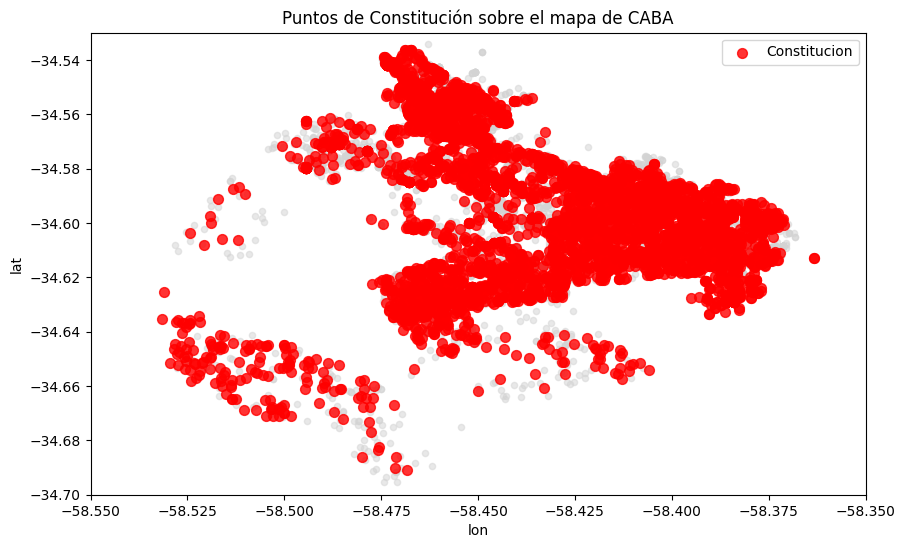

In [ ]:
# 1. Creamos el fondo con TODOS los datos de CABA (en gris)
# (Asumiendo que df_ent tiene una columna para identificar CABA, o usamos todo el dataset si es solo de CABA)
df_caba = df_ent[df_ent["location_3"] == "Ciudad Autónoma de Buenos Aires"]
# Nota: Si "Constitucion" es un barrio dentro de "location_3", tu df_caba original te sirve de fondo.

ax = df_caba.plot.scatter(
    x="lon",
    y="lat",
    xlim=(-58.55, -58.35),
    ylim=(-34.7, -34.53),
    color="lightgrey",   # Fondo gris para el resto de la ciudad
    alpha=0.5,
    figsize=(10, 6)
)

# 2. Filtramos específicamente los datos de Constitución
df_constitucion = df_ent[df_ent["location_3"] == "Constitucion"]

# 3. Dibujamos los puntos de Constitución encima en color rojo
df_constitucion.plot.scatter(
    x="lon",
    y="lat",
    color="red",
    s=50,                # Tamaño de los puntos
    alpha=0.8,
    label="Constitucion",
    ax=ax                # <--- CLAVE: Esto hace que se dibuje sobre el mismo gráfico anterior
)

plt.title("Puntos de Constitución sobre el mapa de CABA")
plt.legend()
plt.show()

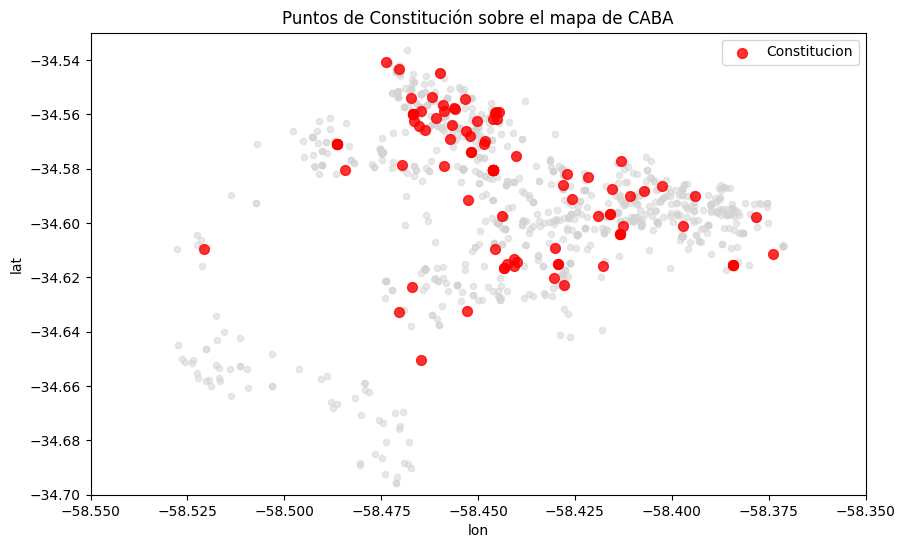

In [ ]:
# 1. Creamos el fondo con TODOS los datos de CABA (en gris)
# (Asumiendo que df_ent tiene una columna para identificar CABA, o usamos todo el dataset si es solo de CABA)
df_caba = df_ap[df_ap["location_3"] == "Ciudad Autónoma de Buenos Aires"]
# Nota: Si "Constitucion" es un barrio dentro de "location_3", tu df_caba original te sirve de fondo.

ax = df_caba.plot.scatter(
    x="lon",
    y="lat",
    xlim=(-58.55, -58.35),
    ylim=(-34.7, -34.53),
    color="lightgrey",   # Fondo gris para el resto de la ciudad
    alpha=0.5,
    figsize=(10, 6)
)

# 2. Filtramos específicamente los datos de Constitución
df_constitucion = df_ap[df_ap["location_3"] == "Constitucion"]

# 3. Dibujamos los puntos de Constitución encima en color rojo
df_constitucion.plot.scatter(
    x="lon",
    y="lat",
    color="red",
    s=50,                # Tamaño de los puntos
    alpha=0.8,
    label="Constitucion",
    ax=ax                # <--- CLAVE: Esto hace que se dibuje sobre el mismo gráfico anterior
)

plt.title("Puntos de Constitución sobre el mapa de CABA")
plt.legend()
plt.show()

In [ ]:
import shapefile
import pandas as pd
from shapely.geometry import shape, Point

# 1. Leer el Shapefile a mano usando 'pyshp'
ruta_shp = "/content/drive/MyDrive/MAESTRÍA CIENCIA DE DATOS - DATA MINING - UBA/2026 - Primer Cuatrimestre/Data Mining - Miérc/TP5 FINAL/barrios/barrios.shp"
sf = shapefile.Reader(ruta_shp)

# Mapeamos los índices de las columnas
campos = [f[0].lower() for f in sf.fields[1:]]
idx_nombre = campos.index('nombre')

barrios_poligonos = {}
for sr in sf.shapeRecords():
    nombre_raw = sr.record[idx_nombre]

    # --- FORMATEO DE TEXTO ---
    # Pasamos a formato Título (ej: SAN CRISTOBAL -> San Cristobal)
    nombre_formateado = str(nombre_raw).title()
    # Quitamos tildes por si el shapefile las trae (para que combine con tu DF)
    reemplazos = [("á", "a"), ("é", "e"), ("í", "i"), ("ó", "o"), ("ú", "u")]
    for original, reemplazo in reemplazos:
        nombre_formateado = nombre_formateado.replace(original, reemplazo)

    poligono = shape(sr.shape.__geo_interface__)
    barrios_poligonos[nombre_formateado] = poligono


# 2. Función para encontrar el barrio y pisar el valor
def corregir_location_3(row):
    # Si NO es Constitucion, dejamos lo que ya tiene
    if row['location_3'] != 'Constitucion':
        return row['location_3']

    # Si ES Constitucion, buscamos geográficamente
    lat, lon = row['lat'], row['lon']
    if pd.isna(lat) or pd.isna(lon):
        return row['location_3']

    punto = Point(lon, lat)

    # Buscamos en qué barrio cae realmente
    for nombre_barrio, poligono in barrios_poligonos.items():
        if poligono.contains(punto):
            return nombre_barrio

    # Si estaba etiquetado como Constitucion pero cayó fuera de los límites de CABA
    return "Ciudad Autónoma de Buenos Aires"


# 3. Guardamos los cambios DIRECTO en la columna original location_3
df_ent['location_3'] = df_ent.apply(corregir_location_3, axis=1)


# 4. Comprobamos el resultado final con tu formato de value_counts
print(df_ent['location_3'].value_counts())

location_3
Palermo                            11789
Belgrano                            8562
Caballito                           6683
Recoleta                            6329
Ciudad Autónoma de Buenos Aires     6169
                                   ...  
Concepcion                             7
Puerto Retiro                          5
Distrito Quartier                      4
Barrio Parque General Belgrano         1
Los Perales                            1
Name: count, Length: 88, dtype: int64


In [ ]:
# 1. Aplicamos la misma función de mapeo pero a tu df_ap
df_ap['location_3'] = df_ap.apply(corregir_location_3, axis=1)

# 2. Tiramos el value_counts para ver cómo impactó en este nuevo DataFrame
print("Distribución de barrios en df_ap corregido:")
print(df_ap['location_3'].value_counts())

Distribución de barrios en df_ap corregido:
location_3
Palermo                            1103
Ciudad Autónoma de Buenos Aires    1008
Caballito                           844
Belgrano                            810
Recoleta                            781
                                   ... 
Flores Sur                            2
Palermo Viejo                         2
Naón                                  1
Barrio Parque General Belgrano        1
Palermo Nuevo                         1
Name: count, Length: 76, dtype: int64


In [ ]:
mapeo_loc_3 = {
    'Nuñez': 'Nuñez',
    'Núñez': 'Nuñez',
    'Balvanera': 'Balvanera',
    'Once': 'Balvanera',
    'San Cristobal': 'San Cristobal',
    'San Cristóbal': 'San Cristobal',
    'San Nicolás': 'San Nicolás',
    'San Nicolas': 'San Nicolás',
    'Centro': 'Centro',
    'Centro / Microcentro': 'Centro',
    'Villa Ortuzar': 'Villa Ortuzar',
    'Villa Ortúzar': 'Villa Ortuzar',
    'Constitucion': 'Constitucion',
    'Constitución': 'Constitucion',
    'Villa Pueyrredon': 'Villa Pueyrredon',
    'Villa Pueyrredón': 'Villa Pueyrredon',
    'Paternal': 'Paternal',
    'La Paternal': 'Paternal',
    'Boca': 'Boca',
    'La Boca': 'Boca',
    'Agronomia': 'Agronomia',
    'Agronomía': 'Agronomia',
    'Monserrat': 'Monserrat',
    'Montserrat': 'Monserrat',
    'Velez Sarsfield': 'Velez Sarsfield',
    'Vélez Sarsfield': 'Velez Sarsfield',
    'Velez Sársfield': 'Velez Sarsfield',
    'Botánico': 'Botánico',
    'Botanico': 'Botanico',
    'Concepcion': 'Concepcion',
    'Concepción': 'Concepcion',
    'Pompeya': 'Pompeya',
    'Nueva Pompeya': 'Pompeya',
    'Ciudad Autónoma de Buenos Aires': 'Ciudad Autónoma de Buenos Aires',
    'Ciudad de Buenos Aires': 'Ciudad Autónoma de Buenos Aires',
    'Capital Federal': 'Ciudad Autónoma de Buenos Aires',
    'Buenos Aires': 'Ciudad Autónoma de Buenos Aires',
}
df_ent['location_3'] = df_ent['location_3'].replace(mapeo_loc_3)
df_ap['location_3'] = df_ap['location_3'].replace(mapeo_loc_3)

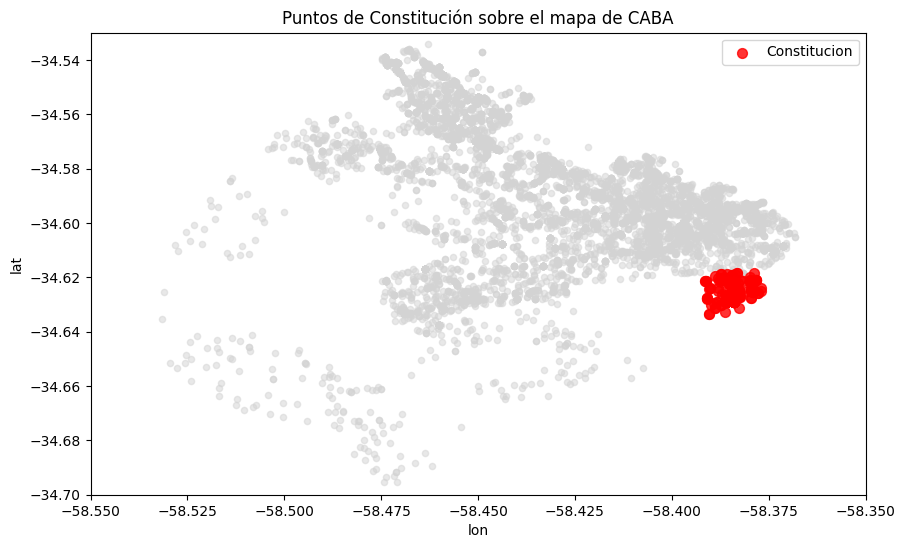

In [ ]:
# 1. Creamos el fondo con TODOS los datos de CABA (en gris)
# (Asumiendo que df_ent tiene una columna para identificar CABA, o usamos todo el dataset si es solo de CABA)
df_caba = df_ent[df_ent["location_3"] == "Ciudad Autónoma de Buenos Aires"]
# Nota: Si "Constitucion" es un barrio dentro de "location_3", tu df_caba original te sirve de fondo.

ax = df_caba.plot.scatter(
    x="lon",
    y="lat",
    xlim=(-58.55, -58.35),
    ylim=(-34.7, -34.53),
    color="lightgrey",   # Fondo gris para el resto de la ciudad
    alpha=0.5,
    figsize=(10, 6)
)

# 2. Filtramos específicamente los datos de Constitución
df_constitucion = df_ent[df_ent["location_3"] == "Constitucion"]

# 3. Dibujamos los puntos de Constitución encima en color rojo
df_constitucion.plot.scatter(
    x="lon",
    y="lat",
    color="red",
    s=50,                # Tamaño de los puntos
    alpha=0.8,
    label="Constitucion",
    ax=ax                # <--- CLAVE: Esto hace que se dibuje sobre el mismo gráfico anterior
)

plt.title("Puntos de Constitución sobre el mapa de CABA")
plt.legend()
plt.show()

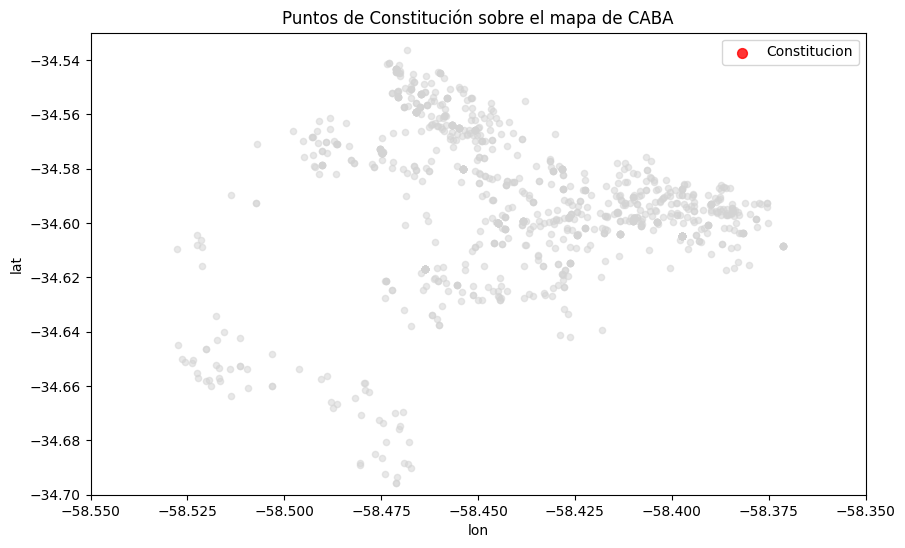

In [ ]:
# 1. Creamos el fondo con TODOS los datos de CABA (en gris)
# (Asumiendo que df_ent tiene una columna para identificar CABA, o usamos todo el dataset si es solo de CABA)
df_caba = df_ap[df_ap["location_3"] == "Ciudad Autónoma de Buenos Aires"]
# Nota: Si "Constitucion" es un barrio dentro de "location_3", tu df_caba original te sirve de fondo.

ax = df_caba.plot.scatter(
    x="lon",
    y="lat",
    xlim=(-58.55, -58.35),
    ylim=(-34.7, -34.53),
    color="lightgrey",   # Fondo gris para el resto de la ciudad
    alpha=0.5,
    figsize=(10, 6)
)

# 2. Filtramos específicamente los datos de Constitución
df_constitucion = df_ap[df_ap["location_3"] == "Constitucion"]

# 3. Dibujamos los puntos de Constitución encima en color rojo
df_constitucion.plot.scatter(
    x="lon",
    y="lat",
    color="red",
    s=50,                # Tamaño de los puntos
    alpha=0.8,
    label="Constitucion",
    ax=ax                # <--- CLAVE: Esto hace que se dibuje sobre el mismo gráfico anterior
)

plt.title("Puntos de Constitución sobre el mapa de CABA")
plt.legend()
plt.show()

### Mejoro la locación de los puntos de Ciudad Autónoma de Buenos Aires

In [ ]:
import shapefile
import pandas as pd
from shapely.geometry import shape, Point

# 1. Leer el Shapefile a mano usando 'pyshp'
ruta_shp = "/content/drive/MyDrive/MAESTRÍA CIENCIA DE DATOS - DATA MINING - UBA/2026 - Primer Cuatrimestre/Data Mining - Miérc/TP5 FINAL/barrios/barrios.shp"
sf = shapefile.Reader(ruta_shp)

# Mapeamos los índices de las columnas
campos = [f[0].lower() for f in sf.fields[1:]]
idx_nombre = campos.index('nombre')

barrios_poligonos = {}
for sr in sf.shapeRecords():
    nombre_raw = sr.record[idx_nombre]

    # --- FORMATEO DE TEXTO ---
    # Pasamos a formato Título (ej: SAN CRISTOBAL -> San Cristobal)
    nombre_formateado = str(nombre_raw).title()
    # Quitamos tildes por si el shapefile las trae (para que combine con tu DF)
    reemplazos = [("á", "a"), ("é", "e"), ("í", "i"), ("ó", "o"), ("ú", "u")]
    for original, reemplazo in reemplazos:
        nombre_formateado = nombre_formateado.replace(original, reemplazo)

    poligono = shape(sr.shape.__geo_interface__)
    barrios_poligonos[nombre_formateado] = poligono


# 2. Función para encontrar el barrio y pisar el valor genérico
def corregir_location_3(row):
    # Si NO es el texto genérico, dejamos el barrio que ya tiene asignado
    if row['location_3'] != 'Ciudad Autónoma de Buenos Aires':
        return row['location_3']

    # Si ES "Ciudad Autónoma de Buenos Aires", buscamos geográficamente el barrio real
    lat, lon = row['lat'], row['lon']
    if pd.isna(lat) or pd.isna(lon):
        return row['location_3']  # Si no hay coordenadas, no podemos hacer magia, se queda igual

    punto = Point(lon, lat)

    # Buscamos en qué polígono de barrio cae el punto
    for nombre_barrio, poligono in barrios_poligonos.items():
        if poligono.contains(punto):
            return nombre_barrio

    # Si decía CABA, pero las coordenadas caen fuera de los límites de los barrios (ej. en el río o Provincia)
    return "Ciudad Autónoma de Buenos Aires"


# 3. Guardamos los cambios DIRECTO en la columna original location_3
df_ent['location_3'] = df_ent.apply(corregir_location_3, axis=1)


# 4. Comprobamos el resultado final
print(df_ent['location_3'].value_counts())

location_3
Palermo                            12567
Belgrano                            9307
Caballito                           7079
Recoleta                            6925
Nuñez                               5399
                                   ...  
Ciudad Autónoma de Buenos Aires        7
Puerto Retiro                          5
Distrito Quartier                      4
Barrio Parque General Belgrano         1
Los Perales                            1
Name: count, Length: 88, dtype: int64


In [ ]:
# 3. Guardamos los cambios DIRECTO en la columna original location_3 del DataFrame df_ap
df_ap['location_3'] = df_ap.apply(corregir_location_3, axis=1)


# 4. Comprobamos el resultado final en df_ap
print(df_ap['location_3'].value_counts())

location_3
Palermo                           1194
Belgrano                           919
Caballito                          896
Recoleta                           895
Villa Urquiza                      700
                                  ... 
Flores Sur                           2
Palermo Viejo                        2
Naón                                 1
Barrio Parque General Belgrano       1
Palermo Nuevo                        1
Name: count, Length: 77, dtype: int64


In [ ]:
mapeo_loc_3 = {
    'Nuñez': 'Nuñez',
    'Núñez': 'Nuñez',
    'Balvanera': 'Balvanera',
    'Once': 'Balvanera',
    'San Cristobal': 'San Cristobal',
    'San Cristóbal': 'San Cristobal',
    'San Nicolás': 'San Nicolás',
    'San Nicolas': 'San Nicolás',
    'Centro': 'Centro',
    'Centro / Microcentro': 'Centro',
    'Villa Ortuzar': 'Villa Ortuzar',
    'Villa Ortúzar': 'Villa Ortuzar',
    'Constitucion': 'Constitucion',
    'Constitución': 'Constitucion',
    'Villa Pueyrredon': 'Villa Pueyrredon',
    'Villa Pueyrredón': 'Villa Pueyrredon',
    'Paternal': 'Paternal',
    'La Paternal': 'Paternal',
    'Boca': 'Boca',
    'La Boca': 'Boca',
    'Agronomia': 'Agronomia',
    'Agronomía': 'Agronomia',
    'Monserrat': 'Monserrat',
    'Montserrat': 'Monserrat',
    'Velez Sarsfield': 'Velez Sarsfield',
    'Vélez Sarsfield': 'Velez Sarsfield',
    'Velez Sársfield': 'Velez Sarsfield',
    'Botánico': 'Botánico',
    'Botanico': 'Botanico',
    'Concepcion': 'Concepcion',
    'Concepción': 'Concepcion',
    'Pompeya': 'Pompeya',
    'Nueva Pompeya': 'Pompeya',
    'Ciudad Autónoma de Buenos Aires': 'Ciudad Autónoma de Buenos Aires',
    'Ciudad de Buenos Aires': 'Ciudad Autónoma de Buenos Aires',
    'Capital Federal': 'Ciudad Autónoma de Buenos Aires',
    'Buenos Aires': 'Ciudad Autónoma de Buenos Aires',
}
df_ent['location_3'] = df_ent['location_3'].replace(mapeo_loc_3)
df_ap['location_3'] = df_ap['location_3'].replace(mapeo_loc_3)

### Mejoro la locación de los puntos de "Centro"

In [ ]:
import shapefile
import pandas as pd
from shapely.geometry import shape, Point

# 1. Leer el Shapefile
ruta_shp = "/content/drive/MyDrive/MAESTRÍA CIENCIA DE DATOS - DATA MINING - UBA/2026 - Primer Cuatrimestre/Data Mining - Miérc/TP5 FINAL/barrios/barrios.shp"
sf = shapefile.Reader(ruta_shp)

campos = [f[0].lower() for f in sf.fields[1:]]
idx_nombre = campos.index('nombre')

barrios_poligonos = {}
for sr in sf.shapeRecords():
    nombre_raw = sr.record[idx_nombre]
    nombre_formateado = str(nombre_raw).title()
    reemplazos = [("á", "a"), ("é", "e"), ("í", "i"), ("ó", "o"), ("ú", "u")]
    for original, reemplazo in reemplazos:
        nombre_formateado = nombre_formateado.replace(original, reemplazo)

    poligono = shape(sr.shape.__geo_interface__)
    barrios_poligonos[nombre_formateado] = poligono


# 2. Función modificada para buscar los que dicen "Centro"
def corregir_location_3(row):
    # Si NO es "Centro", dejamos el barrio que ya tiene
    if row['location_3'] != 'Centro':
        return row['location_3']

    # Si ES "Centro", buscamos geográficamente su barrio real (ej: San Nicolas, Monserrat, Retiro)
    lat, lon = row['lat'], row['lon']
    if pd.isna(lat) or pd.isna(lon):
        return row['location_3']

    punto = Point(lon, lat)

    for nombre_barrio, poligono in barrios_poligonos.items():
        if poligono.contains(punto):
            return nombre_barrio

    # Si decía Centro pero por error cae fuera de CABA, se queda como estaba
    return "Centro"


# 3. Guardamos los cambios DIRECTO en df_ent
df_ent['location_3'] = df_ent.apply(corregir_location_3, axis=1)


# 4. Comprobamos el resultado final en df_ent
print(df_ent['location_3'].value_counts())

location_3
Palermo                           12580
Belgrano                           9314
Caballito                          7096
Recoleta                           6956
Nuñez                              5443
                                  ...  
Puerto Retiro                         5
Distrito Quartier                     4
Centro                                1
Barrio Parque General Belgrano        1
Los Perales                           1
Name: count, Length: 87, dtype: int64


In [ ]:
# 3. Guardamos los cambios DIRECTO en la columna original location_3 del DataFrame df_ap
df_ap['location_3'] = df_ap.apply(corregir_location_3, axis=1)


# 4. Comprobamos el resultado final en df_ap
print(df_ap['location_3'].value_counts())

location_3
Palermo                           1195
Belgrano                           920
Caballito                          903
Recoleta                           898
Villa Urquiza                      701
                                  ... 
Flores Sur                           2
Naón                                 1
Nueva Pompeya                        1
Barrio Parque General Belgrano       1
Palermo Nuevo                        1
Name: count, Length: 76, dtype: int64


In [ ]:
mapeo_loc_3 = {
    'Nuñez': 'Nuñez',
    'Núñez': 'Nuñez',
    'Balvanera': 'Balvanera',
    'Once': 'Balvanera',
    'San Cristobal': 'San Cristobal',
    'San Cristóbal': 'San Cristobal',
    'San Nicolás': 'San Nicolás',
    'San Nicolas': 'San Nicolás',
    'Centro': 'Centro',
    'Centro / Microcentro': 'Centro',
    'Villa Ortuzar': 'Villa Ortuzar',
    'Villa Ortúzar': 'Villa Ortuzar',
    'Constitucion': 'Constitucion',
    'Constitución': 'Constitucion',
    'Villa Pueyrredon': 'Villa Pueyrredon',
    'Villa Pueyrredón': 'Villa Pueyrredon',
    'Paternal': 'Paternal',
    'La Paternal': 'Paternal',
    'Boca': 'Boca',
    'La Boca': 'Boca',
    'Agronomia': 'Agronomia',
    'Agronomía': 'Agronomia',
    'Monserrat': 'Monserrat',
    'Montserrat': 'Monserrat',
    'Velez Sarsfield': 'Velez Sarsfield',
    'Vélez Sarsfield': 'Velez Sarsfield',
    'Velez Sársfield': 'Velez Sarsfield',
    'Botánico': 'Botánico',
    'Botanico': 'Botanico',
    'Concepcion': 'Concepcion',
    'Concepción': 'Concepcion',
    'Pompeya': 'Pompeya',
    'Nueva Pompeya': 'Pompeya',
    'Ciudad Autónoma de Buenos Aires': 'Ciudad Autónoma de Buenos Aires',
    'Ciudad de Buenos Aires': 'Ciudad Autónoma de Buenos Aires',
    'Capital Federal': 'Ciudad Autónoma de Buenos Aires',
    'Buenos Aires': 'Ciudad Autónoma de Buenos Aires',
}
df_ent['location_3'] = df_ent['location_3'].replace(mapeo_loc_3)
df_ap['location_3'] = df_ap['location_3'].replace(mapeo_loc_3)

### Mejoro la locación de los puntos de "San Nicolás"

In [ ]:
import shapefile
import pandas as pd
from shapely.geometry import shape, Point

# 1. Leer el Shapefile
ruta_shp = "/content/drive/MyDrive/MAESTRÍA CIENCIA DE DATOS - DATA MINING - UBA/2026 - Primer Cuatrimestre/Data Mining - Miérc/TP5 FINAL/barrios/barrios.shp"
sf = shapefile.Reader(ruta_shp)

campos = [f[0].lower() for f in sf.fields[1:]]
idx_nombre = campos.index('nombre')

barrios_poligonos = {}
for sr in sf.shapeRecords():
    nombre_raw = sr.record[idx_nombre]
    nombre_formateado = str(nombre_raw).title()
    reemplazos = [("á", "a"), ("é", "e"), ("í", "i"), ("ó", "o"), ("ú", "u")]
    for original, reemplazo in reemplazos:
        nombre_formateado = nombre_formateado.replace(original, reemplazo)

    poligono = shape(sr.shape.__geo_interface__)
    barrios_poligonos[nombre_formateado] = poligono


# 2. Función modificada para buscar "San Nicolas" (sin tilde) y devolverlo con tilde
def corregir_location_3(row):
    # IMPORTANTE: Buscamos "San Nicolas" tal cual venga en tu dataset actual si querés corregir ese barrio
    # Si preferís que busque los que dicen exactamente "San Nicolás" con tilde en tu DF, agregásela acá:
    if row['location_3'] != 'San Nicolas' and row['location_3'] != 'San Nicolás':
        return row['location_3']

    lat, lon = row['lat'], row['lon']
    if pd.isna(lat) or pd.isna(lon):
        # Si no hay coordenadas, por lo menos nos aseguramos de dejarlo lindo con tilde
        return "San Nicolás"

    punto = Point(lon, lat)

    for nombre_barrio, poligono in barrios_poligonos.items():
        if poligono.contains(punto):
            # Si el shapefile nos dice que es San Nicolas, lo devolvemos con tilde correctiva
            if nombre_barrio == 'San Nicolas':
                return "San Nicolás"
            return nombre_barrio

    return "San Nicolás"


# 3. Guardamos los cambios DIRECTO en df_ent
df_ent['location_3'] = df_ent.apply(corregir_location_3, axis=1)


# 4. Comprobamos el resultado final en df_ent
print(df_ent['location_3'].value_counts())

location_3
Palermo                           12581
Belgrano                           9314
Caballito                          7096
Recoleta                           6957
Nuñez                              5443
                                  ...  
Puerto Retiro                         5
Distrito Quartier                     4
Centro                                1
Barrio Parque General Belgrano        1
Los Perales                           1
Name: count, Length: 86, dtype: int64


In [ ]:
# 3. Guardamos los cambios DIRECTO en la columna original location_3 del DataFrame df_ap
df_ap['location_3'] = df_ap.apply(corregir_location_3, axis=1)


# 4. Comprobamos el resultado final en df_ap
print(df_ap['location_3'].value_counts())

location_3
Palermo                           1195
Belgrano                           920
Caballito                          903
Recoleta                           898
Villa Urquiza                      701
                                  ... 
Flores Sur                           2
Palermo Viejo                        2
Naón                                 1
Barrio Parque General Belgrano       1
Palermo Nuevo                        1
Name: count, Length: 74, dtype: int64


In [ ]:
mapeo_loc_3 = {
    'Nuñez': 'Nuñez',
    'Núñez': 'Nuñez',
    'Balvanera': 'Balvanera',
    'Once': 'Balvanera',
    'San Cristobal': 'San Cristobal',
    'San Cristóbal': 'San Cristobal',
    'San Nicolás': 'San Nicolás',
    'San Nicolas': 'San Nicolás',
    'Centro': 'Centro',
    'Centro / Microcentro': 'Centro',
    'Villa Ortuzar': 'Villa Ortuzar',
    'Villa Ortúzar': 'Villa Ortuzar',
    'Constitucion': 'Constitucion',
    'Constitución': 'Constitucion',
    'Villa Pueyrredon': 'Villa Pueyrredon',
    'Villa Pueyrredón': 'Villa Pueyrredon',
    'Paternal': 'Paternal',
    'La Paternal': 'Paternal',
    'Boca': 'Boca',
    'La Boca': 'Boca',
    'Agronomia': 'Agronomia',
    'Agronomía': 'Agronomia',
    'Monserrat': 'Monserrat',
    'Montserrat': 'Monserrat',
    'Velez Sarsfield': 'Velez Sarsfield',
    'Vélez Sarsfield': 'Velez Sarsfield',
    'Velez Sársfield': 'Velez Sarsfield',
    'Botánico': 'Botánico',
    'Botanico': 'Botanico',
    'Concepcion': 'Concepcion',
    'Concepción': 'Concepcion',
    'Pompeya': 'Pompeya',
    'Nueva Pompeya': 'Pompeya',
    'Ciudad Autónoma de Buenos Aires': 'Ciudad Autónoma de Buenos Aires',
    'Ciudad de Buenos Aires': 'Ciudad Autónoma de Buenos Aires',
    'Capital Federal': 'Ciudad Autónoma de Buenos Aires',
    'Buenos Aires': 'Ciudad Autónoma de Buenos Aires',
}
df_ent['location_3'] = df_ent['location_3'].replace(mapeo_loc_3)
df_ap['location_3'] = df_ap['location_3'].replace(mapeo_loc_3)

### Sigo asignando

In [ ]:
df_ent = df_ent.drop(100235) # duplicado
df_ent = df_ent.drop(100871) # duplicado
df_ent = df_ent.drop(475199) # duplicado
df_ent = df_ent.drop(653920) # duplicado
df_ent = df_ent.drop(975631) # duplicado
df_ent = df_ent.drop(975638) # duplicado
df_ent = df_ent.drop(100891) # duplicado
df_ent = df_ent.drop(100991) # duplicado
df_ent = df_ent.drop(101716) # duplicado
df_ent = df_ent.drop(103241) # duplicado
df_ent = df_ent.drop(696241) # duplicado
df_ent = df_ent.drop(937691) # duplicado
df_ent = df_ent.drop(103725) # duplicado
df_ent = df_ent.drop(105468) # duplicado
df_ent = df_ent.drop(106179) # duplicado
df_ent = df_ent.drop(106493) # duplicado
df_ent = df_ent.drop(375852) # duplicado
df_ent = df_ent.drop(1013857) # duplicado
df_ent = df_ent.drop(944320) # duplicado
df_ent = df_ent.drop(955352) # duplicado
df_ent = df_ent.drop(1013850) # duplicado
df_ent = df_ent.drop(658079) # duplicado
df_ent = df_ent.drop(962344) # duplicado
df_ent = df_ent.drop(109460) # falta info
df_ent = df_ent.drop(96777) # duplicado
df_ent = df_ent.drop(97841) # duplicado
df_ent = df_ent.drop(101895) # duplicado
df_ent = df_ent.drop(115376) # duplicado
df_ent = df_ent.drop(266148) # duplicado
df_ent = df_ent.drop(381941) # duplicado
df_ent = df_ent.drop(714023) # duplicado
df_ent = df_ent.drop(1076883) # duplicado
df_ent = df_ent.drop(322407) # falta info
df_ent = df_ent.drop(267961) # duplicado
df_ent = df_ent.drop(267960) # duplicado
df_ent = df_ent.drop(267959) # duplicado
df_ent = df_ent.drop(1051021) # duplicado
df_ent = df_ent.drop(1051020) # duplicado
df_ent = df_ent.drop(1179962) # duplicado
df_ent = df_ent.drop(1001174) # duplicado
df_ent = df_ent.drop(265203) # falta info
df_ent = df_ent.drop(94480) # deposito
df_ent = df_ent.drop(103558) # falta info
df_ent = df_ent.drop(104303) # falta info
df_ent = df_ent.drop(112238) # falta info
df_ent = df_ent.drop(695547) # falta info
df_ent = df_ent.drop(268063) # falta info
df_ent = df_ent.drop(268153) # falta info
df_ent = df_ent.drop(1038505) # falta info
df_ent = df_ent.drop(265166) # falta info
df_ent = df_ent.drop(764166) # falta info
df_ent = df_ent.drop(1067818) # falta info
df_ent = df_ent.drop(1067819) # falta info
df_ent = df_ent.drop(112526) # falta info
df_ent = df_ent.drop(112571) # falta info
df_ent = df_ent.drop(113426) # falta info
df_ent = df_ent.drop(113428) # falta info
df_ent = df_ent.drop(113429) # falta info
df_ent = df_ent.drop(113433) # falta info
df_ent = df_ent.drop(113458) # falta info
df_ent = df_ent.drop(114096) # falta info
df_ent = df_ent.drop(114110) # falta info
df_ent = df_ent.drop(114119) # falta info
df_ent = df_ent.drop(114124) # falta info
df_ent = df_ent.drop(114125) # falta info
df_ent = df_ent.drop(114133) # falta info
df_ent = df_ent.drop(114134) # falta info
df_ent = df_ent.drop(114135) # falta info
df_ent = df_ent.drop(111323) # falta info
df_ent = df_ent.drop(121132) # falta info
df_ent = df_ent.drop(121482) # falta info
df_ent = df_ent.drop(121585) # falta info
df_ent = df_ent.drop(122139) # falta info
df_ent = df_ent.drop(122485) # falta info
df_ent = df_ent.drop(122522) # falta info
df_ent = df_ent.drop(122566) # falta info
df_ent = df_ent.drop(267480) # falta info
df_ent = df_ent.drop(267499) # falta info
df_ent = df_ent.drop(1038428) # falta info
df_ent = df_ent.drop(989634) # duplicado
df_ent = df_ent.drop(989553) # duplicado
df_ent = df_ent.drop(1012338) # falta info
df_ent = df_ent.drop(1097528) # falta info
df_ent = df_ent.drop(989554) # duplicado
df_ent = df_ent.drop(324787) # falta info
df_ent = df_ent.drop(828969) # falta info
df_ent = df_ent.drop(955353) # duplicado
df_ent = df_ent.drop(986651) # duplicado
df_ent = df_ent.drop(106869) # falta info
df_ent = df_ent.drop(107128) # falta info
df_ent = df_ent.drop(107130) # falta info
df_ent = df_ent.drop(108229) # falta info
df_ent = df_ent.drop(108297) # falta info
df_ent = df_ent.drop(109018) # falta info
df_ent = df_ent.drop(109137) # falta info
df_ent = df_ent.drop(109153) # falta info
df_ent = df_ent.drop(109408) # falta info
df_ent = df_ent.drop(117482) # falta info
df_ent = df_ent.drop(123629) # falta info
df_ent = df_ent.drop(108287) # duplicado
df_ent = df_ent.drop(108290) # duplicado
df_ent = df_ent.drop(108291) # duplicado
df_ent = df_ent.drop(713354) # outlier, muy caro
df_ent = df_ent.drop(97710) # falta info
df_ent = df_ent.drop(96716) # falta info
df_ent = df_ent.drop(97658) # duplicado
df_ent = df_ent.drop(829313) # duplicado
df_ent = df_ent.drop(999532) # falta info
df_ent = df_ent.drop(1005778) # falta info
df_ent = df_ent.drop(1023650) # falta info
df_ent = df_ent.drop(324606) # falta info
df_ent = df_ent.drop(324651) # falta info
df_ent = df_ent.drop(324201) # duplicado
df_ent = df_ent.drop(110419) # falta info
df_ent = df_ent.drop(265928) # local comercial
df_ent = df_ent.drop(265141) # duplicado
df_ent = df_ent.drop(265143) # duplicado
df_ent = df_ent.drop(457895) # mala info
df_ent = df_ent.drop(1217896) # mala info
df_ent = df_ent.drop(107098) # fuera caba
df_ent = df_ent.drop(109515) # fuera caba
df_ent = df_ent.drop(267086) # fuera caba
df_ent = df_ent.drop(124492) # duplicado
df_ent = df_ent.drop(124493) # duplicado
df_ent = df_ent.drop(1233564) # mala info
df_ent = df_ent.drop(695701) # mala info
df_ent = df_ent.drop(113633) # mala info
df_ent = df_ent.drop(963534) # outlier, muy caro
df_ent = df_ent.drop(963535) # outlier, muy caro
df_ent = df_ent.drop(1076591) # outlier, muy caro
df_ent = df_ent.drop(1086828) # outlier, muy caro
df_ent = df_ent.drop(771947) # mala info
df_ent = df_ent.drop(781665) # mala info
df_ent = df_ent.drop(957995) # mala info
df_ent = df_ent.drop(1005544) # mala info
df_ent = df_ent.drop(1013702) # mala info
df_ent = df_ent.drop(1050751) # mala info
df_ent = df_ent.drop(100873) # mala info
df_ent = df_ent.drop(958734) # duplicado
df_ent = df_ent.drop(958736) # duplicado
df_ent = df_ent.drop(958732) # duplicado
df_ent = df_ent.drop(120217) # mala info
df_ent = df_ent.drop(736912) # mala info
df_ent = df_ent.drop(265248) # es de cordoba
df_ent = df_ent.drop(123728) # mala info
df_ent = df_ent.drop(124576) # mala info
df_ent = df_ent.drop(988738) # outlier, muy caro
df_ent = df_ent.drop(109016) # mala info
df_ent = df_ent.drop(376181) # mala info
df_ent = df_ent.drop(124942) # mala info
df_ent = df_ent.drop(125266) # mala info
df_ent = df_ent.drop(1059704) # outlier, muy caro
df_ent = df_ent.drop(114502) # outlier, muy caro
df_ent = df_ent.drop(821907) # outlier, muy caro
df_ent = df_ent.drop(944319) # outlier, muy caro
df_ent = df_ent.drop(964695) # outlier, muy caro
df_ent = df_ent.drop(266702) # duplicado
df_ent = df_ent.drop(266595) # muy caro
df_ent = df_ent.drop(938057) # mala info
df_ent = df_ent.drop(1227678) # mala info
df_ent = df_ent.drop(266686) # duplicado
df_ent = df_ent.drop(768979) # outlier, muy caro
df_ent = df_ent.drop(945884) # outlier, muy caro
df_ent = df_ent.drop(814304) # outlier, muy caro
df_ent = df_ent.drop(695492) # outlier, muy caro
df_ent = df_ent.drop(695491) # outlier, muy caro
df_ent = df_ent.drop(1235209) # mala info
df_ent = df_ent.drop(956957) # duplicado
df_ent = df_ent.drop(1002375) # villa celina
df_ent = df_ent.drop(843796) # muy caro
df_ent = df_ent.drop(829103) # duplicado
df_ent = df_ent.drop(1077733) # duplicado
df_ent = df_ent.drop(944317) # duplicado
df_ent = df_ent.drop(955351) # duplicado
df_ent = df_ent.drop(996086) # no tiene info
df_ent = df_ent.drop(1174621) # no tiene info
df_ent = df_ent.drop(785597) # duplicado
df_ent = df_ent.drop(109717) # duplicado
df_ent = df_ent.drop(109719) # duplicado
df_ent = df_ent.drop(813802) # montevideo al 1900
df_ent = df_ent.drop(106688) # recoleta
df_ent = df_ent.drop(105669) # recoleta
df_ent = df_ent.drop(842160) # recoleta
df_ent = df_ent.drop(1104365) # recoleta
df_ent = df_ent.drop(469341) # Azucena Villaflor al 500 - Alvear Tower
df_ent = df_ent.drop(469343) # Azucena Villaflor al 500 - Alvear Tower
df_ent = df_ent.drop(471148) # Azucena Villaflor al 500 - Alvear Tower
df_ent = df_ent.drop(471149) # Azucena Villaflor al 500 - Alvear Tower
df_ent = df_ent.drop(471153) # Azucena Villaflor al 500 - Alvear Tower
df_ent = df_ent.drop(484766) # Azucena Villaflor al 500 - Alvear Tower
df_ent = df_ent.drop(658970) # Azucena Villaflor al 500 - Alvear Tower
df_ent = df_ent.drop(727361) # Azucena Villaflor al 500 - Alvear Tower
df_ent = df_ent.drop(827709) # Azucena Villaflor al 500 - Alvear Tower
df_ent = df_ent.drop(827964) # Azucena Villaflor al 500 - Alvear Tower
df_ent = df_ent.drop(106213) # outlier recoleta duplicado depto frances
df_ent = df_ent.drop(469054) # outlier recoleta duplicado depto frances
df_ent = df_ent.drop(705534) # outlier recoleta duplicado depto frances
df_ent = df_ent.drop(724429) # outlier recoleta duplicado depto frances
df_ent = df_ent.drop(743164) # outlier recoleta duplicado depto frances
df_ent = df_ent.drop(806099) # outlier recoleta duplicado depto frances
df_ent = df_ent.drop(991079) # outlier recoleta duplicado depto frances
df_ent = df_ent.drop(1023574) # montevideo al 1900
df_ent = df_ent.drop(1062754) # duplicado
df_ent = df_ent.drop(1072065) # block
df_ent = df_ent.drop(104084) # outlier, muy caro
df_ent = df_ent.drop(958668) # outlier, muy caro
df_ent = df_ent.drop(112267) # outlier 2 cocheras
df_ent = df_ent.drop(469117) # outlier, muy caro
df_ent = df_ent.drop(267795) # no tiene info
df_ent = df_ent.drop(788494) # no tiene info
df_ent = df_ent.drop(265844) # outlier, muy caro
df_ent = df_ent.drop(1184781) # outlier, muy caro
df_ent = df_ent.drop(1235854) # outlier, muy caro
df_ent = df_ent.drop(1009726) # outlier, muy caro
df_ent = df_ent.drop(955951) # outlier, muy caro
df_ent = df_ent.drop(125233) # outlier, muy caro
df_ent = df_ent.drop(1003797) # outlier, muy caro
df_ent = df_ent.drop(993712) # outlier, hotel faena muy caro san telmo
df_ent = df_ent.drop(1195904) # outlier,ramos mejia
df_ent = df_ent.drop(1003796) # outlier, muy caro
df_ent = df_ent.drop(1003798) # outlier, muy caro
df_ent = df_ent.drop(125123) # outlier, muy caro
df_ent = df_ent.drop(108958) # outlier, muy caro
df_ent = df_ent.drop(98827) # outlier, muy caro
df_ent = df_ent.drop(105780) # outlier, muy caro
df_ent = df_ent.drop(125566) # outlier, muy caro
df_ent = df_ent.drop(106103) # outlier, muy caro
df_ent = df_ent.drop(105023) # outlier, muy caro
df_ent = df_ent.drop(117493) # outlier, muy caro
df_ent = df_ent.drop(267978) # outlier, edificio entero

In [ ]:
df_ent.shape

(108118, 67)

In [ ]:
# Lista de columnas a verificar
columnas_criticas = [
    'description', 'features', 'address', 'location_3',
    'banos', 'dormitorios', 'price', 'source'
]

# Elimina filas donde TODAS las columnas de la lista sean NaN
df_ent = df_ent.dropna(subset=columnas_criticas, how='all')

In [ ]:
df_ent.shape

(108117, 67)

In [ ]:
# los que aparecian como Concepcion
df_ent.loc[df_ent['address'].str.contains('Concepción Arenal 2989', case=False, na=False), 'location_3'] = 'Colegiales'
df_ent.loc[df_ent['address'].str.contains('Calle Concepción Arenal 2927', case=False, na=False), 'location_3'] = 'Colegiales'
df_ent.loc[df_ent['address'].str.contains('Calle General Ramón Freire 20-100', case=False, na=False), 'location_3'] = 'Colegiales'
df_ent.loc[df_ent['address'].str.contains('Retto Bar, Avenida Álvarez Thomas', case=False, na=False), 'location_3'] = 'Colegiales'
df_ent.loc[df_ent['address'].str.contains('Avenida Federico Lacroze 3060', case=False, na=False), 'location_3'] = 'Colegiales'

In [ ]:
# ELIMINO LOS DE ZAHA HADID
#df_ent = df_ent[df_ent['tiene_zaha_hadid'] != 1]

#df_ent = df_ent.drop(columns=["tiene_zaha_hadid"])
#df_ap = df_ap.drop(columns=["tiene_zaha_hadid"])

In [ ]:
df_ent = df_ent[df_ent["es_camion"] != 1]
#df_ap = df_ap[df_ap["es_camion"] != 1] esto no lo puedo hacer xq es sacar filas de ap
#df_ent = df_ent.drop("es_camion", axis=1)
#df_ap = df_ap.drop("es_camion", axis=1)

In [ ]:
df_ent = df_ent[df_ent["es_deposito"] != 1]
#df_ap = df_ap[df_ap["es_deposito"] != 1]
#df_ent = df_ent.drop("es_deposito", axis=1)
#df_ap = df_ap.drop("es_deposito", axis=1)

In [ ]:
df_ent["es_comercial"] = df_ent["description"].str.contains("fondo de comercio", case=False, na=False)
df_ap["es_comercial"] = df_ap["description"].str.contains("fondo de comercio", case=False, na=False)

In [ ]:
df_ent = df_ent[df_ent["es_comercial"] != 1]
#df_ap = df_ap[df_ap["es_comercial"] != 1]
#df_ent = df_ent.drop("es_comercial", axis=1)
#df_ap = df_ap.drop("es_comercial", axis=1)

In [ ]:
# Calculo el valor del metro cuadrado promedio por barrio
#df_ent["precio_m2_aux"] = df_ent["price"] / df_ent["m2"]
#df_ent["precio_m2_aux"] = df_ent["precio_m2_aux"].replace([np.inf, -np.inf], np.nan)
#df_ent["precio_m2_aux"] = df_ent["precio_m2_aux"].fillna(df_ent["precio_m2_aux"].median())

# Creación del precio por m2 de cada fila
#zona_map = df_ent.groupby("location_3")["precio_m2_aux"].median()
#mediana_precio_m2_aux = df_ent["precio_m2_aux"].median()

# Creación del "Mapa de Precios" por barrio en la columna "precio_m2_barrio"
#df_ent["precio_m2_barrio"] = df_ent["location_3"].map(zona_map).fillna(mediana_precio_m2_aux)
#df_ap["precio_m2_barrio"] = df_ap["location_3"].map(zona_map).fillna(mediana_precio_m2_aux)

In [ ]:
# Calculo el valor del metro cuadrado promedio por barrio
df_ent["precio_m2_aux"] = df_ent["price"] / df_ent["m2"]
df_ent["precio_m2_aux"] = df_ent["precio_m2_aux"].replace([np.inf, -np.inf], np.nan)
df_ent["precio_m2_aux"] = df_ent["precio_m2_aux"].fillna(df_ent["precio_m2_aux"].median())

# Creación del precio por m2 de cada fila
zona_map = df_ent.groupby("location_3")["precio_m2_aux"].median()
mediana_precio_m2_aux = df_ent["precio_m2_aux"].median()

# Creación del "Mapa de Precios" por barrio en la columna "precio_m2_barrio"
df_ent["precio_m2_barrio"] = df_ent["location_3"].map(zona_map).fillna(mediana_precio_m2_aux)
df_ap["precio_m2_barrio"] = df_ap["location_3"].map(zona_map).fillna(mediana_precio_m2_aux)

# Referencia de precio/m² por barrio y tipo (casa vs departamento)
zona_tipo_map = df_ent.groupby(["location_3", "property_type"])["precio_m2_aux"].median()
idx_ent = pd.MultiIndex.from_frame(df_ent[["location_3", "property_type"]])
idx_ap = pd.MultiIndex.from_frame(df_ap[["location_3", "property_type"]])
df_ent["precio_m2_barrio_tipo"] = zona_tipo_map.reindex(idx_ent).to_numpy()
df_ap["precio_m2_barrio_tipo"] = zona_tipo_map.reindex(idx_ap).to_numpy()
df_ent["precio_m2_barrio_tipo"] = df_ent["precio_m2_barrio_tipo"].fillna(mediana_precio_m2_aux)
df_ap["precio_m2_barrio_tipo"] = df_ap["precio_m2_barrio_tipo"].fillna(mediana_precio_m2_aux)

/tmp/ipykernel_145/4063908144.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_plot, x="precio_m2_barrio", y="location_3", palette="viridis")


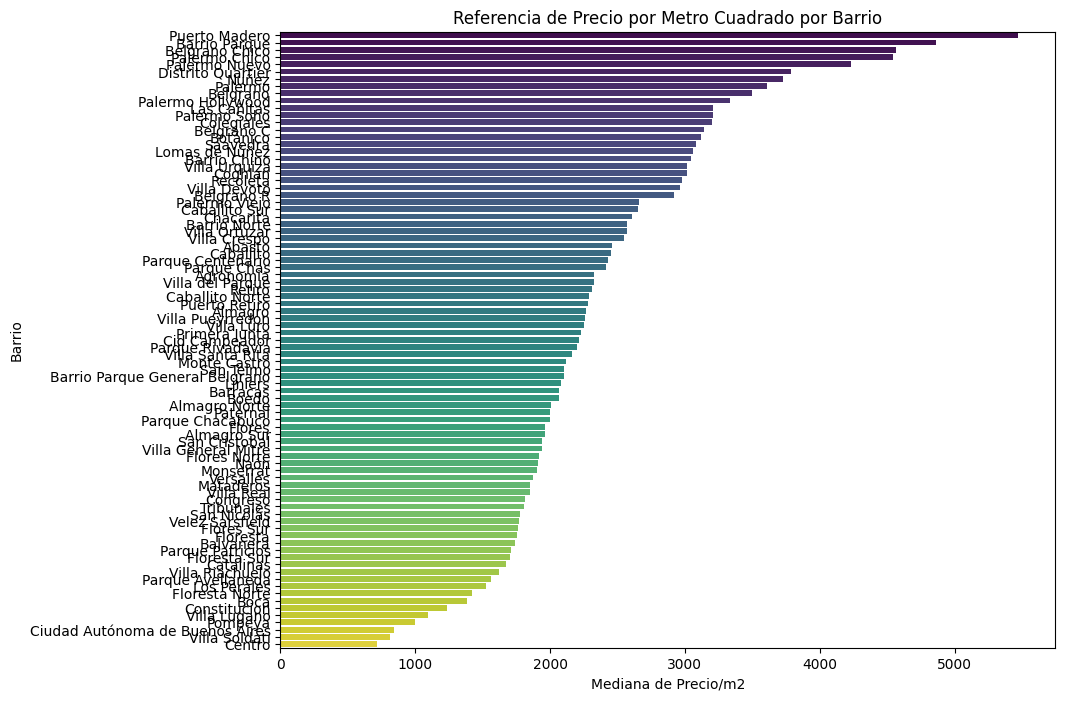

In [ ]:
# Agrupamos para tener un solo valor por barrio y ordenamos
df_plot = df_ent.groupby("location_3")["precio_m2_barrio"].first().reset_index().sort_values("precio_m2_barrio", ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=df_plot, x="precio_m2_barrio", y="location_3", palette="viridis")
plt.title("Referencia de Precio por Metro Cuadrado por Barrio")
plt.xlabel("Mediana de Precio/m2")
plt.ylabel("Barrio")
plt.show()

/tmp/ipykernel_145/3287985374.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_plot, x="precio_m2_barrio", y="location_3", palette="viridis")


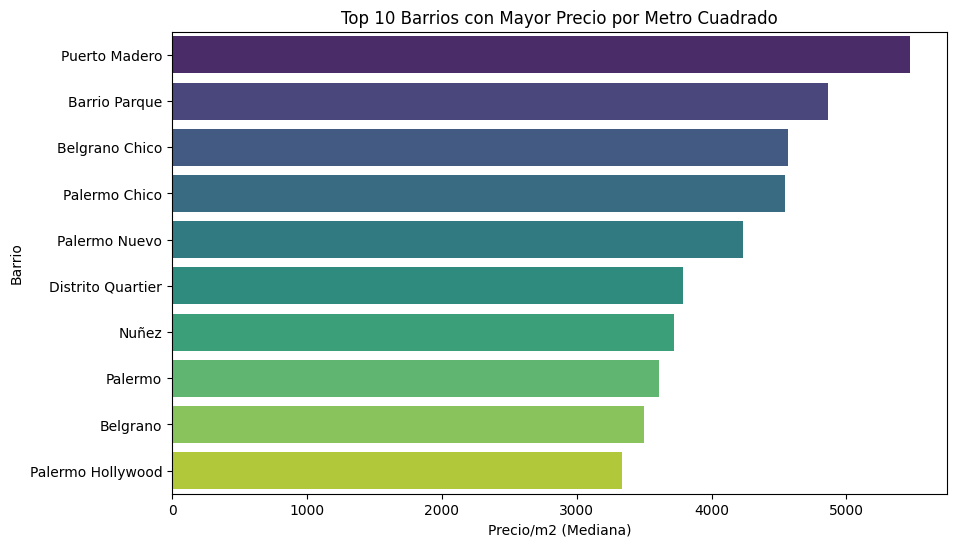

In [ ]:
# Agrupamos, ordenamos de mayor a menor y seleccionamos los primeros 10
df_plot = (df_ent.groupby("location_3")["precio_m2_barrio"]
           .first()
           .reset_index()
           .sort_values("precio_m2_barrio", ascending=False)
           .head(10)) # <--- Filtro para el Top 10

plt.figure(figsize=(10, 6))
sns.barplot(data=df_plot, x="precio_m2_barrio", y="location_3", palette="viridis")

plt.title("Top 10 Barrios con Mayor Precio por Metro Cuadrado")
plt.xlabel("Precio/m2 (Mediana)")
plt.ylabel("Barrio")
plt.show()

In [ ]:
# BARRIOS QUE HAY EN DF_AP
with pd.option_context('display.max_rows', None):
    print(df_ap["location_3"].value_counts())

location_3
Palermo                           1195
Belgrano                           920
Caballito                          903
Recoleta                           898
Villa Urquiza                      701
Almagro                            688
Villa Crespo                       673
Flores                             448
Villa Devoto                       422
Liniers                            361
Nuñez                              328
Villa del Parque                   319
Balvanera                          303
Barrio Norte                       290
Colegiales                         286
Villa Luro                         278
Saavedra                           272
Puerto Madero                      272
Mataderos                          234
Barracas                           209
Parque Chacabuco                   202
San Telmo                          180
Boedo                              178
Retiro                             171
Chacarita                          163
Villa Pueyrred

In [ ]:
filtro_premium = df_ent["precio_m2_aux"] >17000
df_ent[filtro_premium][["description", "address", "features", "location_3", "dormitorios", "banos", "m2", "price", "precio_m2_aux","source"]]


,description,address,features,location_3,dormitorios,banos,m2,price,precio_m2_aux,source
id,,,,,,,,,,


In [ ]:
#filtro_premium = (df_ent["location_3"] == "Palermo") & (df_ent["precio_m2_aux"] >9000) & (df_ent["precio_m2_aux"] <10000) #20000
filtro_premium = (df_ent["location_3"] == "Retiro") & (df_ent["precio_m2_aux"] >5000) #20000
df_ent[filtro_premium][["description", "address","features", "location_3" ,"dormitorios", "banos", "m2", "price", "precio_m2_aux","lat","lon"]]

,description,address,features,location_3,dormitorios,banos,m2,price,precio_m2_aux,lat,lon
id,,,,,,,,,,,
469284,departamento en venta en edificio antiguo de e...,Juncal al 900,departamentos por piso: 2; cantidad pisos en e...,Retiro,4.0,3.0,180.0,965000.0,5361.111111,-34.592823,-58.380451
485315,"triplex en piso alto, muy luminoso, reciclado ...",Suipacha al 1300,departamentos por piso: 2; cantidad pisos en e...,Retiro,3.0,4.0,234.0,1200000.0,5128.205128,-34.591618,-58.380035
819632,venta departamento en torre libertador 380 3 d...,Av. Del Libertador al 300,sup. cubierta:174 m² cubierta; dormitorios:3 ...,Retiro,3.0,2.0,180.0,1200000.0,6666.666667,-34.595749,-58.379025
942747,"venta mono ambiente en retiro, torre bellini ...",Esmeralda al 900,sup. cubierta:29 m² cubierta; dormitorios:1 d...,Retiro,1.0,1.0,29.0,150000.0,5172.413793,-34.595749,-58.379025
975637,bellini plaza san martín - residencias apto pr...,Esmeralda 900,sup. cubierta:45 m² cubierta; dormitorios:1 d...,Retiro,1.0,1.0,45.0,227000.0,5044.444444,-34.597649,-58.378391
1078881,venta departamento de 3 ambientes en exclusiva...,Arroyo al 800,sup. cubierta:62 m² cubierta; dormitorios:2 d...,Retiro,2.0,1.0,62.0,349000.0,5629.032258,-34.591579,-58.379406
1238331,"departamento semipiso en venta en centro, cap...",Esmeralda 900,sup. cubierta:30 m² cubierta; dormitorios:1 d...,Retiro,1.0,1.0,30.0,158000.0,5266.666667,-34.597672,-58.378422
1239268,juncal y suipacha ...,"Juncal 900, Piso 3",sup. cubierta:180 m² cubierta; dormitorios:4 ...,Retiro,4.0,2.0,180.0,965000.0,5361.111111,-34.595749,-58.379025
1239997,suipacha y arroyo ...,"Suipacha 1300, Piso 11",sup. cubierta:200 m² cubierta; dormitorios:3 ...,Retiro,3.0,3.0,234.0,1200000.0,5128.205128,-34.595749,-58.379025


In [ ]:
# Filtrar las filas que contienen la dirección específica
#resultados = df_ent[df_ent['address'].str.contains('Franklin 2188', case=False, na=False)]

# Mostrar los resultados
#resultados[["description", "address", "features", "location_3", "dormitorios", "banos", "m2", "price", "precio_m2_aux"]]

In [ ]:
df_ent=df_ent[df_ent["location_3"].notna()]

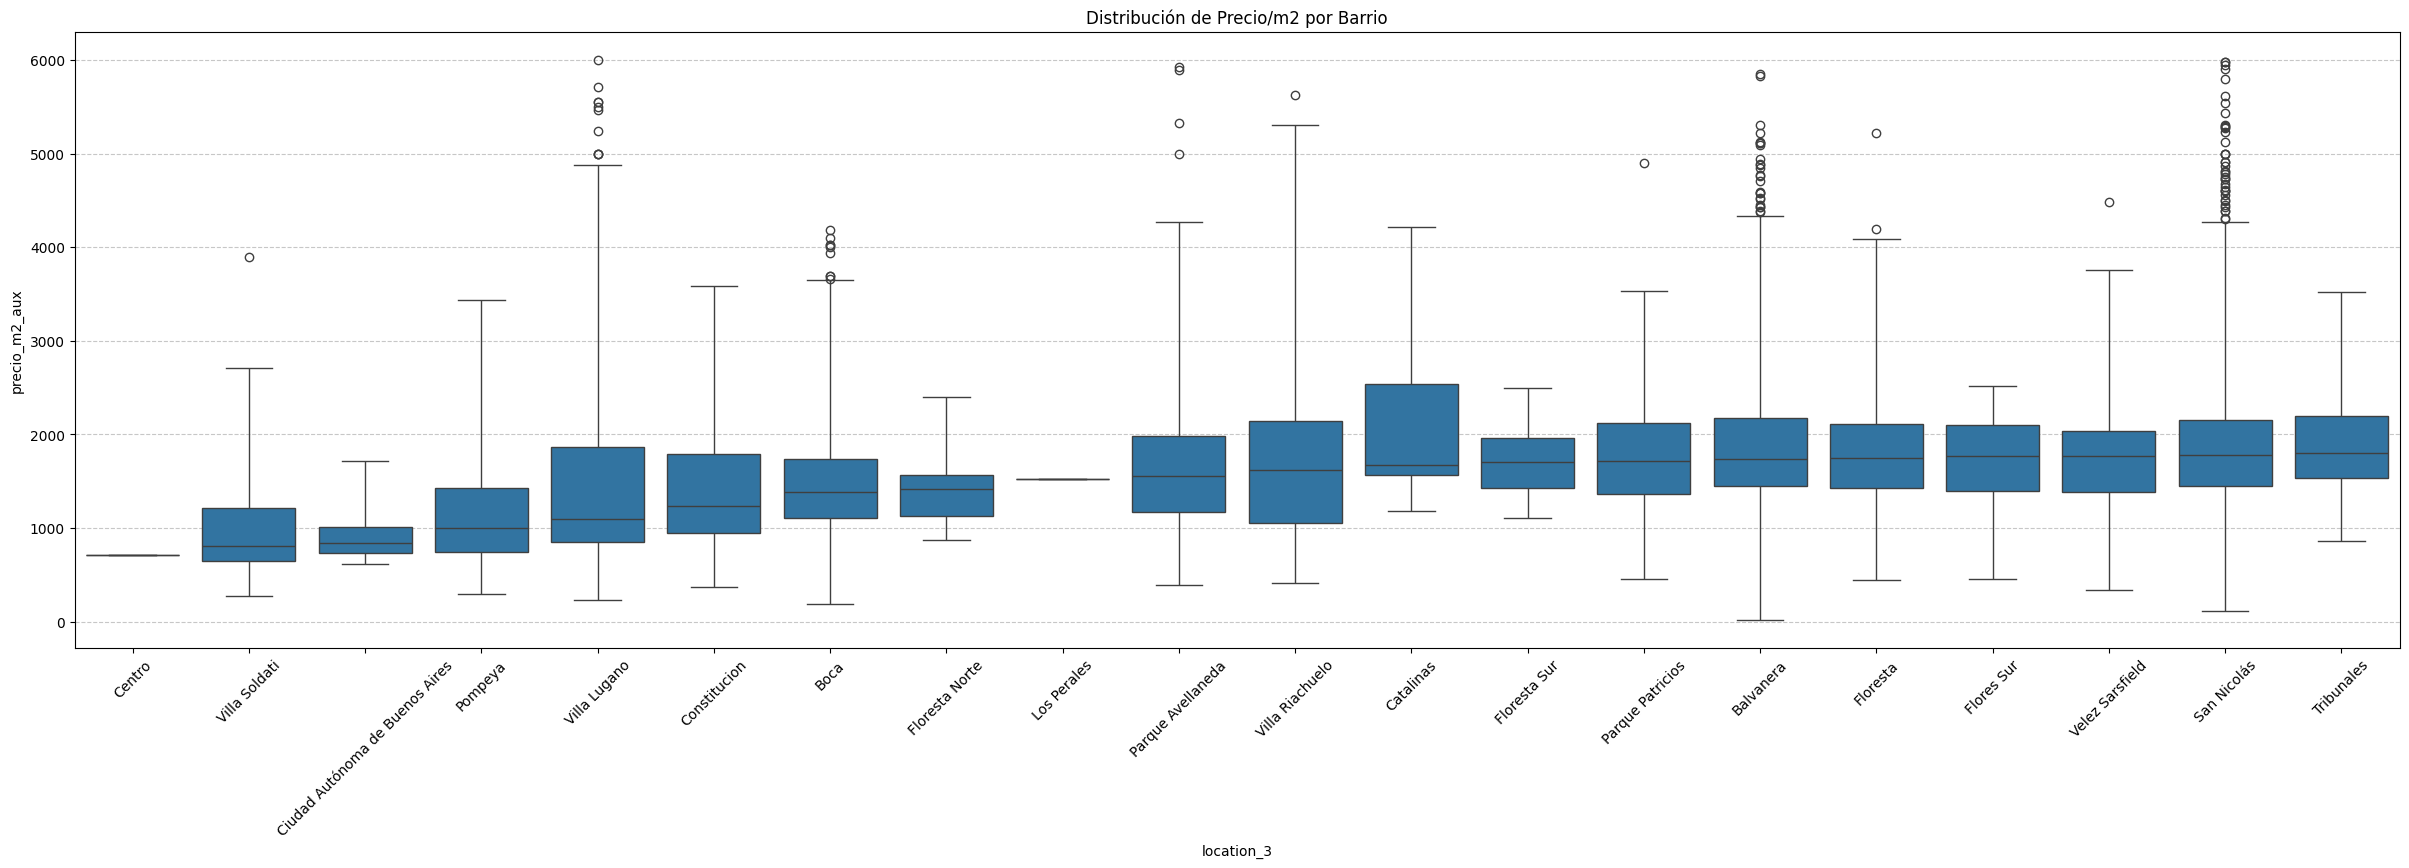

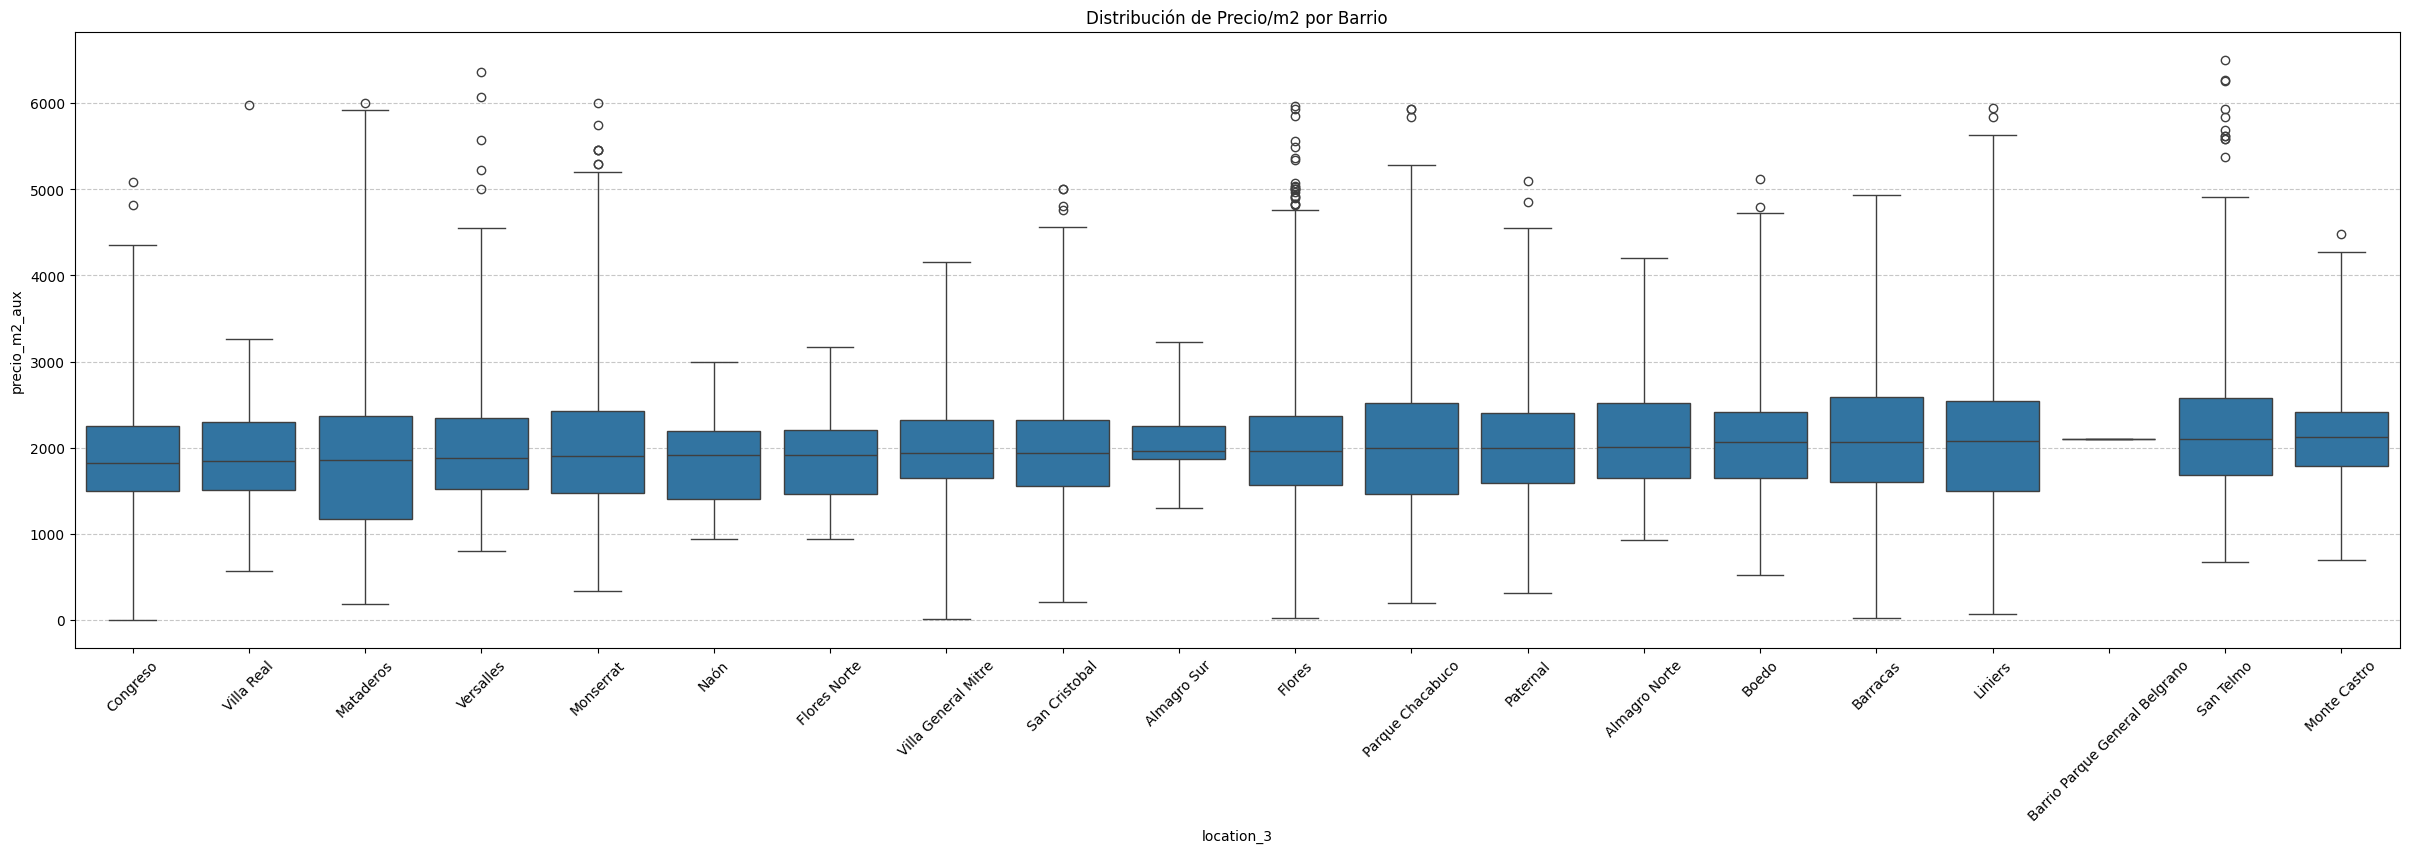

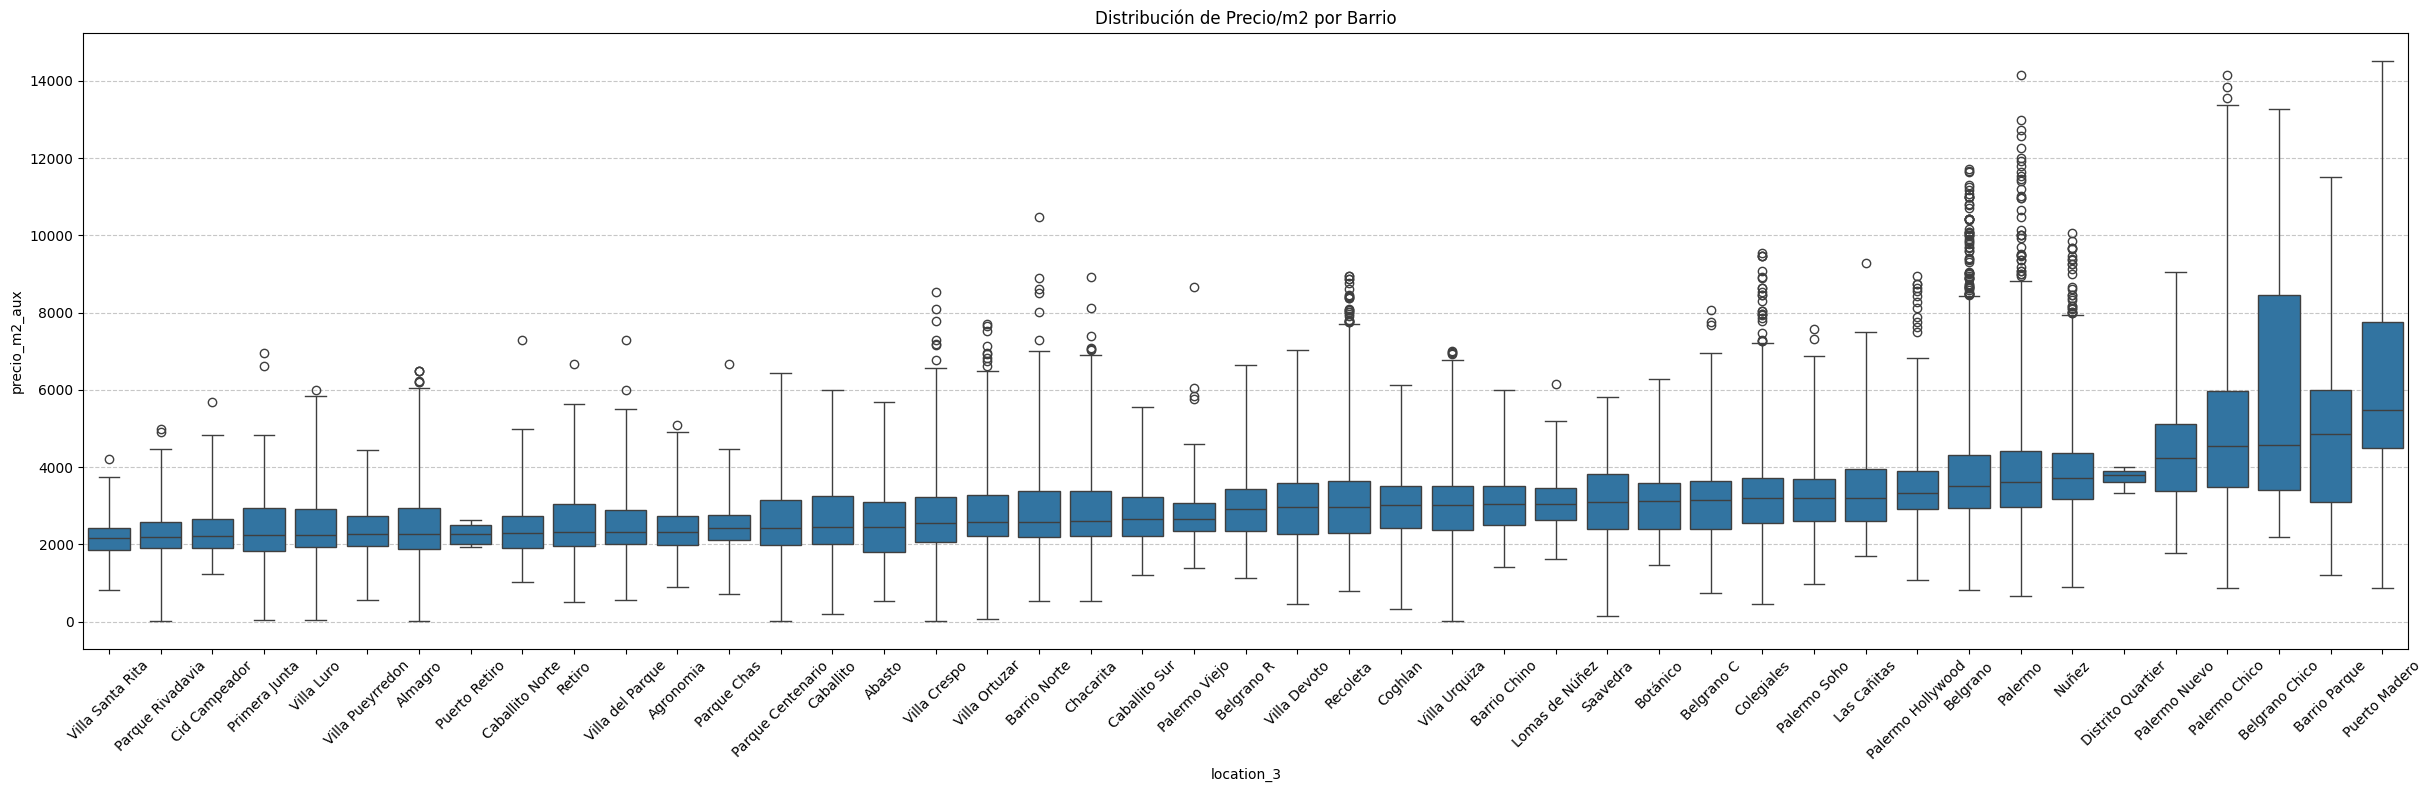

In [ ]:
# 1. Agrupamos y ordenamos los barrios por la mediana del precio auxiliar
precio_m2_barrios = df_ent.groupby('location_3')['precio_m2_aux'].agg(['median', 'count']).sort_values(by='median')

# 2. Dividimos los barrios en 3 grupos para que el gráfico no sea ilegible
barrios1 = precio_m2_barrios[0:20].index.values
barrios2 = precio_m2_barrios[20:40].index.values
barrios3 = precio_m2_barrios[40:].index.values

# 3. Iteramos para crear los gráficos
for grupo_barrios in [barrios1, barrios2, barrios3]:
    plt.figure(figsize=(30, 8)) # Un poco más de altura para que se vean bien los nombres

    # Filtramos el dataframe original solo con los barrios del grupo actual
    sns.boxplot(
        data=df_ent[df_ent['location_3'].isin(grupo_barrios)],
        x='location_3',
        y='precio_m2_aux',
        order=grupo_barrios, # Mantiene el orden de barato a caro
        whis=3
    )

    plt.xticks(rotation=45) # Rotamos los nombres para que no se superpongan
    plt.title("Distribución de Precio/m2 por Barrio")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

In [ ]:
df_ent['es_puertomadero'] = np.where(df_ent['location_3'] == 'Puerto Madero', 1, 0)
df_ap['es_puertomadero'] = np.where(df_ap['location_3'] == 'Puerto Madero', 1, 0)

In [ ]:
# 1. Definimos los grupos de barrios exactamente como los especificaste
barrios_lujo = [
    'Barrio Parque', 'Belgrano Chico', 'Palermo Chico', 'Palermo Nuevo'
]

barrios_alto = [
    'Distrito Quartier', 'Nuñez', 'Palermo', 'Belgrano', 'Palermo Hollywood',
    'Palermo Soho', 'Colegiales', 'Las Cañitas', 'Belgrano C', 'Botánico',
    'Caballito', 'Saavedra', 'Lomas de Núñez', 'Barrio Chino', 'Villa Urquiza',
    'Coghlan', 'Recoleta', 'Villa Devoto', 'Belgrano R', 'Palermo Viejo',
    'Caballito Sur', 'Chacarita', 'Barrio Norte'
]

barrios_medio = [
    'Villa Ortuzar', 'Villa Crespo', 'Abasto', 'Parque Centenario', 'Parque Chas',
    'Agronomia', 'Villa del Parque', 'Retiro', 'Caballito Norte', 'Puerto Retiro',
    'Almagro', 'Villa Luro', 'Villa Pueyrredon', 'Primera Junta', 'Cid Campeador',
    'Parque Rivadavia', 'Villa Santa Rita', 'Monte Castro', 'San Telmo', 'Liniers',
    'Barrio Parque General Belgrano', 'Barracas', 'Boedo', 'Almagro Norte',
    'Parque Chacabuco', 'Paternal', 'Flores', 'Almagro Sur', 'San Cristobal',
    'Villa General Mitre', 'Flores Norte', 'Naón', 'Monserrat', 'Versalles',
    'Mataderos', 'Congreso', 'Villa Real'
]

barrios_bajo = [
    'Tribunales', 'San Nicolás', 'Flores Sur', 'Velez Sarsfield', 'Floresta',
    'Balvanera', 'Floresta Sur', 'Parque Patricios', 'Catalinas', 'Villa Riachuelo',
    'Parque Avellaneda', 'Los Perales', 'Floresta Norte', 'Boca', 'Constitucion',
    'Villa Lugano', 'Pompeya', 'Centro', 'Villa Soldati', 'Ciudad Autónoma de Buenos Aires'
]

# 2. Creamos las variables booleanas/numéricas para cada tipo de barrio (1 si pertenece, 0 si no)
# Usamos .isin() que verifica si el valor de 'location_3' está en las listas de arriba
df_ent['barrio_lujo'] = df_ent['location_3'].isin(barrios_lujo).astype(int)
df_ent['barrio_alto'] = df_ent['location_3'].isin(barrios_alto).astype(int)
df_ent['barrio_medio'] = df_ent['location_3'].isin(barrios_medio).astype(int)
df_ent['barrio_bajo'] = df_ent['location_3'].isin(barrios_bajo).astype(int)

# 3. Creamos la variable jerárquica 'barrio_segmento'
# Usamos una función auxiliar para asignar el número según el barrio
def asignar_segmento(barrio):
    if barrio == 'Puerto Madero': # Agregado explícitamente por tu requerimiento
        return 1
    elif barrio in barrios_lujo:
        return 2  # Siguiendo la escala (Puerto Madero=1, Lujo=2, Alto=3...)
    elif barrio in barrios_alto:
        return 3
    elif barrio in barrios_medio:
        return 4
    elif barrio in barrios_bajo:
        return 5
    else:
        return None # Por si hay algún barrio que no entró en ninguna lista

# Aplicamos la función fila por fila en la columna 'location_3'
df_ent['barrio_segmento'] = df_ent['location_3'].apply(asignar_segmento)

In [ ]:
# 2. Creamos las variables booleanas/numéricas para cada tipo de barrio (1 si pertenece, 0 si no)
# Usamos .isin() que verifica si el valor de 'location_3' está en las listas de arriba
df_ap['barrio_lujo'] = df_ap['location_3'].isin(barrios_lujo).astype(int)
df_ap['barrio_alto'] = df_ap['location_3'].isin(barrios_alto).astype(int)
df_ap['barrio_medio'] = df_ap['location_3'].isin(barrios_medio).astype(int)
df_ap['barrio_bajo'] = df_ap['location_3'].isin(barrios_bajo).astype(int)

# 3. Creamos la variable jerárquica 'barrio_segmento'
# Usamos una función auxiliar para asignar el número según el barrio
def asignar_segmento(barrio):
    if barrio == 'Puerto Madero': # Agregado explícitamente por tu requerimiento
        return 1
    elif barrio in barrios_lujo:
        return 2  # Siguiendo la escala (Puerto Madero=1, Lujo=2, Alto=3...)
    elif barrio in barrios_alto:
        return 3
    elif barrio in barrios_medio:
        return 4
    elif barrio in barrios_bajo:
        return 5
    else:
        return None # Por si hay algún barrio que no entró en ninguna lista

# Aplicamos la función fila por fila en la columna 'location_3'
df_ap['barrio_segmento'] = df_ap['location_3'].apply(asignar_segmento)

In [ ]:
# 1. Lista de palabras clave (normalizadas a minúsculas)
torres_lujo = [
    "libertador 2300", "libretador 2400", "libertador 2400","quantum bellini", "torre deco", "torre decó","om botánico","om botanico","om recoleta",
    "premium deco", "torre deco armani recoleta", "deco polo", "baez 100", "deco armani","humboldt al 2000","infinity towers","link towers",
    "torre premium – recoleta", "piso en le parc figueroa alcorta, torre cavia", "le parc", "edificio chateau","quo zapata","link tower",
    "urban cramer", "torre life barrancas", "quartier bajo belgrano", "quartier","torres de gelly","torre lumiere","weik belgrano",
    "forum", "las torres de cristal", "torre ramsay", "la pampa al 1800", "dome beruti","zaha hadid", "leparc","demaria 4550",
    "torres ramsay 1945", "madero plaza", "chateau libertador", "juana manso 1500", "edificio velvet", "demaria al 4500","roccatagliata",
    "torre libertador", "l´avenue libertador 23 polo", "torre mirabilia", "torre boschetto", "complejo mirabilia","forum alcorta",
    "l´avenue libertador", "libertador 3800", "l´avenue", "torre quantum", "l avenue libertador", "torre quantum palermo", "torre costantini"
]

# 2. Creamos el patrón regex uniendo los términos con el operador OR (|)
# Usamos re.escape para evitar problemas con caracteres especiales como los guiones o acentos
import re
patron = "|".join([re.escape(busqueda) for busqueda in torres_lujo])

# 3. Aplicamos la lógica a tu DataFrame
# Pasamos description y address a minúsculas (.str.lower()) y buscamos el patrón
df_ent['es_torrelujo'] = (
    df_ent['description'].str.lower().str.contains(patron, na=False) |
    df_ent['address'].str.lower().str.contains(patron, na=False)
).astype(int) # .astype(int) transforma True/False en 1/0. Si prefieres booleanos, quita esa línea.

In [ ]:
# 3. Aplicamos la lógica a tu DataFrame
# Pasamos description y address a minúsculas (.str.lower()) y buscamos el patrón
df_ap['es_torrelujo'] = (
    df_ap['description'].str.lower().str.contains(patron, na=False) |
    df_ap['address'].str.lower().str.contains(patron, na=False)
).astype(int) # .astype(int) transforma True/False en 1/0. Si prefieres booleanos, quita esa línea.

In [ ]:
"""
barrio_a_comuna_completo = {
    # Comuna 1
    "Retiro": 1, "Puerto Retiro": 1, "San Nicolás": 1, "Centro": 1, "Tribunales": 1,
    "Puerto Madero": 1, "San Telmo": 1, "Monserrat": 1, "Constitución": 1,
    "Constitucion": 1, "Catalinas": 1, "Distrito Quartier": 1,

    # Comuna 2
    "Recoleta": 2, "Barrio Norte": 2,

    # Comuna 3
    "Balvanera": 3, "San Cristóbal": 3, "San Cristobal": 3, "Abasto": 3, "Congreso": 3,

    # Comuna 4
    "La Boca": 4, "Boca": 4, "Barracas": 4, "Parque Patricios": 4, "Nueva Pompeya": 4, "Pompeya": 4,

    # Comuna 5
    "Almagro": 5, "Almagro Norte": 5, "Almagro Sur": 5, "Boedo": 5,

    # Comuna 6
    "Caballito": 6, "Caballito Norte": 6, "Caballito Sur": 6, "Parque Rivadavia": 6,
    "Cid Campeador": 6, "Primera Junta": 6,

    # Comuna 7
    "Flores": 7, "Flores Norte": 7, "Flores Sur": 7, "Parque Chacabuco": 7,

    # Comuna 8
    "Villa Soldati": 8, "Villa Riachuelo": 8, "Villa Lugano": 8,

    # Comuna 9
    "Liniers": 9, "Mataderos": 9, "Parque Avellaneda": 9, "Naón": 9, "Los Perales": 9,

    # Comuna 10
    "Villa Real": 10, "Monte Castro": 10, "Versalles": 10, "Floresta": 10,
    "Floresta Norte": 10, "Floresta Sur": 10, "Vélez Sarsfield": 10, "Velez Sarsfield": 10,
    "Villa Luro": 10,

    # Comuna 11
    "Villa General Mitre": 11, "Villa Devoto": 11, "Villa del Parque": 11, "Villa Santa Rita": 11,

    # Comuna 12
    "Coghlan": 12, "Saavedra": 12, "Villa Urquiza": 12, "Villa Pueyrredón": 12, "Villa Pueyrredon": 12,

    # Comuna 13
    "Belgrano": 13, "Belgrano R": 13, "Belgrano C": 13, "Belgrano Chico": 13,
    "Barrio Chino": 13, "Nuñez": 13, "Núñez": 13, "Lomas de Núñez": 13, "Colegiales": 13,
    "Barrio Parque General Belgrano": 13,

    # Comuna 14
    "Palermo": 14, "Palermo Hollywood": 14, "Palermo Soho": 14, "Botánico": 14,
    "Palermo Chico": 14, "Las Cañitas": 14, "Palermo Viejo": 14, "Barrio Parque": 14, "Palermo Nuevo": 14,

    # Comuna 15
    "Chacarita": 15, "Villa Crespo": 15, "La Paternal": 15, "Paternal": 15,
    "Villa Ortúzar": 15, "Villa Ortuzar": 15, "Agronomía": 15, "Agronomia": 15,
    "Parque Chas": 15, "Parque Centenario": 15
}

def asignar_comunas_num(df):
    # Limpieza de espacios
    df["location_3"] = df["location_3"].str.strip()

    # Mapeo directo a entero aceptando nulos (Int64)
    df["comuna"] = df["location_3"].map(barrio_a_comuna_completo).astype("Int64")

    return df

df_ent = asignar_comunas_num(df_ent)
df_ap = asignar_comunas_num(df_ap)


In [ ]:

# Formato: "Nombre_Barrio": (ID_Barrio, Comuna)
barrio_info_completa = {
    # Comuna 1
    "Retiro": (1, 1), "Puerto Retiro": (2, 1), "San Nicolás": (3, 1), "Centro": (4, 1), "Tribunales": (5, 1),
    "Puerto Madero": (6, 1), "San Telmo": (7, 1), "Monserrat": (8, 1), "Constitución": (9, 1),
    "Constitucion": (9, 1), "Catalinas": (10, 1), "Distrito Quartier": (11, 1),

    # Comuna 2
    "Recoleta": (12, 2), "Barrio Norte": (13, 2),

    # Comuna 3
    "Balvanera": (14, 3), "San Cristóbal": (15, 3), "San Cristobal": (15, 3), "Abasto": (16, 3), "Congreso": (17, 3),

    # Comuna 4
    "La Boca": (18, 4), "Boca": (18, 4), "Barracas": (19, 4), "Parque Patricios": (20, 4), "Nueva Pompeya": (21, 4), "Pompeya": (21, 4),

    # Comuna 5
    "Almagro": (22, 5), "Almagro Norte": (23, 5), "Almagro Sur": (24, 5), "Boedo": (25, 5),

    # Comuna 6
    "Caballito": (26, 6), "Caballito Norte": (27, 6), "Caballito Sur": (28, 6), "Parque Rivadavia": (29, 6),
    "Cid Campeador": (30, 6), "Primera Junta": (31, 6),

    # Comuna 7
    "Flores": (32, 7), "Flores Norte": (33, 7), "Flores Sur": (34, 7), "Parque Chacabuco": (35, 7),

    # Comuna 8
    "Villa Soldati": (36, 8), "Villa Riachuelo": (37, 8), "Villa Lugano": (38, 8),

    # Comuna 9
    "Liniers": (39, 9), "Mataderos": (40, 9), "Parque Avellaneda": (41, 9), "Naón": (42, 9), "Los Perales": (43, 9),

    # Comuna 10
    "Villa Real": (44, 10), "Monte Castro": (45, 10), "Versalles": (46, 10), "Floresta": (47, 10),
    "Floresta Norte": (48, 10), "Floresta Sur": (49, 10), "Vélez Sarsfield": (50, 10), "Velez Sarsfield": (50, 10),
    "Villa Luro": (51, 10),

    # Comuna 11
    "Villa General Mitre": (52, 11), "Villa Devoto": (53, 11), "Villa del Parque": (54, 11), "Villa Santa Rita": (55, 11),

    # Comuna 12
    "Coghlan": (56, 12), "Saavedra": (57, 12), "Villa Urquiza": (58, 12), "Villa Pueyrredón": (59, 12), "Villa Pueyrredon": (59, 12),

    # Comuna 13
    "Belgrano": (60, 13), "Belgrano R": (61, 13), "Belgrano C": (62, 13), "Belgrano Chico": (63, 13),
    "Barrio Chino": (64, 13), "Nuñez": (65, 13), "Núñez": (65, 13), "Lomas de Núñez": (66, 13), "Colegiales": (67, 13),
    "Barrio Parque General Belgrano": (68, 13),

    # Comuna 14
    "Palermo": (69, 14), "Palermo Hollywood": (70, 14), "Palermo Soho": (71, 14), "Botánico": (72, 14),
    "Palermo Chico": (73, 14), "Las Cañitas": (74, 14), "Palermo Viejo": (75, 14), "Barrio Parque": (76, 14), "Palermo Nuevo": (77, 14),

    # Comuna 15
    "Chacarita": (78, 15), "Villa Crespo": (79, 15), "La Paternal": (80, 15), "Paternal": (80, 15),
    "Villa Ortúzar": (81, 15), "Villa Ortuzar": (81, 15), "Agronomía": (82, 15), "Agronomia": (82, 15),
    "Parque Chas": (83, 15), "Parque Centenario": (84, 15)
}
def asignar_barrios_y_comunas(df):
    # 1. Limpieza de espacios
    df["location_3"] = df["location_3"].str.strip()

    # 2. Mapeo temporal que devuelve la tupla (id_barrio, comuna)
    mapeo_temporal = df["location_3"].map(barrio_info_completa)

    # 3. Separar las tuplas en dos columnas nuevas (manejando nulos correctamente)
    df["id_barrio"] = mapeo_temporal.str[0].astype("Int64")
    df["comuna"] = mapeo_temporal.str[1].astype("Int64")

    return df

# Aplicar a tus DataFrames
df_ent = asignar_barrios_y_comunas(df_ent)
df_ap = asignar_barrios_y_comunas(df_ap)

In [ ]:
# Diccionario de precios promedio por m² (en USD) para CABA - 2026
# Incluye sub-barrios asociados a su precio de zona correspondiente
precio_m2_barrios = {
    # Valores Premium / Corredor Norte
    "Puerto Madero": 4681, "Distrito Quartier": 4681,
    "Palermo": 2631, "Palermo Hollywood": 2631, "Palermo Soho": 2631,
    "Palermo Chico": 3212, "Palermo Viejo": 2631, "Palermo Nuevo": 2631,
    "Botánico": 2631, "Las Cañitas": 2631, "Barrio Parque": 3212,
    "Nuñez": 2569, "Núñez": 2569, "Lomas de Núñez": 2569,
    "Belgrano": 2526, "Belgrano R": 2526, "Belgrano C": 2526, "Belgrano Chico": 2526, "Barrio Chino": 2526, "Barrio Parque General Belgrano": 2526,
    "Recoleta": 2459, "Barrio Norte": 2664,
    "Colegiales": 2334,
    "Villa Urquiza": 2212,

    # Valores Medios Altos
    "Villa Devoto": 2151,
    "Chacarita": 2136,
    "Villa Crespo": 2085,
    "Saavedra": 1991,
    "Parque Chas": 1965,
    "Coghlan": 1956,
    "Caballito": 1952, "Caballito Norte": 1952, "Caballito Sur": 1952, "Parque Rivadavia": 1952, "Cid Campeador": 1952, "Primera Junta": 1952,
    "Villa Ortúzar": 1941, "Villa Ortuzar": 1941,
    "Retiro": 1882, "Puerto Retiro": 1882,
    "San Telmo": 1831,
    "Almagro": 1818, "Almagro Norte": 1818, "Almagro Sur": 1818,
    "San Nicolás": 1785, "Centro": 1785, "Tribunales": 1785, "Catalinas": 1785,

    # Valores Medios
    "Parque Chacabuco": 1758,
    "Villa Pueyrredón": 1711, "Villa Pueyrredon": 1711,
    "Boedo": 1695,
    "Flores": 1652, "Flores Norte": 1652, "Flores Sur": 1652,
    "Villa Santa Rita": 1637,
    "Agronomía": 1540, "Agronomia": 1540,
    "Monserrat": 1540, "Montserrat": 1540,
    "Villa Luro": 1541,
    "San Cristóbal": 1513, "San Cristobal": 1513,
    "Barracas": 1488,
    "Balvanera": 1449, "Abasto": 1449, "Congreso": 1449,

    # Valores Económicos / Cordón Oeste y Sur
    "Monte Castro": 1438,
    "Villa Real": 1382,
    "Floresta": 1365, "Floresta Norte": 1365, "Floresta Sur": 1365,
    "Liniers": 1326,
    "La Paternal": 1312, "Paternal": 1312, "Parque Centenario": 1312,
    "Versalles": 1288,
    "Mataderos": 1190, "Los Perales": 1190, "Naón": 1190,
    "Constitución": 1152, "Constitucion": 1152,
    "Parque Patricios": 1151,
    "Parque Avellaneda": 1104,

    # Valores más accesibles
    "La Boca": 905, "Boca": 905,
    "Villa Lugano": 880,
    "Villa Riachuelo": 878,
    "Nueva Pompeya": 870, "Pompeya": 870,
    "Villa Soldati": 681
}

def agregar_precio_m2(df):
    # Aseguramos que no haya espacios molestos al principio o final
    df["location_3"] = df["location_3"].str.strip()

    # Mapeamos creando la nueva columna 'precio_m2_usd'
    df["precio_m2_usd"] = df["location_3"].map(precio_m2_barrios)

    # Forzamos que sea de tipo Float para cálculos posteriores
    df["precio_m2_usd"] = df["precio_m2_usd"].astype("float64")

    return df

# --- Ejemplo de aplicación ---
df_ent = agregar_precio_m2(df_ent)
df_ap = agregar_precio_m2(df_ap)

In [ ]:
# =========================================================================
# NUEVA VARIABLE: Identificamos y guardamos los precios SIN extremos
# =========================================================================
# Calculamos los límites de cuantiles por cada barrio
limite_inf_b = df_ent.groupby("location_3")["precio_m2_aux"].transform(lambda x: x.quantile(0.05))
limite_sup_b = df_ent.groupby("location_3")["precio_m2_aux"].transform(lambda x: x.quantile(0.95))

# Creamos una SERIE temporal (no toca el DataFrame) filtrando los extremos
precio_m2_sin_extremos = df_ent["precio_m2_aux"].where(
    (df_ent["precio_m2_aux"] >= limite_inf_b) & (df_ent["precio_m2_aux"] <= limite_sup_b)
)

# Creamos los mapas de medias truncadas usando la serie aislada
zona_map_media = precio_m2_sin_extremos.groupby(df_ent["location_3"]).mean()
zona_tipo_map_media = precio_m2_sin_extremos.groupby([df_ent["location_3"], df_ent["property_type"]]).mean()

# Asignación a las NUEVAS columnas para Barrio simple (Funciona perfecto con .map)
df_ent["precio_m2_barrio_limpio"] = df_ent["location_3"].map(zona_map_media).fillna(mediana_precio_m2_aux)
df_ap["precio_m2_barrio_limpio"] = df_ap["location_3"].map(zona_map_media).fillna(mediana_precio_m2_aux)

# === CORRECCIÓN AQUÍ ===
# Para mapear un MultiIndex, creamos una tupla con las columnas correspondientes en zip()
# o pasamos una lista de columnas directamente a .map() si usas versiones modernas de pandas.
# La forma universal y más segura:

df_ent["precio_m2_barrio_tipo_limpio"] = df_ent.set_index(["location_3", "property_type"]).index.map(zona_tipo_map_media)
df_ap["precio_m2_barrio_tipo_limpio"] = df_ap.set_index(["location_3", "property_type"]).index.map(zona_tipo_map_media)

# Rellenar los valores nulos (Esto se mantiene igual)
df_ent["precio_m2_barrio_tipo_limpio"] = df_ent["precio_m2_barrio_tipo_limpio"].fillna(mediana_precio_m2_aux)
df_ap["precio_m2_barrio_tipo_limpio"] = df_ap["precio_m2_barrio_tipo_limpio"].fillna(mediana_precio_m2_aux)

In [ ]:
df_ent[df_ent["location_3"].isna()]

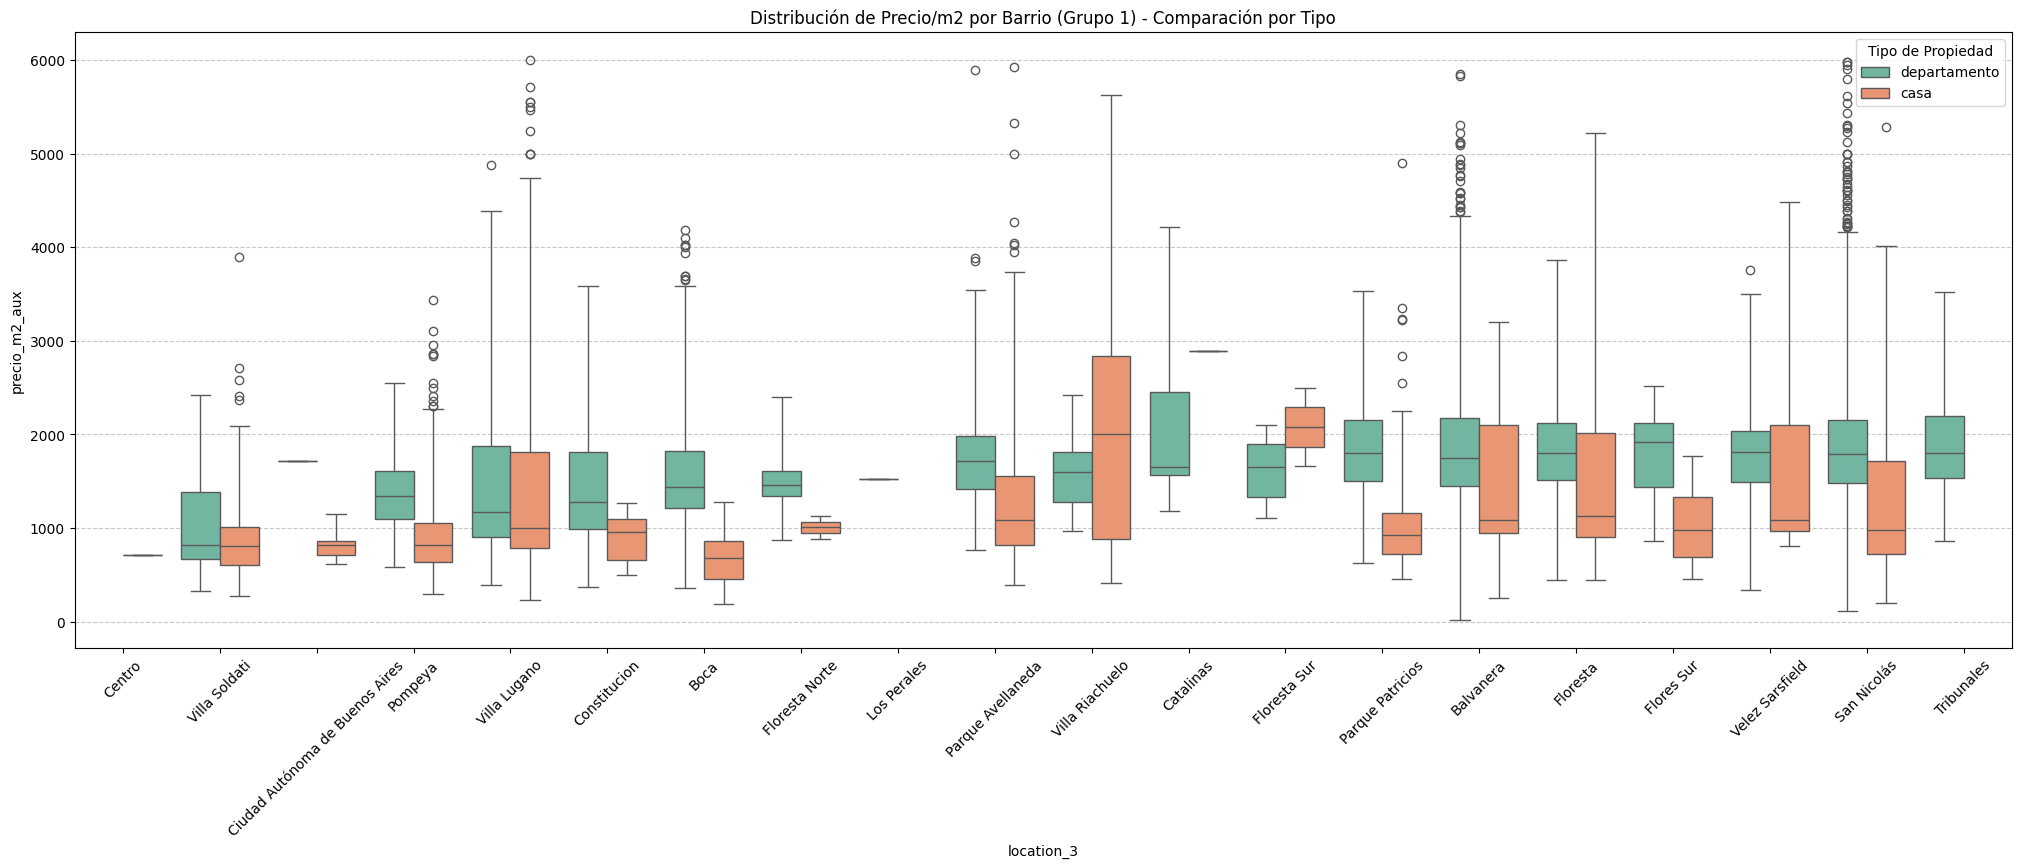

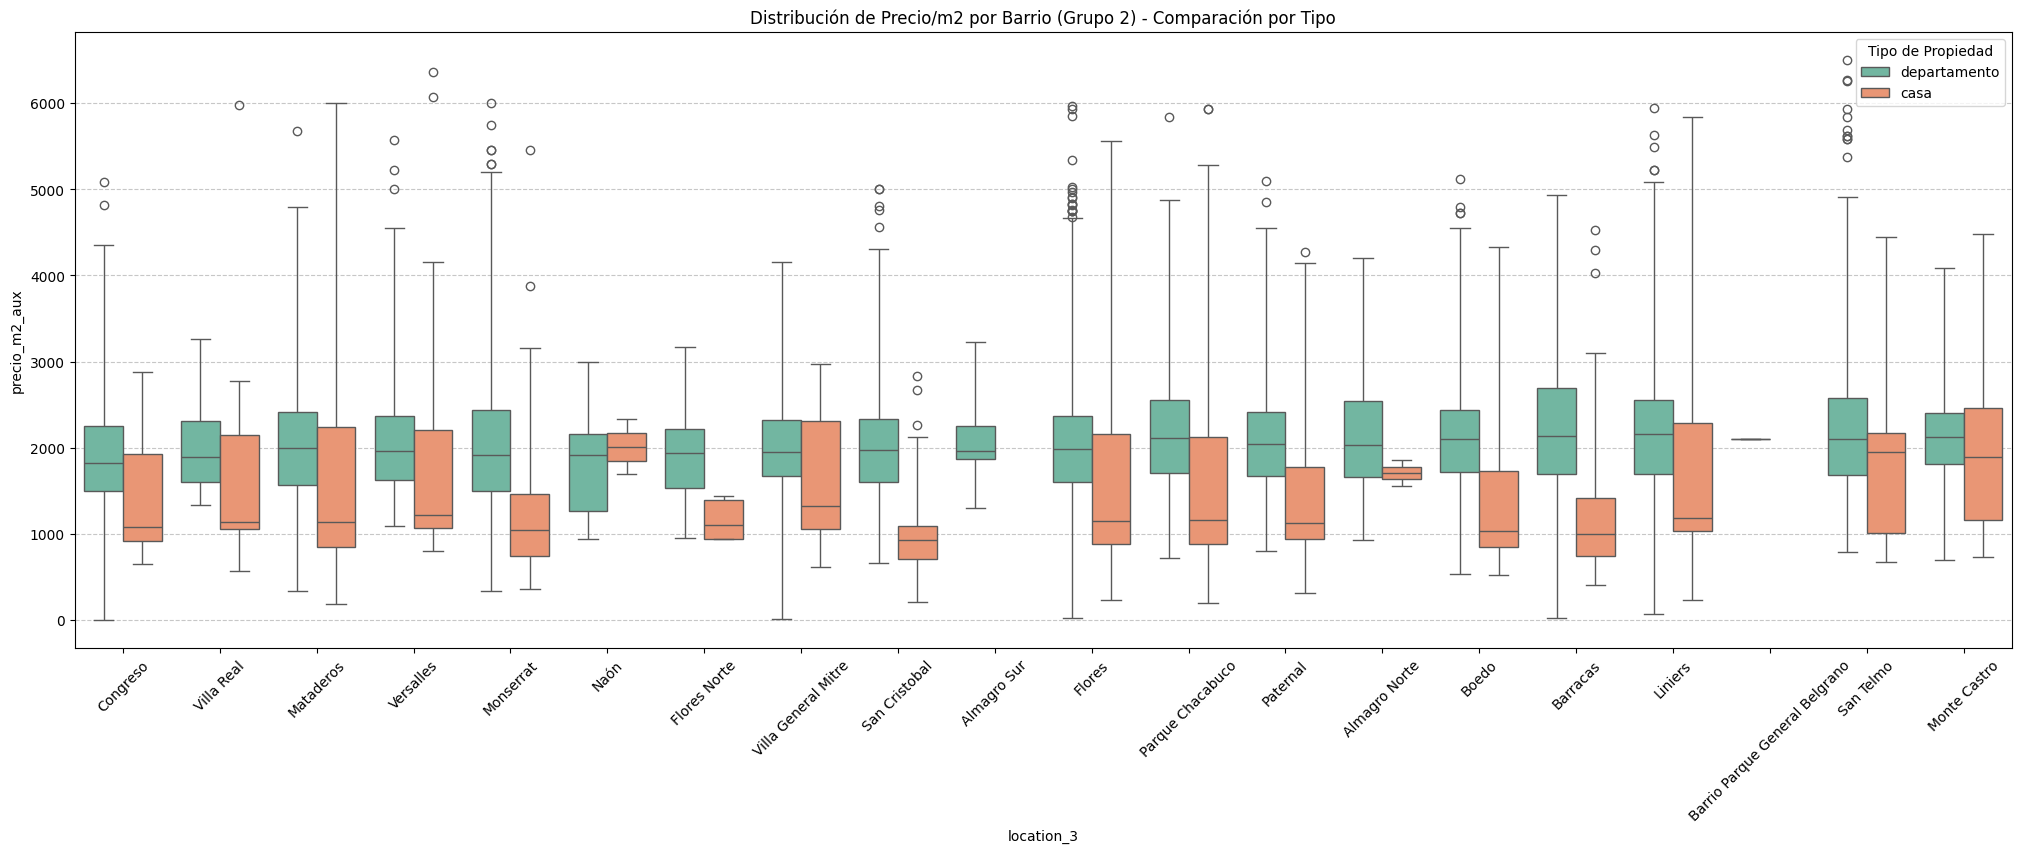

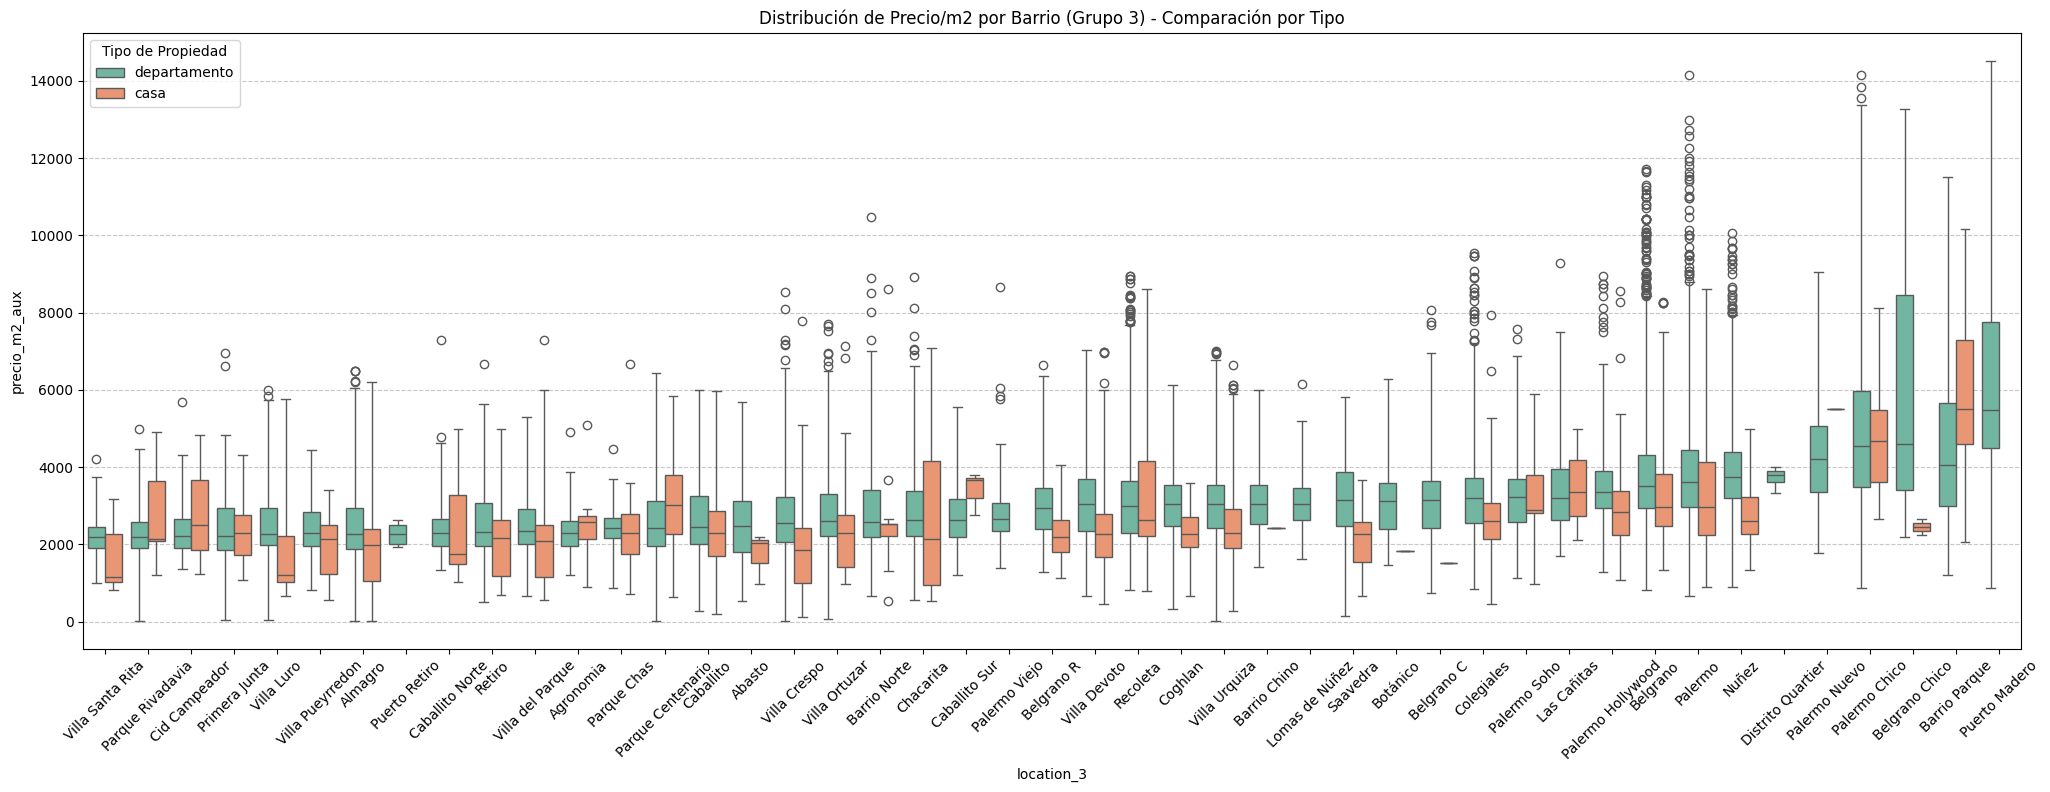

In [ ]:
# 1. Agrupamos y ordenamos los barrios por la mediana del precio auxiliar
#precio_m2_barrios = df_ent.groupby('location_3')['precio_m2_aux'].median().sort_values()
precio_m2_barrios = df_ent.groupby('location_3')['precio_m2_aux'].agg(['median', 'count']).sort_values(by='median')

# 2. Definimos los grupos de barrios (ajusta los cortes si necesitas más/menos grupos)
# Usamos .index.values para obtener la lista de nombres de barrios ordenada
grupos = [
    precio_m2_barrios.index[0:20],
    precio_m2_barrios.index[20:40],
    precio_m2_barrios.index[40:]
]

# 3. Iteramos para crear los gráficos comparativos
for i, grupo_barrios in enumerate(grupos):
    plt.figure(figsize=(25, 8))

    # Filtramos el dataframe
    df_filtrado = df_ent[df_ent['location_3'].isin(grupo_barrios)]

    # Creamos el boxplot con el hue para la comparación
    sns.boxplot(
        data=df_filtrado,
        x='location_3',
        y='precio_m2_aux',
        hue='property_type',
        order=grupo_barrios, # Mantiene el orden de la mediana global
        palette='Set2',
        whis=3
    )

    plt.xticks(rotation=45)
    plt.title(f"Distribución de Precio/m2 por Barrio (Grupo {i+1}) - Comparación por Tipo")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend(title='Tipo de Propiedad')
    plt.show()

In [ ]:
# Guardamos el resultado en un nuevo DataFrame
df_filtrado = df_ent[(df_ent['location_3'] == 'Distrito Quartier') & (df_ent['es_casa'] == 1)]
df_filtrado[["description","address","lat","lon","location_3","features","m2","es_casa"]]

,description,address,lat,lon,location_3,features,m2,es_casa
id,,,,,,,,


In [ ]:
# Elegimos una muestra de barrios (los 10 más caros o una zona específica)
top_barrios = precio_m2_barrios.tail(10).index

plt.figure(figsize=(15, 7))
sns.boxplot(
    data=df_ent[df_ent['location_3'].isin(top_barrios)],
    x='location_3',
    y='precio_m2_aux',
    hue='property_type', # LA CLAVE: separa casa de depto
    palette='Set2'
)
plt.title("Comparación Depto vs Casa por Barrio (Top 10 Caros)")
plt.xticks(rotation=45)
plt.show()

In [ ]:
#df_ent[df_ent["es_terreno"]==1][["description","address","lat","lon","features","location_3","price","m2","banos","dormitorios"]].head(10)

In [ ]:
# 1167441
df_ent.loc[[708253]][["lat","lon","description","features","address","location_3","m2","banos","dormitorios","price","source"]]

In [ ]:
df_ent = df_ent.drop(columns=["precio_m2_aux"], errors="ignore")
df_ap = df_ap.drop(columns=["precio_m2_aux"], errors="ignore")

In [ ]:
# Limito los valores extremos de las variables numéricas (outliers) en ambos conjuntos de datos utilizando los percentiles 1 y 99 del set de entrenamiento
#def clip_from_train(train_s, target_s, q1=0.01, q2=0.99):
#    lo = train_s.quantile(q1)
#    hi = train_s.quantile(q2)
#    return target_s.clip(lo, hi)

#for c in ["lat", "lon", "price", "m2", "dormitorios", "banos", "precio_m2_barrio","precio_m2_barrio_tipo"]:
#    df_ent[c] = clip_from_train(df_ent[c], df_ent[c])
#    if c != "price":
#        df_ap[c] = clip_from_train(df_ent[c], df_ap[c])

In [ ]:
# FECHA

In [ ]:
df_ent["publication_date"].head()

## 2.2. Tratamiento de valores atípicos

In [ ]:
#df_ent = df_ent.loc[(df_ent["price"] <15000000)]

In [ ]:
#df_ent = df_ent.loc[(df_ent["price"] >15000)]

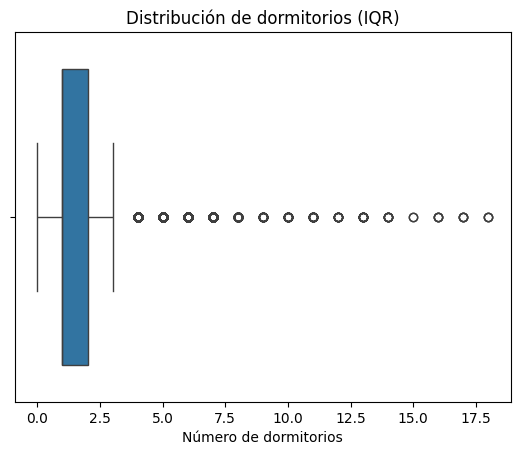

In [ ]:
# Crear el gráfico de caja
sns.boxplot(x=df_ent["dormitorios"])
# Personalización básica
plt.title("Distribución de dormitorios (IQR)")
plt.xlabel("Número de dormitorios")
plt.show()

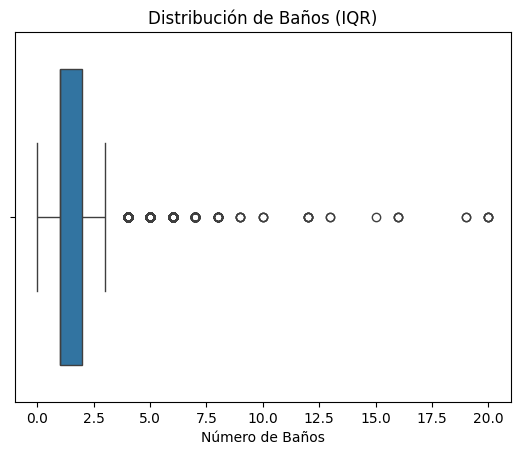

In [ ]:
# Crear el gráfico de caja
sns.boxplot(x=df_ent["banos"])
# Personalización básica
plt.title("Distribución de Baños (IQR)")
plt.xlabel("Número de Baños")
plt.show()

## 2.3. Imputación de valores perdidos

In [ ]:
#sns.heatmap(df_ent.isnull(),yticklabels=False,cbar=False,cmap='viridis')

In [ ]:
#df_ent[df_ent["source"].isna()]

In [ ]:
# La creación de modelos requiere que no haya valores perdidos por eso llenamos todo con 0 a lo bestia
# TODO: Mejorar la estrategia de imputación.
#df_ent = df_ent.fillna(0)
#df_ent = df_ent.fillna(df_ent.mean())

## 2.4. Creación de nuevos atributos

In [ ]:
# Generación de nuevas columnas
# TODO: Crear nuevas variables a partir de datos YA EXISTENTES en el dataset (No usar ningún tipo de fuente externa)
# Tampoco usar librerias ajenas a las que se están viendo en la asignatura.

#df_ent["feng-shui"] = 1

In [ ]:
df_ent['m2_log'] = np.log(df_ent['m2'])
df_ap['m2_log'] = np.log(df_ap['m2'])

In [ ]:
# Sobrescribe la columna 'price' con su logaritmo natural
df_ent['price'] = np.log(df_ent['price'])

In [ ]:
numeric_cols = df_ent.select_dtypes('number').columns.tolist()
train_medians = {}
for col in numeric_cols:
    if col != 'price':
        median_val = df_ent[col].median()
        train_medians[col] = median_val
        df_ent[col] = df_ent[col].fillna(median_val)

print('Imputación con mediana aplicada a', len(train_medians), 'columnas numéricas de df_ent')

Imputación con mediana aplicada a 66 columnas numéricas de df_ent


In [ ]:
numeric_cols = df_ap.select_dtypes('number').columns.tolist()
train_medians = {}
for col in numeric_cols:
    if col != 'price':
        median_val = df_ap[col].median()
        train_medians[col] = median_val
        df_ap[col] = df_ap[col].fillna(median_val)

print('Imputación con mediana aplicada a', len(train_medians), 'columnas numéricas de df_ap')

Imputación con mediana aplicada a 67 columnas numéricas de df_ap


In [ ]:
#df_ent.columns

In [ ]:
#df_ap.columns

In [ ]:
# Eliminamos publisher_id: es un ID sin relación directa con el precio
# y puede causar overfitting (el modelo aprende IDs en vez de patrones)
cols_to_drop = [c for c in ['publisher_id',"publication_date"] if c in df_ent.columns]
df_ent = df_ent.drop(columns=cols_to_drop)
df_ap = df_ap.drop(columns=cols_to_drop)

In [ ]:
cols_to_drop = [c for c in ["es_montacargas","es_nordelta","tiene_humedad"] if c in df_ent.columns]
df_ent = df_ent.drop(columns=cols_to_drop)
df_ap = df_ap.drop(columns=cols_to_drop)

In [ ]:
#cols_to_drop = [c for c in ["tiene_triplex","tiene_cowork","es_lote","tiene_amueblado","tiene_reciclado","tiene_sauna_solarium","tiene_parrilla","tiene_tren","tiene_cuarto_servicio","es_deposito","tiene_jacuzzi","tiene_jardin","tiene_duplex","tiene_pozo"] if c in df_ent.columns]
#df_ent = df_ent.drop(columns=cols_to_drop)
#df_ap = df_ap.drop(columns=cols_to_drop)

In [ ]:
#cols_to_drop = [c for c in ['location_2_freq',"tiene_cancha_padel","es_montacargas_","es_terreno","tiene_humedad","tiene_pozo","es_nordelta","es_deposito","tiene_cancha_tenis","property_type_freq","tiene_gran_estado","tiene_reciclado","tiene_cuarto_servicio","tiene_leparc","es_camion","es_montacargas","es_lote","tiene_ph","tiene_triplex","tiene_cowork","tiene_quincho","tiene_iluminado"] if c in df_ent.columns]
#df_ent = df_ent.drop(columns=cols_to_drop)
#df_ap = df_ap.drop(columns=cols_to_drop)

## 3. Entrenamiento del modelos (AA)- ⛔⛔⛔ NO TOCAR NADA DE ESTA SECCIÓN ⛔⛔⛔

In [ ]:
# La creación de modelos requiere que todo el dataframe sea numérico
# Me quedo con las columnas numéricas solamente
df_ent = df_ent.select_dtypes('number')

X = df_ent[df_ent.columns.drop('price')]
y = df_ent['price']

In [ ]:
# 1. Filtramos X e y usando los datos no nulos del target 'y'
completos = y.notna()
X_limpio = X[completos]
y_limpio = y[completos]

# --- EL CAMBIO ESTÁ ACÁ: Usamos X_limpio e y_limpio ---
X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(X_limpio, y_limpio, test_size=0.2, random_state=42)
#X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(X, y, test_size=0.2, random_state=42)


# Definimos el valor de los hiperparámetros a usar por el modelo
n_estimators = 500
max_depth = 50

# Creamos el modelo a entrenar
reg = sk.ensemble.RandomForestRegressor(n_estimators=n_estimators, max_depth=max_depth, n_jobs=-1, random_state=42)

# Entrenamos el modelo
_ = reg.fit(X_train, y_train)

# Cálculo del error en entrenamiento (train)
y_pred = reg.predict(X_train)
score_train = sk.metrics.root_mean_squared_error(y_train, y_pred)

# Cálculo del error en prueba (test)
y_pred = reg.predict(X_test)
score_test  = sk.metrics.root_mean_squared_error(y_test,  y_pred)

print(f"{n_estimators=} -- {max_depth=} --> {score_train=:.2f} - {score_test=:.2f}")

n_estimators=500 -- max_depth=50 --> score_train=0.08 - score_test=0.21


In [ ]:
### Versión con validación cruzada
best_score = 10**6

### Pueden cambiar los hiperparámetros pero no el modelo
#for n_estimators in [3,5, 50, 100, 300, 500, 1000]:
for n_estimators in [300, 500,700, 1000,1500]:
    #for max_depth in [3,5, 10, 20, 30, 50, None]:
    for max_depth in [10, 20, 30, 50, 100, None]:
        reg = sk.ensemble.RandomForestRegressor(n_estimators=n_estimators, max_depth=max_depth, n_jobs=-1, random_state=42)

        # Entrenamos el modelo (cross validation en 5 partes)
        scores = -1*sk.model_selection.cross_val_score(reg, X, y, cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1)

        scores_mean = scores.mean()
        scores_std = scores.std()

        best_score = min(best_score, scores_mean)

        print(f"{n_estimators=} -- {max_depth=} --> {scores_mean=:.2f} - {scores_std=:.2f} - {best_score=:.2f}")

n_estimators=300 -- max_depth=10 --> scores_mean=89994.45 - scores_std=11998.39 - best_score=89994.45


In [ ]:
"""
# Versión con GridSearchCV
param_grid = {
    'n_estimators': [3,5,100,500],
    'max_depth': [3,4,50,100],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'bootstrap': [True, False]
}

reg = sk.ensemble.RandomForestRegressor(random_state=42)

grid_search = sk.model_selection.GridSearchCV(reg, param_grid=param_grid, scoring="neg_root_mean_squared_error", cv=5, n_jobs=-1)
grid_search.fit(X, y)

print("Best Parameters:", grid_search.best_params_)
print("Best Estimator:", grid_search.best_estimator_)
"""

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


## 3.1. (Opcional) Validación Cruzada para mejorar el modelo a partir de los datos

Esta técnica permite mejorar el modelo adaptando los hiperparámetros a los datos seleccionados

**NOTA**: Esta técnica puede tardar mucho, se recomienda ir probando pocos valores en paralelo al resto de los analisis.

In [ ]:
# definimos el valor de los hiperparámetros
n_estimators = 500
max_depth = 50

# Creamos el modelo
# No cambiar RandomForestRegressor
reg = sk.ensemble.RandomForestRegressor(n_estimators=n_estimators, max_depth=max_depth, n_jobs=-1, random_state=42)

scores_train = []
scores_test = []

# Validación cruzada, 10 folds, shuffle antes, semilla aleatoria
kf = sk.model_selection.KFold(n_splits=10, shuffle=True, random_state=42)

for fold, (train_index, test_index) in enumerate(kf.split(X, y)):
    # Partimos el fold en entrenamiento y prueba...
    X_train, X_test, y_train, y_test = X.iloc[train_index], X.iloc[test_index], y.iloc[train_index], y.iloc[test_index]

    # Entrenamos el modelo en entramiento
    reg.fit(X_train, y_train)

    # Predecimos en train
    y_pred = reg.predict(X_train)

    # Medimos la performance de la predicción en entramiento
    score_train = sk.metrics.root_mean_squared_error(y_train, y_pred)

    # Predecimos en test
    y_pred = reg.predict(X_test)

    # Medimos la performance de la predicción en prueba
    score_test = sk.metrics.root_mean_squared_error(y_test, y_pred)

    print("\t", f"{fold=}, {score_train=} {score_test=}")


	 fold=0, score_train=31400.708948795218 score_test=79814.67860167305
	 fold=1, score_train=31248.174950845478 score_test=79799.8329453747
	 fold=2, score_train=31239.337008300245 score_test=82697.67524742613


## 3.2. Análisis de la importancia de variables en el modelo (opcional)

Una manera visual de entender a que variable el modelo le está prestando mayor atención.

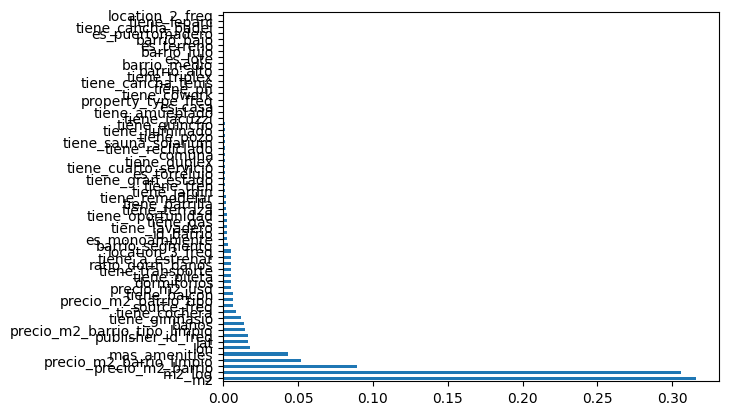

In [ ]:
feat_importances = pd.Series(reg.feature_importances_, index=X.columns)

# gráfico de barras horizontales
feat_importances.nlargest(64).plot(kind='barh');

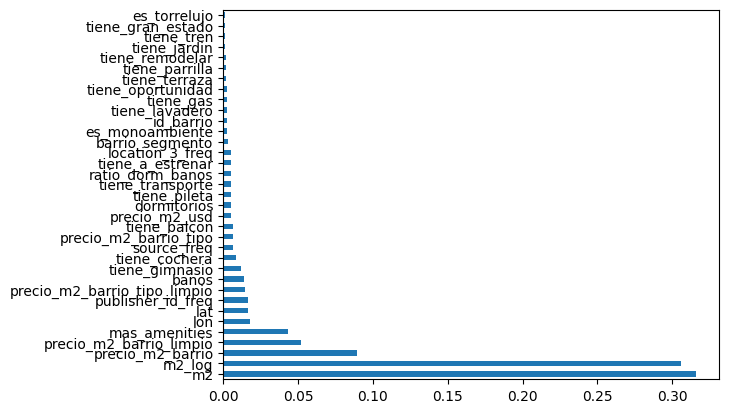

In [ ]:
feat_importances.nlargest(35).plot(kind='barh');

## 4. Solución para subir Kaggle

In [ ]:
#df_ap = pd.read_csv(f"{DIR}/a_predecir.csv", index_col="id")
#df_ap.head(2)

In [ ]:
df_ent.shape

(108082, 65)

In [ ]:
df_ap.shape

(13471, 78)

In [ ]:
#X = df_ent[df_ent.columns.drop('price')]
#y = df_ent['price']

# Si se hizo la validación cruzada usa el mejor valor encontrado, sino, ponemos valores por defecto
#best_n_estimators = mejor_combinacion["n_estimators"] if mejor_combinacion["n_estimators"] is not None else 50
#best_max_depth = mejor_combinacion["max_depth"] if mejor_combinacion["max_depth"] is not None else 5

#reg = sk.ensemble.RandomForestRegressor(n_estimators=best_n_estimators, max_depth=best_max_depth, n_jobs=-1, random_state=42)

# Entrenamos el modelo con todos los datos de entrenamiento.csv
#reg.fit(X, y)

## 4.2. Generación del archivo para Kaggle

In [ ]:
# TODO: Hacer en df_ap la misma limpieza que en df_ent
df_ap = df_ap.fillna(0)

df_ap = df_ap.select_dtypes('number')

X_ap = df_ap[X.columns]

/tmp/ipykernel_145/3109092418.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_ap = df_ap.fillna(0)


In [ ]:
# TODO: Hacer en df_ap la misma limpieza que en df_ent
df_ap = df_ap.fillna(0)

df_ap = df_ap.select_dtypes('number')

X_ap = df_ap[X.columns]

# Predecimos los precios del dataset a predecir
y_pred_ap = reg.predict(X_ap)
y_pred_ap

array([12.91116134, 12.00337595, 12.83807372, ..., 10.9035452 ,
       10.41866521, 10.72466794])

In [ ]:
# Lleno el precio de df_ap con las predicciones
#df_ap["price"] = y_pred_ap
df_ap["price"] = np.exp(y_pred_ap)

# Grabo el df_ap en un archivo csv para subir a Kaggle
nombre = "base-v5-26"
df_ap["price"].to_csv(f"{DIR}/solucion-{nombre}.csv")

In [ ]:
score_test  = sk.metrics.root_mean_squared_error(np.exp(y_test),  np.exp(y_pred))
score_test

100812.48079947811

In [ ]:
# Lleno el precio de df_ap con las predicciones
df_ap["price"] = y_pred_ap
# Grabo el df_ap en un archivo csv para subir a Kaggle
df_ap["price"].to_csv("solucion32.csv")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(X, y, test_size=0.2, random_state=42)

# cambiar estos valores de hiperparámetros por los optimizados
n_estimators = 500
max_depth = 50

reg = sk.ensemble.RandomForestRegressor(n_estimators=n_estimators, max_depth=max_depth, n_jobs=-1, random_state=42)
_ = reg.fit(X_train, y_train)

y_pred = reg.predict(X_test)

KeyboardInterrupt: 

In [ ]:
X_test["error"] = abs(np.exp(y_pred) - np.exp(y_test)) #Calcular el error absoluto
X_test["price"] = np.exp(y_test) #Guardar el precio real y el predicho
X_test["pred_price"] = np.exp(y_pred) #Guardar el precio real y el predicho
X_test.sort_values(by="error", ascending=False) #Ordenar de mayor a menor error
X_test.head(20) #Mostrar el "Top 20" de pifias

,lat,lon,es_camion,es_deposito,es_lote,es_terreno,es_casa,m2,dormitorios,banos,...,barrio_segmento,es_torrelujo,comuna,precio_m2_usd,precio_m2_barrio_limpio,precio_m2_barrio_tipo_limpio,m2_log,error,price,pred_price
id,,,,,,,,,,,,,,,,,,,,,
458169,-34.621693,-58.530140,0.0,0.0,0.0,0.0,0.0,55.00,2.0,1.0,...,4,0,10,1382.0,1906.390438,1967.230578,4.007333,3983.683946,94000.0,90016.316054
875387,-34.575123,-58.451206,0.0,0.0,0.0,0.0,1.0,226.00,2.0,1.0,...,3,0,13,2334.0,3216.026854,2719.729631,5.420535,75575.271811,410000.0,485575.271811
399527,-34.608627,-58.398979,0.0,0.0,0.0,0.0,0.0,24.00,1.0,1.0,...,5,0,3,1449.0,1836.679600,1836.111158,3.178054,127.987487,47000.0,47127.987487
123358,-34.634678,-58.467697,0.0,0.0,0.0,0.0,0.0,50.00,1.0,1.0,...,4,0,7,1652.0,1986.708943,1999.835108,3.912023,7439.309449,115000.0,122439.309449
122266,-34.577599,-58.495186,0.0,0.0,0.0,0.0,0.0,47.00,1.0,1.0,...,3,0,12,2212.0,2977.992978,2992.865313,3.850148,13761.803861,140000.0,126238.196139
108485,-34.609707,-58.442711,0.0,0.0,0.0,0.0,0.0,82.00,2.0,2.0,...,4,0,15,1312.0,2608.299559,2600.700294,4.406719,26207.496861,275000.0,248792.503139
655060,-34.612076,-58.501083,0.0,0.0,0.0,0.0,0.0,48.00,1.0,1.0,...,4,0,10,1438.0,2093.450793,2096.995439,3.871201,29217.223331,135000.0,105782.776669
1008596,-34.595177,-58.387138,0.0,0.0,0.0,0.0,0.0,33.00,1.0,1.0,...,3,0,2,2459.0,3016.572472,3016.933121,3.496508,24285.055312,100000.0,124285.055312
1064815,-34.583168,-58.424694,0.0,0.0,0.0,0.0,0.0,65.82,2.0,3.0,...,3,0,14,2631.0,3713.178797,3717.209136,4.186924,6051.081413,199000.0,205051.081413
